Join the map (drugname_norm, rxcui result) back to the original drug table for further analysis

In [1]:
import duckdb, pandas as pd

FAERS_DB = "/home/zchu/FAERS/my.db"

# Reuse same DuckDB connection or create a new one
con = duckdb.connect()
con.execute("INSTALL sqlite; LOAD sqlite;")
con.execute(f"ATTACH '{FAERS_DB}' AS sqldb (TYPE SQLITE, READ_ONLY TRUE);")

In [2]:
# Directly query SQLite catalog for table names
print(con.execute("SELECT name, type FROM main.sqlite_master WHERE type='table';").fetchdf())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      name   type
0     demo  table
1     drug  table
2     reac  table
3     outc  table
4     rpsr  table
5     ther  table
6     indi  table
7  ing_map  table


In [ ]:
import duckdb, pandas as pd

INPUT = '/home/zchu/FAERS/cleaned_input.parquet'
IS_CSV = INPUT.endswith('.csv')

read_stmt = f"read_csv_auto('{INPUT}')" if IS_CSV else f"read_parquet('{INPUT}')"

query = f"""
WITH src AS (
  SELECT t.*, COALESCE(t.ingredients_json, '[]') AS j
  FROM {read_stmt} AS t
),
lens AS (
  -- Cast UBIGINT -> BIGINT and guard nulls
  SELECT s.*, COALESCE(CAST(json_array_length(s.j) AS BIGINT), 0) AS n
  FROM src s
),
idx AS (
  -- One row per array index: 0..n-1
  SELECT l.*, i AS pos
  FROM lens l,
       UNNEST(range(l.n)) AS x(i)
),
exploded AS (
  SELECT
    idx.*,
    -- Build JSONPath strings without format(): '$[' || pos || '].field'
    json_extract_string(idx.j, '$[' || CAST(idx.pos AS VARCHAR) || '].name')  AS ingredient_name,
    json_extract_string(idx.j, '$[' || CAST(idx.pos AS VARCHAR) || '].rxcui') AS ingredient_rxcui
  FROM idx
),
deduped AS (
  SELECT * EXCLUDE (rn, j, pos, n) FROM (
    SELECT
      e.*,
      ROW_NUMBER() OVER (
        PARTITION BY drugname_norm, ingredient_rxcui, ingredient_name
        ORDER BY drugname_norm
      ) AS rn
    FROM exploded e
  ) q
  WHERE rn = 1
)
SELECT * FROM deduped
"""

exploded_df = con.execute(query).fetchdf()
exploded_df.head(), len(exploded_df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(       drugname_norm rxcui_best rxnorm_name_best tty_best      score  \
 0           'RELAFEN     203754          Relafen       BN  14.504371   
 1       (ALPRAZOLAM)        596       alprazolam       IN  12.315634   
 2    (CAPECITABINUM)     194000     capecitabine       IN   9.623666   
 3    (DEXAMETHASONE)       3264    dexamethasone       IN  11.223488   
 4  (DIPHENHYDRAMINE)       3498  diphenhydramine       IN  10.054726   
 
                                     ingredient_rxcui  \
 0  203754,317541,1151131,1151133,31448,206958,206...   
 1                                                596   
 2                                             194000   
 3                                               3264   
 4                                               3498   
 
                                      ingredient_name  \
 0  Relafen,Oral Tablet,Oral Product,Pill,nabumeto...   
 1                                         alprazolam   
 2                                       cape

In [4]:
# Register exploded_df (from the explosion query above) as a DuckDB view
con.register("exploded", exploded_df)

A reusable string cleaner

In [6]:
# SQL macro to normalize strings
con.execute(r"""
CREATE OR REPLACE MACRO clean_str(s) AS
  lower(
    regexp_replace(                                  -- collapse spaces
      regexp_replace(                                -- remove non-alnum/non-space
        coalesce(s,''), '[^[:alnum:][:space:]]+', ' ', 'g'
      ),
      '\s+', ' ', 'g'
    )
  );
""")

Parse FAERS dates that may be 8-digit YYYYMMDD or 6-digit YYYYMM; even numeric "201304.0". Returns DATE or NULL.

In [7]:
con.execute(r"""
CREATE OR REPLACE MACRO faers_parse_date(x) AS (
  CASE
    WHEN x IS NULL THEN NULL
    ELSE
      CASE
        WHEN
          LENGTH(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g')) >= 8
          AND TRY_CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),1,4) AS INTEGER) BETWEEN 1900 AND 2100
          AND TRY_CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),5,2) AS INTEGER) BETWEEN 1 AND 12
          AND TRY_CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),7,2) AS INTEGER) BETWEEN 1 AND 31
        THEN MAKE_DATE(
               CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),1,4) AS INTEGER),
               CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),5,2) AS INTEGER),
               CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),7,2) AS INTEGER)
             )

        WHEN
          LENGTH(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g')) >= 6
          AND TRY_CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),1,4) AS INTEGER) BETWEEN 1900 AND 2100
          AND TRY_CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),5,2) AS INTEGER) BETWEEN 1 AND 12
        THEN MAKE_DATE(
               CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),1,4) AS INTEGER),
               CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),5,2) AS INTEGER),
               1
             )

        WHEN
          LENGTH(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g')) >= 4
          AND TRY_CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),1,4) AS INTEGER) BETWEEN 1900 AND 2100
        THEN MAKE_DATE(
               CAST(SUBSTR(regexp_replace(CAST(x AS VARCHAR), '[^0-9]', '', 'g'),1,4) AS INTEGER),
               1, 1
             )

        ELSE NULL
      END
  END
);
""")

Normalized DRUG view (clean full names, also split on common delimiters)

In [9]:
con.execute("""
CREATE OR REPLACE VIEW drug_norm AS
SELECT d.*, UPPER(TRIM(d.DRUGNAME)) AS drugname_norm
FROM sqldb.main.DRUG d
WHERE d.DRUGNAME IS NOT NULL AND LENGTH(TRIM(d.DRUGNAME)) > 0;
""")

In [ ]:
# Build a normalized DEMO view from the attached SQLite DB (sqldb.main.DEMO)
con.execute(r"""
CREATE OR REPLACE VIEW faers_norm AS
WITH demo_raw AS (
  SELECT
    CAST(d.PRIMARYID AS BIGINT)                                         AS primaryid,

    -- Dates can be strings or numbers in FAERS; cast to VARCHAR for the macro
    faers_parse_date(CAST(d.FDA_DT   AS VARCHAR))                       AS receipt_date,  -- when case enters FAERS
    faers_parse_date(CAST(d.EVENT_DT AS VARCHAR))                       AS event_date,    

    -- Normalize age to years based on AGE_COD
    CASE
      WHEN UPPER(d.AGE_COD)='YR' THEN TRY_CAST(d.AGE AS DOUBLE)
      WHEN UPPER(d.AGE_COD)='MO' THEN TRY_CAST(d.AGE AS DOUBLE) / 12.0
      WHEN UPPER(d.AGE_COD)='WK' THEN TRY_CAST(d.AGE AS DOUBLE) / 52.1429
      WHEN UPPER(d.AGE_COD)='DY' THEN TRY_CAST(d.AGE AS DOUBLE) / 365.25
      ELSE NULL
    END                                                               AS age_years,

    d.SEX                                                              AS sex,
    d.OCCP_COD                                                         AS occp_cod
  FROM sqldb.main.DEMO d
  WHERE d.PRIMARYID IS NOT NULL
)
SELECT * FROM demo_raw;
""")

Join exploded mapping → DRUG

In [11]:
con.execute(r"""
CREATE OR REPLACE VIEW drug_rx AS
SELECT
  dn.PRIMARYID::BIGINT                    AS primaryid,
  dn.CASEID                               AS caseid,
  dn.ROLE_COD                             AS role_cod,
  dn.DRUG_SEQ                             AS drug_seq,

  -- mapping fields from 'exploded'
  e.drugname_norm,
  e.rxcui_best,
  e.rxnorm_name_best,
  e.ingredient_rxcui,
  e.ingredient_name,
  e.score,
  e.accepted_by
FROM drug_norm dn
JOIN exploded e
  ON e.drugname_norm = dn.drugname_norm
WHERE COALESCE(e.accepted_by,'') = '>=min';
""")

Enrich mapped rows with normalized DEMO fields

In [12]:
con.execute(r"""
CREATE OR REPLACE VIEW drug_rx_enriched AS
SELECT
  rx.*,
  f.receipt_date,
  f.event_date,
  f.age_years,
  f.sex,
  f.occp_cod
FROM drug_rx rx
LEFT JOIN faers_norm f
  USING (primaryid);
""")

In [13]:
df_preview = con.execute("SELECT * FROM drug_rx_enriched LIMIT 5").fetchdf()
print("Columns:", df_preview.columns.tolist())
display(df_preview)

Columns: ['primaryid', 'caseid', 'role_cod', 'drug_seq', 'drugname_norm', 'rxcui_best', 'rxnorm_name_best', 'ingredient_rxcui', 'ingredient_name', 'score', 'accepted_by', 'receipt_date', 'event_date', 'age_years', 'sex', 'occp_cod']


,primaryid,caseid,role_cod,drug_seq,drugname_norm,rxcui_best,rxnorm_name_best,ingredient_rxcui,ingredient_name,score,accepted_by,receipt_date,event_date,age_years,sex,occp_cod
0,100036412,10003641,PS,1,DEPAKOTE,216459,Depakote,"216459,10312,316945,316995,1151131,1151133,402...","Depakote,Delayed Release Oral Tablet,Extended ...",13.821548,>=min,2015-03-12,2013-04-01,41.0,M,CN
1,100036412,10003641,C,2,INVEGA,686438,Invega,"686438,316945,721656,1151126,1151131,1151133,6...","Invega,Extended Release Oral Tablet,Prefilled ...",13.340466,>=min,2015-03-12,2013-04-01,41.0,M,CN
2,100036412,10003641,C,3,METFORMIN,6809,metformin,6809,metformin,11.203744,>=min,2015-03-12,2013-04-01,41.0,M,CN
3,100036412,10003641,C,4,BISOPROLOL,19484,bisoprolol,19484,bisoprolol,12.798693,>=min,2015-03-12,2013-04-01,41.0,M,CN
4,100036412,10003641,C,5,COGENTIN,151532,Cogentin,"151532,1649574,1151126,1424,18927,885207,88520...","Cogentin,Injection,Injectable Product,benztrop...",14.322450,>=min,2015-03-12,2013-04-01,41.0,M,CN


In [14]:
n_rows = con.execute("SELECT COUNT(*) AS n FROM drug_rx_enriched").fetchdf()
print("Number of rows:", int(n_rows['n'][0]))

Number of rows: 61124807


GLP-1 dictionary

In [15]:
# A compact GLP-1RA dictionary (ingredients + key brands & combos)
con.execute("""
CREATE OR REPLACE VIEW glp1ra_dict AS
SELECT *
FROM (VALUES
  ('semaglutide',      'rybelsus|ozempic|wegovy|nn9535'),
  ('liraglutide',      'victoza|saxenda|xultophy|nn2211'),
  ('exenatide',        'byetta|bydureon|ac2993'),
  ('dulaglutide',      'trulicity|ly2189265'),
  ('lixisenatide',     'adlyxin|lyxumia|zp10|hoe901|soliqua'),
  ('tirzepatide',      'mounjaro|zepbound|ly3298176'),  -- brand list evolves; adjust as needed
  ('albiglutide',      'tanzeum|eperzan|gsk716155'),
  ('efpeglenatide',      'hm12525a'),
  ('beinaglutide',      '')
) AS t(ingredient, brands_regex);
""")

In [16]:
# Flatten to one term per row
con.execute(r"""
CREATE OR REPLACE VIEW glp1_terms AS
WITH base AS (
  SELECT ingredient AS term FROM glp1ra_dict
  UNION ALL
  SELECT UNNEST(regexp_split_to_array(brands_regex, '\|')) AS term
  FROM glp1ra_dict
  WHERE brands_regex <> ''
)
SELECT DISTINCT lower(trim(term)) AS term
FROM base
WHERE term IS NOT NULL AND trim(term) <> '';
""")

In [ ]:
# Prefer PS/SS if they exist
roles = con.execute("""
    SELECT DISTINCT role_cod
    FROM drug_rx_enriched
""").fetchdf()["role_cod"].dropna().tolist()
print("Role codes present:", roles)

suspects = [r for r in roles if r in ("PS", "SS")]

if suspects:
    quoted = ",".join(f"'{r}'" for r in suspects)   # "'PS','SS'"
    role_filter_sql = f"WHERE rx.role_cod IN ({quoted})"
else:
    role_filter_sql = ""   # no filter

print("Role filter SQL:", role_filter_sql)

Role codes present: ['I', 'DN', 'SS', 'PS', 'C']
Role filter SQL: WHERE rx.role_cod IN ('SS','PS')


In [18]:
query = f"""
CREATE OR REPLACE VIEW glp1_hits_dynamic AS
SELECT DISTINCT rx.primaryid
FROM drug_rx_enriched rx
JOIN glp1_terms t
  ON lower(rx.ingredient_name) = t.term
     OR lower(rx.drugname_norm) LIKE '%' || t.term || '%'
{role_filter_sql};
"""

con.execute(query)

In [19]:
# Deduplicate per case (one row per primaryid)
con.execute(r"""
CREATE OR REPLACE VIEW glp1_cases_psss AS
SELECT
  rx.primaryid,
  MIN(rx.receipt_date) AS receipt_date,
  MIN(rx.event_date)   AS event_date,
  MIN(rx.age_years)    AS age_years,
  MIN(rx.sex)          AS sex,
  MIN(rx.occp_cod)     AS occp_cod
FROM drug_rx_enriched rx
JOIN glp1_hits_dynamic h USING(primaryid)
GROUP BY rx.primaryid;
""");

Age distribution

In [21]:
age_psss = con.execute(r"""
SELECT band AS age_band, COUNT(*) AS total_count
FROM (
  SELECT CASE
           WHEN age_years IS NULL THEN 'missing'
           WHEN age_years < 18      THEN '<18'
           WHEN age_years < 65      THEN '18-64'
           ELSE '>=65'
         END AS band
  FROM glp1_cases_psss
)
GROUP BY 1
ORDER BY CASE band
           WHEN '<18'   THEN 1
           WHEN '18-64' THEN 2
           WHEN '>=65'  THEN 3
           ELSE 4
         END;
""").fetchdf()
display(age_psss)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age_band,total_count
0,<18,222
1,18-64,87735
2,>=65,43421
3,missing,118715


Patient Sex

In [22]:
sex = con.execute("""
SELECT
  CASE UPPER(sex)
    WHEN 'M' THEN 'Male'
    WHEN 'F' THEN 'Female'
    ELSE 'Unknown'
  END AS patient_sex,
  COUNT(*) AS total_count
FROM glp1_cases_psss
GROUP BY 1
ORDER BY 1;
""").fetchdf()
display(sex)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,patient_sex,total_count
0,Female,148091
1,Male,78736
2,Unknown,23266


Reporter code (Healthcare professional / Lawyer / Consumer / Sales / Unspecified)

In [23]:
reporter = con.execute("""
SELECT
  CASE UPPER(occp_cod)
    WHEN 'MD' THEN 'Healthcare professional'
    WHEN 'PH' THEN 'Healthcare professional'
    WHEN 'OT' THEN 'Healthcare professional'
    WHEN 'LW' THEN 'Lawyer'
    WHEN 'CN' THEN 'Consumer'
    ELSE 'Unspecified'
  END AS reporter_code,
  COUNT(*) AS total_count
FROM glp1_cases_psss
GROUP BY 1
ORDER BY 1;
""").fetchdf()
display(reporter)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,reporter_code,total_count
0,Consumer,200358
1,Healthcare professional,30561
2,Lawyer,1240
3,Unspecified,17934


Outcomes (CA, DE, DS, HO, LT, RI, OT)

Also only serious AEs have their outcome code filled; non-serious AE outcome code missing

In [24]:
# Outcomes: if multiple outcomes occurred for the same AE case, it will be lined
# Handled with standardization
# Normalize + explode OUTC, then de-dup (per primaryid, per code)
con.execute(r"""
CREATE OR REPLACE VIEW outc_dedup AS
WITH raw AS (
  SELECT
    CAST(o.PRIMARYID AS BIGINT)                 AS primaryid,
    UPPER(CAST(o.OUTC_COD AS VARCHAR))          AS raw_code
  FROM sqldb.main.OUTC o
),
exploded AS (                                    -- split on any non-letters (commas, spaces, pipes, etc.)
  SELECT
    primaryid,
    code AS outc_cod
  FROM raw,
       UNNEST(regexp_split_to_array(COALESCE(raw_code,''), '[^A-Z]+')) AS t(code)
  WHERE code <> ''
)
SELECT DISTINCT primaryid, outc_cod           -- de-duplicate per case/code
FROM exploded;
""")



In [25]:
# Outcome distribution for the GLP-1 PS/SS cohort (glp1_cases_psss)
outcomes_glp1 = con.execute(r"""
WITH cohort AS (
  SELECT DISTINCT primaryid FROM glp1_cases_psss
),
coded AS (
  SELECT d.*
  FROM outc_dedup d
  JOIN cohort c USING(primaryid)
),
dist AS (                                       -- only cases that have at least one outcome code
  SELECT
    CASE outc_cod
      WHEN 'DE' THEN 'Death'
      WHEN 'LT' THEN 'Life threatening'
      WHEN 'HO' THEN 'Hospitalization'
      WHEN 'DS' THEN 'Disability'
      WHEN 'CA' THEN 'Congenital anomaly'
      WHEN 'RI' THEN 'Required intervention to prevent permanent impairment'
      WHEN 'OT' THEN 'Other serious (important medical event)'
      ELSE 'Other'
    END AS outcome,
    COUNT(*) AS total_count
  FROM coded
  GROUP BY 1
),
no_code AS (                                    -- GLP-1 cases with no OUTC record at all (non-serious typically)
  SELECT 'No outcome code' AS outcome,
         COUNT(*) AS total_count
  FROM cohort c
  LEFT JOIN (SELECT DISTINCT primaryid FROM outc_dedup) d USING(primaryid)
  WHERE d.primaryid IS NULL
)
SELECT * FROM dist
UNION ALL
SELECT * FROM no_code
ORDER BY outcome;
""").fetchdf()

display(outcomes_glp1)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,outcome,total_count
0,Congenital anomaly,89
1,Death,4116
2,Disability,2336
3,Hospitalization,26462
4,Life threatening,2985
5,No outcome code,184390
6,Other serious (important medical event),43005
7,Required intervention to prevent permanent imp...,758


Indications (T1D, T2D, Obesity, CVD, Others, Unknown)

In [ ]:
# Reads FAERS INDI table from the attached SQLite DB (sqldb.main.INDI)
# Coalesces multiple indication rows per case into ONE bucket by priority
# Joins only to deduped GLP1 PS/SS cohort: glp1_cases_psss

indications = con.execute(r"""
WITH raw AS (
  SELECT
    CAST(primaryid AS BIGINT)                 AS primaryid,
    lower(coalesce(indi_pt, ''))              AS indi_text
  FROM sqldb.main.INDI
),
-- classify each INDI row to a coarse bucket
classified AS (
  SELECT
    primaryid,
    CASE
      WHEN indi_text = '' THEN 'Unknown'
      -- type 1 diabetes
      WHEN regexp_matches(indi_text, 'type\s*1') THEN 'Type 1 Diabetes'
      -- type 2 diabetes (add common synonyms/abbrevs)
      WHEN regexp_matches(indi_text, 'type\s*2')
           OR indi_text LIKE '%type ii%'
           OR indi_text LIKE '%t2dm%'             THEN 'Type 2 Diabetes'
      -- obesity / overweight
      WHEN indi_text LIKE '%obes%' OR indi_text LIKE '%overweight%' THEN 'Obesity'
      -- cardiovascular disease umbrella (broad yet targeted terms)
      WHEN indi_text LIKE '%cardio%' OR indi_text LIKE '%ischemi%' OR
           indi_text LIKE '%coronary%' OR indi_text LIKE '%heart failure%' OR
           indi_text LIKE '%cvd%' OR indi_text LIKE '%myocard%' OR
           indi_text LIKE '%stroke%'              THEN 'Cardiovascular disease'
      ELSE 'Others'
    END AS bucket
  FROM raw
),
-- choose ONE bucket per case using a stable priority
ranked AS (
  SELECT
    primaryid,
    bucket,
    CASE bucket
      WHEN 'Type 1 Diabetes'        THEN 1
      WHEN 'Type 2 Diabetes'        THEN 2
      WHEN 'Obesity'                THEN 3
      WHEN 'Cardiovascular disease' THEN 4
      WHEN 'Others'                 THEN 5
      ELSE                               6   -- Unknown
    END AS prio
  FROM classified
),
chosen AS (
  SELECT primaryid, bucket
  FROM (
    SELECT
      primaryid, bucket,
      ROW_NUMBER() OVER (PARTITION BY primaryid ORDER BY prio) AS rn
    FROM ranked
  ) t
  WHERE rn = 1
),
-- PS/SS GLP1 cohort (one row per case)
cohort AS (
  SELECT primaryid FROM glp1_cases_psss
)
SELECT
  COALESCE(ch.bucket, 'Unknown') AS indication,
  COUNT(*)                       AS total_count
FROM cohort c
LEFT JOIN chosen ch USING (primaryid)
GROUP BY 1
ORDER BY total_count DESC, indication
""").fetchdf()

display(indications)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,indication,total_count
0,Others,160390
1,Type 2 Diabetes,77981
2,Unknown,6571
3,Obesity,3933
4,Type 1 Diabetes,1010
5,Cardiovascular disease,208


Market windows (start/end per brand)

Market windows (U.S.). End date NULL = still on market; we clip to 2025-04-28 later.

In [27]:
# Catalog of GLP-1 agents (label + start/end + brand tokens)
con.execute(r"""
CREATE OR REPLACE VIEW glp1_agent_catalog AS
SELECT agent_key, agent_label,
       CAST(start_date AS DATE) AS start_date,
       CAST(end_date   AS DATE) AS end_date,
       brand_terms
FROM (VALUES
  -- Semaglutide
  ('semaglutide_ozempic',  'Semaglutide (Ozempic)',      '2017-12-01', NULL, 'ozempic'),
  ('semaglutide_rybelsus', 'Semaglutide (Rybelsus)',     '2019-09-01', NULL, 'rybelsus'),

  -- Liraglutide (mono + combo)
  ('liraglutide_victoza',  'Liraglutide (Victoza)',      '2010-01-01', NULL, 'victoza'),
  ('liraglutide_saxenda',  'Liraglutide (Saxenda)',      '2014-12-01', NULL, 'saxenda'),
  ('liraglutide_xultophy', 'Insulin degludec + liraglutide (Xultophy)', '2016-11-01', NULL, 'xultophy'),

  -- Exenatide
  ('exenatide_byetta',     'Exenatide (Byetta)',         '2005-04-01', NULL, 'byetta'),
  ('exenatide_bydureon',   'Exenatide (Bydureon)',       '2012-01-01', NULL, 'bydureon'),

  -- Dulaglutide
  ('dulaglutide_trulicity','Dulaglutide (Trulicity)',    '2014-09-01', NULL, 'trulicity'),

  -- Lixisenatide (mono + combo)
  ('lixisenatide_adlyxin', 'Lixisenatide (Adlyxin)',     '2016-07-01', NULL, 'adlyxin'),
  ('lixisenatide_soliqua', 'Insulin glargine + lixisenatide (Soliqua)', '2016-11-01', NULL, 'soliqua'),

  -- Tirzepatide
  ('tirzepatide_mounjaro', 'Tirzepatide (Mounjaro)',     '2022-05-01', NULL, 'mounjaro'),
  ('tirzepatide_zepbound', 'Tirzepatide (Zepbound)',     '2023-11-01', NULL, 'zepbound'),

  -- Albiglutide
  ('albiglutide_tanzeum',  'Albiglutide (Tanzeum)',      '2014-04-01', '2018-07-31', 'tanzeum')
) AS t(agent_key, agent_label, start_date, end_date, brand_terms);
""")

Map brand tokens → agent_key (explode brand_terms)

In [28]:
con.execute(r"""
CREATE OR REPLACE VIEW drug_names_raw AS
WITH src AS (
  SELECT
    CAST(primaryid AS BIGINT) AS primaryid,
    UPPER(role_cod)           AS role_cod,
    lower(coalesce(rxnorm_name_best,'')) AS nm1,
    lower(coalesce(drugname_norm,''))    AS nm2
  FROM drug_rx_enriched
),
unioned AS (
  SELECT primaryid, role_cod, nm1 AS name_raw FROM src
  UNION ALL
  SELECT primaryid, role_cod, nm2 FROM src
)
SELECT primaryid, role_cod, name_raw
FROM unioned
WHERE name_raw IS NOT NULL AND trim(name_raw) <> '';
""")

In [ ]:
con.execute(r"""
-- Map each agent_key to a molecule family for dedupe (extend if add molecules)
CREATE OR REPLACE VIEW glp1_agent_term_map AS
SELECT
  c.agent_key,
  c.agent_label,
  CASE
    WHEN c.agent_key LIKE 'semaglutide_%'  THEN 'semaglutide'
    WHEN c.agent_key LIKE 'tirzepatide_%'  THEN 'tirzepatide'
    WHEN c.agent_key LIKE 'liraglutide_%'  THEN 'liraglutide'
    WHEN c.agent_key LIKE 'exenatide_%'    THEN 'exenatide'
    WHEN c.agent_key LIKE 'dulaglutide_%'  THEN 'dulaglutide'
    WHEN c.agent_key LIKE 'lixisenatide_%' THEN 'lixisenatide'
    WHEN c.agent_key LIKE 'albiglutide_%'  THEN 'albiglutide'
    ELSE NULL
  END AS molecule,
  lower(trim(term)) AS term
FROM glp1_agent_catalog c,
     UNNEST(regexp_split_to_array(c.brand_terms, '\|')) AS t(term)
WHERE term IS NOT NULL AND trim(term) <> '';
""")

Build molecule windows as the union of brand/agent windows

In [ ]:
con.execute(r"""
-- For each molecule, use the min start and max end of all its agents in catalog
CREATE OR REPLACE VIEW glp1_molecule_windows AS
SELECT
  m.molecule,
  MIN(c.start_date)                                   AS start_date,
  MAX(COALESCE(c.end_date, DATE '2025-04-28'))        AS end_date
FROM glp1_agent_term_map m
JOIN glp1_agent_catalog c USING (agent_key)
GROUP BY 1;

-- Also keep clipped per-agent windows (analysis range)
CREATE OR REPLACE VIEW glp1_agent_window_clipped AS
SELECT
  c.agent_key,
  c.agent_label,
  GREATEST(DATE '2015-01-01', c.start_date)                                   AS start_date,
  LEAST   (DATE '2025-04-28', COALESCE(c.end_date, DATE '2025-04-28'))        AS end_date
FROM glp1_agent_catalog c;

-- Clipped molecule windows (same analysis range)
CREATE OR REPLACE VIEW glp1_molecule_window_clipped AS
SELECT
  w.molecule,
  GREATEST(DATE '2015-01-01', w.start_date)                                    AS start_date,
  LEAST   (DATE '2025-04-28', COALESCE(w.end_date, DATE '2025-04-28'))         AS end_date
FROM glp1_molecule_windows w;
""")


Build brand-level hits (token equality); prefer PS/SS if present

PS/SS brand hits → filter by agent windows → dedupe per (primaryid, molecule)

In [ ]:
con.execute(r"""
-- Brand hits from names (PS/SS only), then attach agent & molecule, and filter to agent window via receipt_date
CREATE OR REPLACE VIEW glp1_brand_hits_windowed AS
WITH raw_hits AS (
  SELECT DISTINCT
    d.primaryid,
    atm.agent_key,
    atm.molecule
  FROM drug_names_raw d
  JOIN glp1_agent_term_map atm
    ON d.name_raw LIKE '%' || atm.term || '%'
  WHERE d.role_cod IN ('PS','SS')
),
dated AS (
  SELECT rh.*, fn.receipt_date
  FROM raw_hits rh
  JOIN faers_norm fn USING (primaryid)
),
windowed AS (
  SELECT d.*
  FROM dated d
  JOIN glp1_agent_window_clipped w USING (agent_key)
  WHERE d.receipt_date BETWEEN w.start_date AND w.end_date
)
SELECT DISTINCT primaryid, agent_key, molecule
FROM windowed;
""")

PS/SS generic hits (only “semaglutide” / “tirzepatide”) → filter by molecule window

In [32]:
con.execute(r"""
-- Generic tokens to look for
CREATE OR REPLACE VIEW glp1_generic_terms AS
SELECT * FROM (VALUES
  ('semaglutide','semaglutide'),
  ('tirzepatide','tirzepatide')
) AS t(molecule, term);

-- Generic hits from names (PS/SS only), then filter by molecule window via receipt_date
CREATE OR REPLACE VIEW glp1_generic_hits_windowed AS
WITH raw_hits AS (
  SELECT DISTINCT
    d.primaryid,
    gt.molecule
  FROM drug_names_raw d
  JOIN glp1_generic_terms gt
    ON d.name_raw LIKE '%' || gt.term || '%'
  WHERE d.role_cod IN ('PS','SS')
),
dated AS (
  SELECT rh.*, fn.receipt_date
  FROM raw_hits rh
  JOIN faers_norm fn USING (primaryid)
)
SELECT DISTINCT r.primaryid, r.molecule
FROM dated r
JOIN glp1_molecule_window_clipped mw USING (molecule)
WHERE r.receipt_date BETWEEN mw.start_date AND mw.end_date;
""")


Brand-prefer-generic assignment per molecule

In [33]:
con.execute(r"""
-- Case has BRAND for molecule if any agent matched in window
CREATE OR REPLACE VIEW glp1_brand_cases AS
SELECT DISTINCT primaryid, molecule
FROM glp1_brand_hits_windowed;

-- Generic-only = generic hit present but NO brand for that molecule in that case (within windows)
CREATE OR REPLACE VIEW glp1_generic_only_cases AS
SELECT gh.primaryid, gh.molecule
FROM glp1_generic_hits_windowed gh
LEFT JOIN glp1_brand_cases bc
  ON bc.primaryid = gh.primaryid AND bc.molecule = gh.molecule
WHERE bc.primaryid IS NULL;

-- Final per-molecule assignment: BRAND vs GENERIC
CREATE OR REPLACE VIEW glp1_molecule_case_assign AS
SELECT primaryid, molecule, 'BRAND'   AS kind FROM glp1_brand_cases
UNION ALL
SELECT primaryid, molecule, 'GENERIC' AS kind FROM glp1_generic_only_cases;
""")


Per-agent (brand) counts + months on market + yearly average

In [ ]:
agent_counts = con.execute(r"""
WITH months AS (
  SELECT
    aw.agent_key,
    c.agent_label,
    aw.start_date,
    aw.end_date,
    (DATEDIFF('month', aw.start_date, aw.end_date) + 1) AS months_on_market
  FROM glp1_agent_window_clipped aw
  JOIN glp1_agent_catalog c USING (agent_key)
),
totals AS (
  SELECT agent_key, COUNT(DISTINCT primaryid) AS total_count
  FROM glp1_brand_hits_windowed
  GROUP BY 1
)
SELECT
  m.agent_key,
  m.agent_label,
  m.start_date,
  m.end_date,
  m.months_on_market,
  COALESCE(t.total_count, 0) AS total_count,
  ROUND((COALESCE(t.total_count,0) * 12.0) / NULLIF(m.months_on_market,0), 2) AS yearly_avg
FROM months m
LEFT JOIN totals t USING (agent_key)
ORDER BY m.agent_label;
""").fetchdf()

display(agent_counts)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,agent_key,agent_label,start_date,end_date,months_on_market,total_count,yearly_avg
0,albiglutide_tanzeum,Albiglutide (Tanzeum),2015-01-01,2018-07-31,43,9217,2572.19
1,dulaglutide_trulicity,Dulaglutide (Trulicity),2015-01-01,2025-04-28,124,73494,7112.32
2,exenatide_bydureon,Exenatide (Bydureon),2015-01-01,2025-04-28,124,16712,1617.29
3,exenatide_byetta,Exenatide (Byetta),2015-01-01,2025-04-28,124,5996,580.26
4,liraglutide_xultophy,Insulin degludec + liraglutide (Xultophy),2016-11-01,2025-04-28,102,1097,129.06
5,lixisenatide_soliqua,Insulin glargine + lixisenatide (Soliqua),2016-11-01,2025-04-28,102,16,1.88
6,liraglutide_saxenda,Liraglutide (Saxenda),2015-01-01,2025-04-28,124,6321,611.71
7,liraglutide_victoza,Liraglutide (Victoza),2015-01-01,2025-04-28,124,15649,1514.42
8,lixisenatide_adlyxin,Lixisenatide (Adlyxin),2016-07-01,2025-04-28,106,17,1.92
9,semaglutide_ozempic,Semaglutide (Ozempic),2017-12-01,2025-04-28,89,32286,4353.17


Molecule-level brand vs generic-only pivot

In [ ]:
mol_pivot = con.execute(r"""
SELECT
  molecule,
  COALESCE(MAX(CASE WHEN kind='BRAND'   THEN cnt END), 0) AS brand_cases,
  COALESCE(MAX(CASE WHEN kind='GENERIC' THEN cnt END), 0) AS generic_only_cases,
  COALESCE(MAX(CASE WHEN kind='BRAND'   THEN cnt END), 0)
+ COALESCE(MAX(CASE WHEN kind='GENERIC' THEN cnt END), 0) AS total_cases
FROM (
  SELECT molecule, kind, COUNT(*) AS cnt
  FROM glp1_molecule_case_assign
  GROUP BY 1,2
) s
GROUP BY 1
ORDER BY 1;
""").fetchdf()

display(mol_pivot)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,molecule,brand_cases,generic_only_cases,total_cases
0,albiglutide,9217,0,9217
1,dulaglutide,73494,0,73494
2,exenatide,21274,0,21274
3,liraglutide,23003,0,23003
4,lixisenatide,33,0,33
5,semaglutide,36815,2994,39809
6,tirzepatide,74564,918,75482


Define an AE → Category dictionary

In [ ]:
import pandas as pd

# -----------------------------
# Load "Complete Classification" from the Excel workbook
# -----------------------------
excel_path = "pt_names_12_CATEGORIES_COMPLETE.xlsx" 
sheet_name = "Complete Classification"          

df = pd.read_excel(excel_path, sheet_name=sheet_name)

# -----------------------------
# Clean + standardize columns
# -----------------------------
# Normalize column names (optional but helps)
df = df.rename(columns={
    "PT Name (Data)": "pt_name",
    "Category (Corrected)": "category",
    "MedDRA SOC": "meddra_soc",
    "Count": "count",
})

# Drop completely empty rows
df = df.dropna(subset=["pt_name", "category", "meddra_soc"], how="all")

# Clean strings
for c in ["pt_name", "category", "meddra_soc"]:
    df[c] = df[c].astype("string").str.strip()

# Convert count to numeric 
if "count" in df.columns:
    df["count"] = pd.to_numeric(df["count"], errors="coerce")

# Build a normalized key for joins 
# (FAERS PTs are often uppercase already, but we normalize anyway)
df["pt_key"] = df["pt_name"].str.lower().str.strip()

# Remove rows without a PT
df = df[df["pt_key"].notna() & (df["pt_key"] != "")].copy()

# -----------------------------
# Handle duplicates safely
# If the same PT appears multiple times, keep the row with the largest count
# -----------------------------
if "count" in df.columns:
    df = df.sort_values(["pt_key", "count"], ascending=[True, False])
df = df.drop_duplicates(subset=["pt_key"], keep="first").copy()

# -----------------------------
# Dictionaries will use later
# -----------------------------
PT_TO_CATEGORY = dict(zip(df["pt_key"], df["category"]))
PT_TO_SOC      = dict(zip(df["pt_key"], df["meddra_soc"]))

# combined lookup table for fast merges / debugging
pt_lookup = df[["pt_key", "pt_name", "count", "category", "meddra_soc"]].copy()

print("Unique PTs:", len(pt_lookup))
print("Example:", pt_lookup.head(3).to_dict(orient="records"))

Unique PTs: 6752
Example: [{'pt_key': 'abasia', 'pt_name': 'ABASIA', 'count': 22, 'category': 'Other', 'meddra_soc': 'SOC General disorders and administration site conditions'}, {'pt_key': 'abdominal abscess', 'pt_name': 'ABDOMINAL ABSCESS', 'count': 41, 'category': 'Gastrointestinal Disorders', 'meddra_soc': 'SOC Gastrointestinal disorders'}, {'pt_key': 'abdominal adhesiolysis', 'pt_name': 'ABDOMINAL ADHESIOLYSIS', 'count': 1, 'category': 'Gastrointestinal Disorders', 'meddra_soc': 'SOC Gastrointestinal disorders'}]


Count of distinct PTs per category; sum up to 6752 which is correct

In [ ]:
df.groupby("category")["pt_name"].nunique().sort_values(ascending=False)

category
Other                           3957
Gastrointestinal Disorders       671
Musculoskeletal/Amputation       518
Renal/Urinary                    356
Metabolic Effects                314
Psychiatric                      279
Dosing/Administration Issues     218
Injection Site Reactions         142
Gallbladder                      103
Pancreatic Effects                84
Thyroid                           82
Drug Effectiveness                28
Name: pt_name, dtype: int64

Normalize PTs in Database

In [47]:
con.execute(r"""
CREATE OR REPLACE VIEW faers_reac_norm AS
SELECT
  CAST(primaryid AS BIGINT) AS primaryid,
  upper(trim(pt))           AS pt_name
FROM sqldb.main.REAC
WHERE pt IS NOT NULL
  AND trim(pt) <> '';
""")

Register PT-to-Category Mapping in DuckDB

In [ ]:
# Build mapping df for DuckDB
df_map = df[["pt_name", "category", "meddra_soc"]].dropna(subset=["pt_name"]).copy()

# Normalize PTs to match FAERS normalization (use UPPER to be consistent with previous code)
df_map["pt_name"] = df_map["pt_name"].astype(str).str.upper().str.strip()

# Normalize category + SOC too
df_map["category"] = df_map["category"].astype(str).str.strip()
df_map["meddra_soc"] = df_map["meddra_soc"].astype(str).str.strip()

# Register in DuckDB
con.register("pt_category_map_df", df_map)

# Create view in DuckDB
con.execute("""
CREATE OR REPLACE VIEW glp1_pt_category_map AS
SELECT DISTINCT
  pt_name,
  category,
  meddra_soc
FROM pt_category_map_df
""")

Apply Mapping to Database for GLP-1 RA brand records only

In [49]:
con.execute(r"""
CREATE OR REPLACE VIEW glp1_reac_categories_brand AS
SELECT DISTINCT
  b.primaryid,
  b.agent_key,
  b.molecule,
  r.pt_name,
  m.category,
  m.meddra_soc
FROM glp1_brand_hits_windowed b
JOIN faers_reac_norm r USING (primaryid)
JOIN glp1_pt_category_map m
  ON r.pt_name = m.pt_name;
""")

In [51]:
agent_cat_counts = con.execute(r"""
WITH dedup AS (
  SELECT DISTINCT agent_key, category, primaryid
  FROM glp1_reac_categories_brand
)
SELECT agent_key, category, COUNT(*) AS n_cases
FROM dedup
GROUP BY 1,2;
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

agent_key → molecule helper (from catalog)

In [ ]:
# agent_key usually looks like 'semaglutide_ozempic', 'semaglutide_rybelsus', etc.
# Derive the molecule = leftmost token.
con.execute(r"""
CREATE OR REPLACE VIEW glp1_agent_molecule_map AS
SELECT
  agent_key,
  LOWER(SPLIT_PART(agent_key, '_', 1)) AS molecule,
  agent_label
FROM glp1_agent_catalog;
""");

In [ ]:
agent_counts = con.execute(r"""
WITH months AS (
  -- windows per display group
  -- 1) sema injectable = Ozempic window
  SELECT
    'semaglutide_injectable' AS display_key,
    'Semaglutide (Injectable)' AS display_label,
    aw.start_date,
    aw.end_date,
    (DATEDIFF('month', aw.start_date, aw.end_date) + 1) AS months_on_market
  FROM glp1_agent_window_clipped aw
  WHERE aw.agent_key = 'semaglutide_ozempic'

  UNION ALL
  -- 2) sema oral = Rybelsus window
  SELECT
    'semaglutide_oral' AS display_key,
    'Semaglutide (Oral)' AS display_label,
    aw.start_date,
    aw.end_date,
    (DATEDIFF('month', aw.start_date, aw.end_date) + 1) AS months_on_market
  FROM glp1_agent_window_clipped aw
  WHERE aw.agent_key = 'semaglutide_rybelsus'

  UNION ALL
  -- 3) others collapse to molecule windows
  SELECT
    mw.molecule AS display_key,
    UPPER(SUBSTR(mw.molecule, 1, 1)) || SUBSTR(mw.molecule, 2) AS display_label,
    mw.start_date,
    mw.end_date,
    (DATEDIFF('month', mw.start_date, mw.end_date) + 1) AS months_on_market
  FROM glp1_molecule_window_clipped mw
  WHERE mw.molecule <> 'semaglutide'
),
totals AS (
  -- map brand rows to display_key
  SELECT
    CASE
      WHEN b.agent_key = 'semaglutide_ozempic'  THEN 'semaglutide_injectable'
      WHEN b.agent_key = 'semaglutide_rybelsus' THEN 'semaglutide_oral'
      ELSE amm.molecule
    END AS display_key,
    COUNT(DISTINCT b.primaryid) AS total_count
  FROM glp1_brand_hits_windowed b
  JOIN glp1_agent_molecule_map amm USING (agent_key)
  GROUP BY 1
)
SELECT
  m.display_key,
  m.display_label,
  m.start_date,
  m.end_date,
  m.months_on_market,
  COALESCE(t.total_count, 0) AS total_count,
  ROUND((COALESCE(t.total_count,0) * 12.0) / NULLIF(m.months_on_market,0), 2) AS yearly_avg
FROM months m
LEFT JOIN totals t USING (display_key)
ORDER BY m.display_label;
""").fetchdf()

display(agent_counts)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,display_key,display_label,start_date,end_date,months_on_market,total_count,yearly_avg
0,albiglutide,Albiglutide,2015-01-01,2018-07-31,43,9217,2572.19
1,dulaglutide,Dulaglutide,2015-01-01,2025-04-28,124,73494,7112.32
2,exenatide,Exenatide,2015-01-01,2025-04-28,124,21274,2058.77
3,liraglutide,Liraglutide,2015-01-01,2025-04-28,124,23003,2226.10
4,lixisenatide,Lixisenatide,2016-07-01,2025-04-28,106,33,3.74
5,semaglutide_injectable,Semaglutide (Injectable),2017-12-01,2025-04-28,89,32286,4353.17
6,semaglutide_oral,Semaglutide (Oral),2019-09-01,2025-04-28,68,4658,822.00
7,tirzepatide,Tirzepatide,2022-05-01,2025-04-28,36,74564,24854.67


Agent-level (brand) AE-category counts

In [ ]:
# pretty labels for columns
labels = con.execute("SELECT agent_key, agent_label FROM glp1_agent_catalog").fetchdf()
lab_map = dict(zip(labels.agent_key, labels.agent_label))

row_order = [
    'Dosing/Administration Issues',
    'Gastrointestinal Disorders',
    'Injection Site Reactions',
    'Pancreatic Effects',
    'Thyroid',
    'Gallbladder',
    'Metabolic Effects',
    'Renal/Urinary',
    'Psychiatric',
    'Musculoskeletal/Amputation',
    'Drug Effectiveness',
    'Other'
]

In [57]:
agent_wide = (agent_cat_counts
              .pivot_table(index='category', columns='agent_key', values='n_cases', aggfunc='sum', fill_value=0)
              .reindex(row_order, fill_value=0)
              .rename(columns=lab_map))

display(agent_wide.astype('int64'))

agent_key,Albiglutide (Tanzeum),Dulaglutide (Trulicity),Exenatide (Bydureon),Exenatide (Byetta),Liraglutide (Saxenda),Liraglutide (Victoza),Insulin degludec + liraglutide (Xultophy),Lixisenatide (Adlyxin),Insulin glargine + lixisenatide (Soliqua),Semaglutide (Ozempic),Semaglutide (Rybelsus),Tirzepatide (Mounjaro),Tirzepatide (Zepbound)
category,,,,,,,,,,,,,
Dosing/Administration Issues,6860,18932,8333,2248,496,1150,133,8,0,4956,361,24690,8334
Gastrointestinal Disorders,946,18858,3153,1618,2341,5130,253,1,3,13219,1772,14035,2667
Injection Site Reactions,681,16789,9016,1301,522,918,44,2,4,1348,79,16285,4474
Pancreatic Effects,82,2356,549,1266,362,2331,65,1,0,1502,262,842,86
Thyroid,27,480,175,326,154,349,20,0,0,439,56,273,39
Gallbladder,12,438,94,241,311,350,22,0,0,767,105,493,64
Metabolic Effects,1027,20117,5503,2853,1209,4347,440,0,2,9349,1109,7819,588
Renal/Urinary,139,3123,779,534,363,1297,130,0,0,2947,429,1734,198
Psychiatric,173,2878,1095,546,447,864,68,1,1,2724,295,2011,451


In [58]:
combine_map = {
    # Semaglutide split explicitly
    "Semaglutide (Ozempic)": "Semaglutide (Injectable)",
    "Semaglutide (Rybelsus)": "Semaglutide (Oral)",

    # All other brands → generic molecule
    "Liraglutide (Victoza)": "Liraglutide",
    "Liraglutide (Saxenda)": "Liraglutide",
    "Insulin degludec + liraglutide (Xultophy)": "Insulin degludec + liraglutide",

    "Exenatide (Byetta)": "Exenatide",
    "Exenatide (Bydureon)": "Exenatide",

    "Dulaglutide (Trulicity)": "Dulaglutide",

    "Lixisenatide (Adlyxin)": "Lixisenatide",
    "Insulin glargine + lixisenatide (Soliqua)": "Insulin glargine + lixisenatide",

    "Tirzepatide (Mounjaro)": "Tirzepatide",
    "Tirzepatide (Zepbound)": "Tirzepatide",

    "Albiglutide (Tanzeum)": "Albiglutide",
}

# --- Collapse brand-level columns into grouped molecules ---
collapsed = (
    agent_wide.rename(columns=combine_map)
              .groupby(level=0, axis=1).sum()  # combine columns with same new name
)

collapsed = collapsed.astype("int64")
display(collapsed)

/tmp/ipykernel_2180030/2205916683.py:27: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  agent_wide.rename(columns=combine_map)


agent_key,Albiglutide,Dulaglutide,Exenatide,Insulin degludec + liraglutide,Insulin glargine + lixisenatide,Liraglutide,Lixisenatide,Semaglutide (Injectable),Semaglutide (Oral),Tirzepatide
category,,,,,,,,,,
Dosing/Administration Issues,6860,18932,10581,133,0,1646,8,4956,361,33024
Gastrointestinal Disorders,946,18858,4771,253,3,7471,1,13219,1772,16702
Injection Site Reactions,681,16789,10317,44,4,1440,2,1348,79,20759
Pancreatic Effects,82,2356,1815,65,0,2693,1,1502,262,928
Thyroid,27,480,501,20,0,503,0,439,56,312
Gallbladder,12,438,335,22,0,661,0,767,105,557
Metabolic Effects,1027,20117,8356,440,2,5556,0,9349,1109,8407
Renal/Urinary,139,3123,1313,130,0,1660,0,2947,429,1932
Psychiatric,173,2878,1641,68,1,1311,1,2724,295,2462


Build agent×SOC counts (dedup per agent_key, SOC, primaryid)

In [59]:
agent_soc_counts = con.execute(r"""
WITH dedup AS (
  SELECT DISTINCT agent_key, meddra_soc, primaryid
  FROM glp1_reac_categories_brand
  WHERE meddra_soc IS NOT NULL AND trim(meddra_soc) <> ''
)
SELECT agent_key, meddra_soc, COUNT(*) AS n_cases
FROM dedup
GROUP BY 1,2;
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Pivot to wide table (SOC rows, agent columns)

In [ ]:
soc_wide = (
    agent_soc_counts
      .pivot_table(index="meddra_soc", columns="agent_key", values="n_cases",
                   aggfunc="sum", fill_value=0)
      .rename(columns=lab_map)   # same lab_map already made
)

display(soc_wide.astype("int64"))

agent_key,Albiglutide (Tanzeum),Dulaglutide (Trulicity),Exenatide (Bydureon),Exenatide (Byetta),Liraglutide (Saxenda),Liraglutide (Victoza),Insulin degludec + liraglutide (Xultophy),Lixisenatide (Adlyxin),Insulin glargine + lixisenatide (Soliqua),Semaglutide (Ozempic),Semaglutide (Rybelsus),Tirzepatide (Mounjaro),Tirzepatide (Zepbound)
meddra_soc,,,,,,,,,,,,,
SOC Blood and lymphatic system disorders,19,599,285,186,85,236,12,0,0,509,90,459,96
SOC Cardiac disorders,39,955,289,233,169,450,47,1,0,920,120,580,88
"SOC Congenital, familial and genetic disorders",0,1,0,0,6,3,0,0,0,9,0,3,0
SOC Ear and labyrinth disorders,41,1544,425,233,134,442,36,0,0,1054,93,643,128
SOC Endocrine disorders,27,484,176,327,155,349,20,0,0,441,56,273,39
SOC Eye disorders,103,2750,714,353,107,658,40,1,1,2091,268,1135,177
SOC Gastrointestinal disorders,996,20737,3580,2663,2636,7140,307,2,3,14323,1983,14702,2744
SOC General disorders and administration site conditions,1462,28844,11328,2627,2134,4961,339,5,7,11196,1579,23515,6027
SOC Hepatobiliary disorders,12,438,94,241,311,350,22,0,0,767,105,493,64


Collapse brand columns into our grouped molecules (same combine_map)

In [61]:
import pandas as pd

def soc_title_case(x: str) -> str:
    x = str(x).strip()
    # protect SOC token (only as a word)
    x = pd.Series([x]).str.replace(r"\bSOC\b", "__SOC__", regex=True).iloc[0]
    # title-case everything
    x = pd.Series([x]).str.title().iloc[0]
    # restore SOC (after title(), __SOC__ becomes __Soc__)
    x = x.replace("__Soc__", "SOC")
    return x

# 1) build soc_collapsed first
soc_collapsed = (
    soc_wide.rename(columns=combine_map)
            .T.groupby(level=0).sum()
            .T
            .astype("int64")
)

# 2) NOW format the index
soc_collapsed = soc_collapsed.copy()
soc_collapsed.index = soc_collapsed.index.map(soc_title_case)
# remove leading "SOC " from meddra_soc index
soc_collapsed = soc_collapsed.copy()
soc_collapsed.index = (
    soc_collapsed.index
        .str.replace(r"^SOC\s+", "", regex=True)
)

display(soc_collapsed)

agent_key,Albiglutide,Dulaglutide,Exenatide,Insulin degludec + liraglutide,Insulin glargine + lixisenatide,Liraglutide,Lixisenatide,Semaglutide (Injectable),Semaglutide (Oral),Tirzepatide
meddra_soc,,,,,,,,,,
Blood And Lymphatic System Disorders,19,599,471,12,0,321,0,509,90,555
Cardiac Disorders,39,955,522,47,0,619,1,920,120,668
"Congenital, Familial And Genetic Disorders",0,1,0,0,0,9,0,9,0,3
Ear And Labyrinth Disorders,41,1544,658,36,0,576,0,1054,93,771
Endocrine Disorders,27,484,503,20,0,504,0,441,56,312
Eye Disorders,103,2750,1067,40,1,765,1,2091,268,1312
Gastrointestinal Disorders,996,20737,6243,307,3,9776,2,14323,1983,17446
General Disorders And Administration Site Conditions,1462,28844,13955,339,7,7095,5,11196,1579,29542
Hepatobiliary Disorders,12,438,335,22,0,661,0,767,105,557


In [62]:
# export results into separate excel sheets
from openpyxl.utils import get_column_letter

out_path = "glp1_brand_AE_tables.xlsx"

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    collapsed.to_excel(writer, sheet_name="By_Category", index=True)
    soc_collapsed.to_excel(writer, sheet_name="By_SOC", index=True)

    # optional: freeze panes + auto column width
    for sheet in ["By_Category", "By_SOC"]:
        ws = writer.book[sheet]
        ws.freeze_panes = "B2"
        for col_idx, col_cells in enumerate(ws.columns, start=1):
            max_len = max(len(str(c.value)) if c.value is not None else 0 for c in col_cells)
            ws.column_dimensions[get_column_letter(col_idx)].width = min(max(10, max_len + 2), 55)

print("Saved:", out_path)

Saved: glp1_brand_AE_tables.xlsx


In [63]:
# Apply Mapping to both brand + generic GLP1s
con.execute("""
CREATE OR REPLACE VIEW glp1_reac_categories_all AS
SELECT DISTINCT
  c.primaryid,
  r.pt_name,
  m.category,
  m.meddra_soc
FROM glp1_cases_psss c
JOIN faers_reac_norm r
  USING (primaryid)
LEFT JOIN glp1_pt_category_map m
  ON r.pt_name = m.pt_name;
""")

Brand only count: in brand exposed GLP1 cohort including pure brand and brand+generic, the count of distinct primary ids with at lease 1 AE belonging to a certain category

Brand + generic count: in all GLP1 cohort, the count of distinct primary ids with at lease 1 AE belonging to a certain category

Generic only count: generic exposed cases - (generic exposed cases intersect brand exposed cases for same molecule)

In [69]:
# --- category totals without double counting ---

# 1) Total among brand hits only (distinct primaryid per category)
brand_tot = con.execute(r"""
WITH cat AS (SELECT DISTINCT primaryid, category FROM glp1_reac_categories_brand),
brand_any AS (SELECT DISTINCT primaryid FROM glp1_brand_hits_windowed)
SELECT c.category, COUNT(DISTINCT c.primaryid) AS n_cases
FROM cat c
JOIN brand_any b USING(primaryid)
GROUP BY 1
""").fetchdf().set_index("category")["n_cases"]

# 2) Total among ALL GLP-1 PS/SS cases (brand + generic) (distinct primaryid per category)
all_tot = con.execute(r"""
WITH cat AS (SELECT DISTINCT primaryid, category FROM glp1_reac_categories_all),
cohort AS (SELECT DISTINCT primaryid FROM glp1_cases_psss)
SELECT c.category, COUNT(DISTINCT c.primaryid) AS n_cases
FROM cat c
JOIN cohort h USING(primaryid)
GROUP BY 1
""").fetchdf().set_index("category")["n_cases"]

# Append both totals as extra columns to wide table
agent_wide["All GLP-1 (brand only)"] = agent_wide.index.map(brand_tot).fillna(0).astype("int64")
agent_wide["All GLP-1 (brand+generic)"] = agent_wide.index.map(all_tot).fillna(0).astype("int64")

# Reorder rows as before and display
agent_wide = agent_wide.reindex(row_order, fill_value=0)
display(agent_wide.astype("int64"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

agent_key,Albiglutide (Tanzeum),Dulaglutide (Trulicity),Exenatide (Bydureon),Exenatide (Byetta),Liraglutide (Saxenda),Liraglutide (Victoza),Insulin degludec + liraglutide (Xultophy),Lixisenatide (Adlyxin),Insulin glargine + lixisenatide (Soliqua),Semaglutide (Ozempic),Semaglutide (Rybelsus),Tirzepatide (Mounjaro),Tirzepatide (Zepbound),All GLP-1 (brand only),All GLP-1 (brand+generic)
category,,,,,,,,,,,,,,,
Dosing/Administration Issues,6860,18932,8333,2248,496,1150,133,8,0,4956,361,24690,8334,75379,78051
Gastrointestinal Disorders,946,18858,3153,1618,2341,5130,253,1,3,13219,1772,14035,2667,61949,66642
Injection Site Reactions,681,16789,9016,1301,522,918,44,2,4,1348,79,16285,4474,50488,51981
Pancreatic Effects,82,2356,549,1266,362,2331,65,1,0,1502,262,842,86,9070,9755
Thyroid,27,480,175,326,154,349,20,0,0,439,56,273,39,2233,2631
Gallbladder,12,438,94,241,311,350,22,0,0,767,105,493,64,2752,3381
Metabolic Effects,1027,20117,5503,2853,1209,4347,440,0,2,9349,1109,7819,588,52756,55685
Renal/Urinary,139,3123,779,534,363,1297,130,0,0,2947,429,1734,198,11230,12505
Psychiatric,173,2878,1095,546,447,864,68,1,1,2724,295,2011,451,11154,12862


Molecule-level AE-category counts (generic only, deduped within molecule); branded counts are excluded

In [ ]:
# Generic counts that EXCLUDE any case that also hit a brand for the same molecule
generic_only_cat = con.execute(r"""
WITH
  -- Brand cases mapped to molecule (dedup)
  brand_mol AS (
    SELECT DISTINCT m.molecule, b.primaryid
    FROM glp1_brand_hits_windowed b
    JOIN glp1_agent_molecule_map m USING (agent_key)
  ),

  -- All generic hits (assumed molecule column present)
  generic_mol AS (
    SELECT DISTINCT g.molecule, g.primaryid
    FROM glp1_generic_hits_windowed g
  ),

  -- Keep ONLY generic cases that do NOT appear in brand_mol for the same molecule
  generic_only AS (
    SELECT gm.molecule, gm.primaryid
    FROM generic_mol gm
    LEFT JOIN brand_mol bm
      ON bm.molecule = gm.molecule
     AND bm.primaryid = gm.primaryid
    WHERE bm.primaryid IS NULL
  ),

  cat AS (
    SELECT DISTINCT primaryid, category
    FROM glp1_reac_categories_all
  ),

  dedup AS (
    SELECT DISTINCT go.molecule, c.category, go.primaryid
    FROM generic_only go
    JOIN cat c USING (primaryid)
  )

SELECT molecule, category, COUNT(*) AS n_cases
FROM dedup
GROUP BY 1,2
""").fetchdf()

# tidy display (reuse row_order if defined it earlier)
try:
    mol_generic_only_wide = (generic_only_cat
        .pivot_table(index='category', columns='molecule', values='n_cases',
                     aggfunc='sum', fill_value=0))
    display(mol_generic_only_wide.astype('int64'))
except Exception as e:
    print(e)
    display(generic_only_cat)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

molecule,semaglutide,tirzepatide
category,,
Dosing/Administration Issues,507,349
Drug Effectiveness,160,11
Gallbladder,289,18
Gastrointestinal Disorders,1191,381
Injection Site Reactions,83,98
Metabolic Effects,830,157
Musculoskeletal/Amputation,351,53
Other,1841,502
Pancreatic Effects,193,26


Brand vs Generic

In [71]:
mol_brand_cat = con.execute(r"""
WITH cat AS (SELECT DISTINCT primaryid, category FROM glp1_reac_categories_brand),
dedup AS (
  SELECT DISTINCT m.molecule, c.category, b.primaryid
  FROM glp1_brand_hits_windowed b
  JOIN glp1_agent_molecule_map m USING (agent_key)
  JOIN cat c USING (primaryid)
)
SELECT molecule, category, COUNT(*) AS n_cases
FROM dedup
GROUP BY 1,2
""").fetchdf().assign(kind='brand')

mol_generic_only_cat = generic_only_cat.assign(kind='generic_only')

both = (pd.concat([mol_brand_cat, mol_generic_only_cat], ignore_index=True)
          .pivot_table(index=['category'],
                       columns=['molecule','kind'],
                       values='n_cases',
                       aggfunc='sum',
                       fill_value=0)
       )
display(both.astype('int64'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

molecule                     albiglutide dulaglutide exenatide liraglutide  \
kind                               brand       brand     brand       brand   
category                                                                     
Dosing/Administration Issues        6860       18932      9765        1770   
Drug Effectiveness                   249        3064       793         718   
Gallbladder                           12         438       322         678   
Gastrointestinal Disorders           946       18858      4235        7710   
Injection Site Reactions             681       16789      9503        1481   
Metabolic Effects                   1027       20117      7468        5975   
Musculoskeletal/Amputation           221        3848      1769        1818   
Other                               3965       27865     12190       13267   
Pancreatic Effects                    82        2356      1739        2748   
Psychiatric                          173        2878      1463        1377   
Renal/Urinary                        139        3123      1207        1788   
Thyroid                               27         480       467         518   

molecule                     lixisenatide semaglutide               \
kind                                brand       brand generic_only   
category                                                             
Dosing/Administration Issues            8        5301          507   
Drug Effectiveness                      0         567          160   
Gallbladder                             0         865          289   
Gastrointestinal Disorders              4       14907         1191   
Injection Site Reactions                6        1425           83   
Metabolic Effects                       2       10429          830   
Musculoskeletal/Amputation              1        3641          351   
Other                                  17       25265         1841   
Pancreatic Effects                      1        1756          193   
Psychiatric                             2        3003          623   
Renal/Urinary                           0        3353          421   
Thyroid                                 0         492           16   

molecule                     tirzepatide               
kind                               brand generic_only  
category                                               
Dosing/Administration Issues       32965          349  
Drug Effectiveness                  1563           11  
Gallbladder                          552           18  
Gastrointestinal Disorders         16662          381  
Injection Site Reactions           20718           98  
Metabolic Effects                   8399          157  
Musculoskeletal/Amputation          2365           53  
Other                              25833          502  
Pancreatic Effects                   928           26  
Psychiatric                         2458           92  
Renal/Urinary                       1928           72  
Thyroid                              309           12

Check the instances in dataset before real market start time, e.g. ozempic instances before 2017 Dec

In [72]:
# Counts of brand mentions BEFORE each agent's start_date

prelaunch = con.execute(r"""
WITH
terms AS (
  SELECT
    agent_key,
    agent_label,
    start_date,
    end_date,
    lower(trim(term)) AS term
  FROM glp1_agent_catalog,
       UNNEST(regexp_split_to_array(brand_terms, '\|')) AS t(term)
  WHERE term IS NOT NULL AND trim(term) <> ''
),
drug_norm AS (
  SELECT
    CAST(primaryid AS BIGINT)           AS primaryid,
    lower(COALESCE(drugname, prod_ai))  AS name_raw
  FROM sqldb.main.DRUG
),
row_hits AS (
  SELECT DISTINCT
    t.agent_key,
    t.agent_label,
    t.start_date,
    d.primaryid
  FROM terms t
  JOIN drug_norm d
    ON d.name_raw LIKE '%' || t.term || '%'
),
dated AS (
  SELECT
    h.agent_key,
    h.agent_label,
    h.start_date,
    fn.receipt_date,
    h.primaryid
  FROM row_hits h
  JOIN faers_norm fn USING (primaryid)
),
pre AS (
  SELECT *
  FROM dated
  WHERE receipt_date < start_date
),
pre_rows AS (
  SELECT agent_key, COUNT(*) AS prelaunch_rows
  FROM pre
  GROUP BY 1
),
pre_cases AS (
  SELECT agent_key, COUNT(DISTINCT primaryid) AS prelaunch_cases
  FROM pre
  GROUP BY 1
)

SELECT
  c.agent_label,
  COALESCE(pc.prelaunch_cases, 0) AS prelaunch_cases,
  COALESCE(pr.prelaunch_rows, 0)  AS prelaunch_rows
FROM glp1_agent_catalog c
LEFT JOIN pre_cases pc USING (agent_key)
LEFT JOIN pre_rows pr USING (agent_key)
ORDER BY c.agent_label;
""").fetchdf()

display(prelaunch)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,agent_label,prelaunch_cases,prelaunch_rows
0,Albiglutide (Tanzeum),0,0
1,Dulaglutide (Trulicity),0,0
2,Exenatide (Bydureon),0,0
3,Exenatide (Byetta),0,0
4,Insulin degludec + liraglutide (Xultophy),3,3
5,Insulin glargine + lixisenatide (Soliqua),0,0
6,Liraglutide (Saxenda),0,0
7,Liraglutide (Victoza),0,0
8,Lixisenatide (Adlyxin),0,0
9,Semaglutide (Ozempic),0,0


New Brand vs Generic Count:

    Each case can be exposed to:

    a brand product (e.g., Ozempic, Mounjaro),

    a generic molecule name (e.g., semaglutide, tirzepatide),

    or both within the same case.

For each (primaryid, molecule) pair we compute two binary indicators:

has_brand = 1 if any brand name mapping to that molecule appears in the case

has_generic = 1 if any generic molecule name appears in the case

brand_only: has_brand = 1 and has_generic = 0

generic_only: has_brand = 0 and has_generic = 1

mixed: has_brand = 1 and has_generic = 1

In [73]:
con.execute(r"""
CREATE OR REPLACE VIEW glp1_case_molecule_exposure AS
WITH
-- 1) brand hits → (primaryid, molecule)
brand_mol AS (
  SELECT DISTINCT
    b.primaryid,
    m.molecule,
    1 AS has_brand,
    0 AS has_generic
  FROM glp1_brand_hits_windowed b
  JOIN glp1_agent_molecule_map m USING (agent_key)
),

-- 2) generic hits → (primaryid, molecule)
generic_mol AS (
  SELECT DISTINCT
    g.primaryid,
    g.molecule,
    0 AS has_brand,
    1 AS has_generic
  FROM glp1_generic_hits_windowed g
),

-- 3) stack + aggregate flags
stacked AS (
  SELECT * FROM brand_mol
  UNION ALL
  SELECT * FROM generic_mol
),
agg AS (
  SELECT
    primaryid,
    molecule,
    MAX(has_brand)   AS has_brand,
    MAX(has_generic) AS has_generic
  FROM stacked
  GROUP BY 1,2
)

SELECT
  primaryid,
  molecule,
  has_brand,
  has_generic,
  CASE
    WHEN has_brand = 1 AND has_generic = 1 THEN 'mixed'
    WHEN has_brand = 1 AND has_generic = 0 THEN 'brand_only'
    WHEN has_brand = 0 AND has_generic = 1 THEN 'generic_only'
    ELSE 'none'
  END AS exposure_type
FROM agg;
""");

In [74]:
cat_counts = con.execute(r"""
WITH
cat AS (
  SELECT DISTINCT primaryid, category
  FROM glp1_reac_categories_all
),
exp AS (
  SELECT * FROM glp1_case_molecule_exposure
)
SELECT
  c.category,

  -- “brand count”: has_brand=1
  COUNT(DISTINCT CASE WHEN e.has_brand=1 THEN c.primaryid END) AS brand_any,

  -- “generic count”: has_generic=1
  COUNT(DISTINCT CASE WHEN e.has_generic=1 THEN c.primaryid END) AS generic_any,

  COUNT(DISTINCT CASE WHEN e.exposure_type='brand_only'   THEN c.primaryid END) AS brand_only,
  COUNT(DISTINCT CASE WHEN e.exposure_type='generic_only' THEN c.primaryid END) AS generic_only,
  COUNT(DISTINCT CASE WHEN e.exposure_type='mixed'        THEN c.primaryid END) AS mixed

FROM cat c
JOIN exp e USING(primaryid)
GROUP BY 1
ORDER BY 1;
""").df()

cat_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category,brand_any,generic_any,brand_only,generic_only,mixed
0,Dosing/Administration Issues,75379,986,75243,850,136
1,Drug Effectiveness,6861,178,6853,170,8
2,Gallbladder,2752,308,2751,307,1
3,Gastrointestinal Disorders,61949,1616,61901,1567,49
4,Injection Site Reactions,50488,215,50453,180,35
5,Metabolic Effects,52756,1069,52674,986,83
6,Musculoskeletal/Amputation,13501,474,13432,404,70
7,Other,107371,2478,107226,2331,147
8,Pancreatic Effects,9070,221,9067,218,3
9,Psychiatric,11154,776,11091,713,63


In [ ]:
brand_any_tot = con.execute(r"""
WITH
cat AS (SELECT DISTINCT primaryid, category FROM glp1_reac_categories_all),
case_brand_any AS (
  SELECT DISTINCT primaryid
  FROM glp1_case_molecule_exposure
  WHERE has_brand=1
)
SELECT c.category, COUNT(DISTINCT c.primaryid) AS n_cases
FROM cat c
JOIN case_brand_any b USING(primaryid)
GROUP BY 1
""").fetchdf().set_index("category")["n_cases"]

generic_any_tot = con.execute(r"""
WITH
cat AS (SELECT DISTINCT primaryid, category FROM glp1_reac_categories_all),
case_generic_any AS (
  SELECT DISTINCT primaryid
  FROM glp1_case_molecule_exposure
  WHERE has_generic=1
)
SELECT c.category, COUNT(DISTINCT c.primaryid) AS n_cases
FROM cat c
JOIN case_generic_any g USING(primaryid)
GROUP BY 1
""").fetchdf().set_index("category")["n_cases"]

mixed_tot = con.execute(r"""
WITH
cat AS (SELECT DISTINCT primaryid, category FROM glp1_reac_categories_all),
case_mixed AS (
  SELECT DISTINCT primaryid
  FROM glp1_case_molecule_exposure
  WHERE exposure_type='mixed'
)
SELECT c.category, COUNT(DISTINCT c.primaryid) AS n_cases
FROM cat c
JOIN case_mixed m USING(primaryid)
GROUP BY 1
""").fetchdf().set_index("category")["n_cases"]

# append to wide table
agent_wide["All GLP-1 (brand_any)"]   = agent_wide.index.map(brand_any_tot).fillna(0).astype("int64")
agent_wide["All GLP-1 (generic_any)"] = agent_wide.index.map(generic_any_tot).fillna(0).astype("int64")
agent_wide["All GLP-1 (mixed)"]       = agent_wide.index.map(mixed_tot).fillna(0).astype("int64")

display(agent_wide.astype("int64"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

agent_key,Albiglutide (Tanzeum),Dulaglutide (Trulicity),Exenatide (Bydureon),Exenatide (Byetta),Liraglutide (Saxenda),Liraglutide (Victoza),Insulin degludec + liraglutide (Xultophy),Lixisenatide (Adlyxin),Insulin glargine + lixisenatide (Soliqua),Semaglutide (Ozempic),Semaglutide (Rybelsus),Tirzepatide (Mounjaro),Tirzepatide (Zepbound),All GLP-1 (brand only),All GLP-1 (brand+generic),All GLP-1 (brand_any),All GLP-1 (generic_any),All GLP-1 (mixed)
category,,,,,,,,,,,,,,,,,,
Dosing/Administration Issues,6860,18932,8333,2248,496,1150,133,8,0,4956,361,24690,8334,75379,78051,75379,986,136
Gastrointestinal Disorders,946,18858,3153,1618,2341,5130,253,1,3,13219,1772,14035,2667,61949,66642,61949,1616,49
Injection Site Reactions,681,16789,9016,1301,522,918,44,2,4,1348,79,16285,4474,50488,51981,50488,215,35
Pancreatic Effects,82,2356,549,1266,362,2331,65,1,0,1502,262,842,86,9070,9755,9070,221,3
Thyroid,27,480,175,326,154,349,20,0,0,439,56,273,39,2233,2631,2233,29,1
Gallbladder,12,438,94,241,311,350,22,0,0,767,105,493,64,2752,3381,2752,308,1
Metabolic Effects,1027,20117,5503,2853,1209,4347,440,0,2,9349,1109,7819,588,52756,55685,52756,1069,83
Renal/Urinary,139,3123,779,534,363,1297,130,0,0,2947,429,1734,198,11230,12505,11230,551,59
Psychiatric,173,2878,1095,546,447,864,68,1,1,2724,295,2011,451,11154,12862,11154,776,63


Check the yearly count trend of each drug from 2015 to 2025

In [76]:
!pip install seaborn

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,agent_label,year,cases
0,Albiglutide,2015,2083
1,Albiglutide,2016,5210
2,Albiglutide,2017,1539
3,Albiglutide,2018,455
4,Albiglutide,2019,14


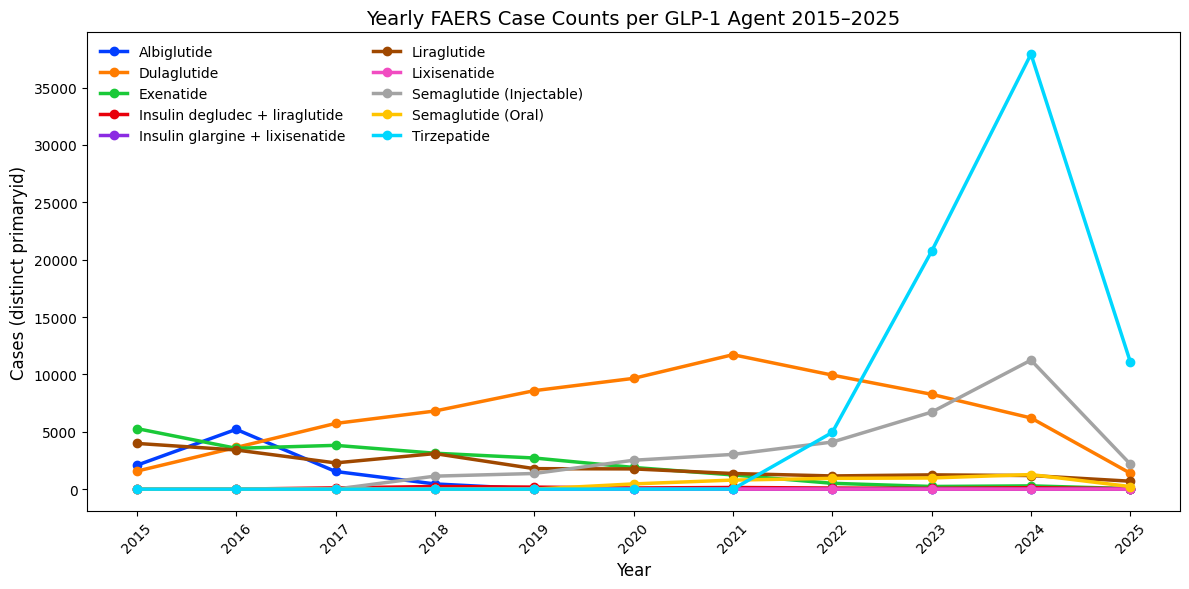

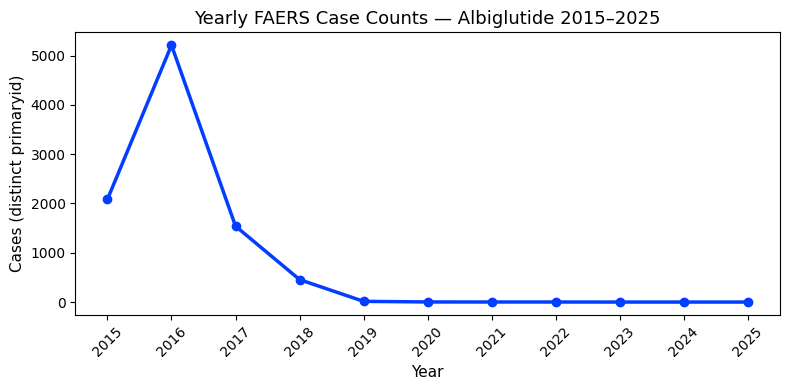

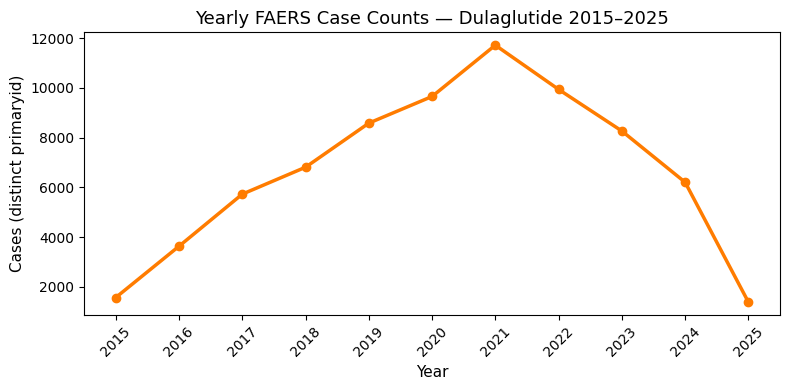

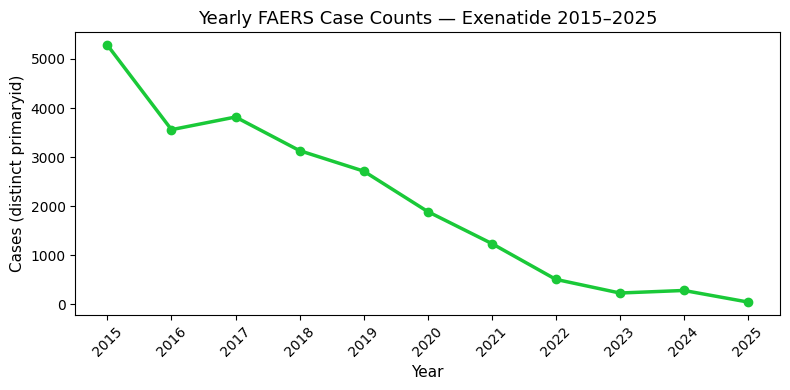

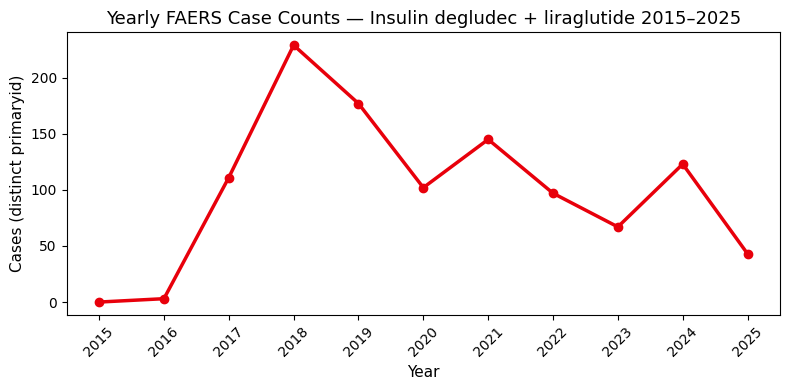

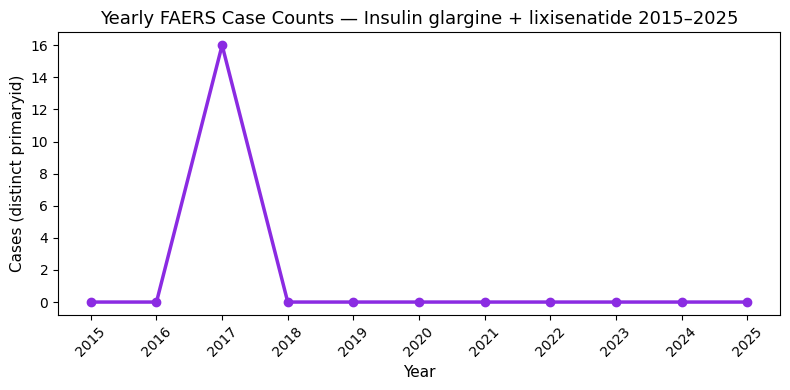

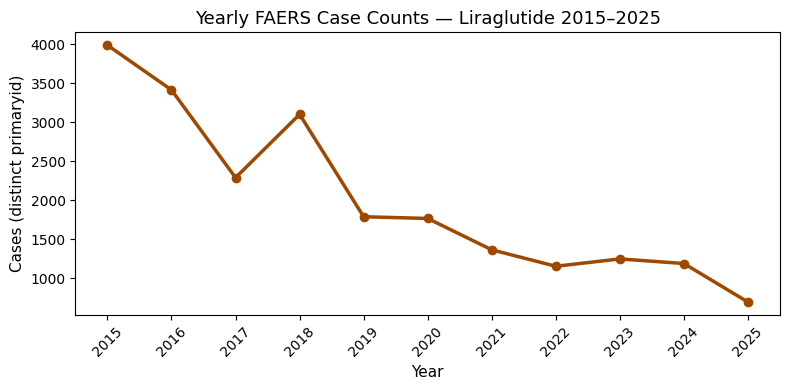

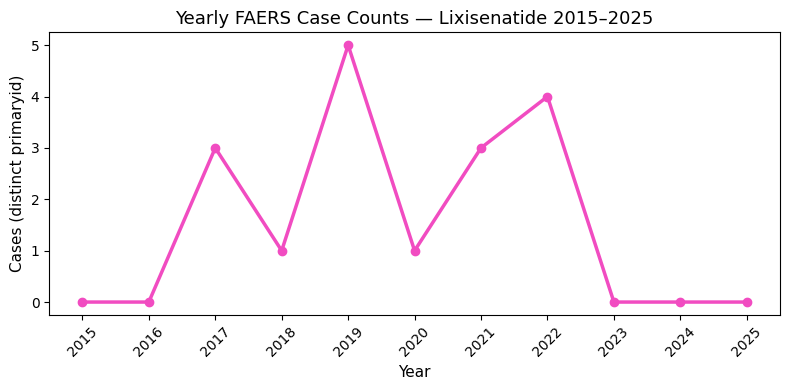

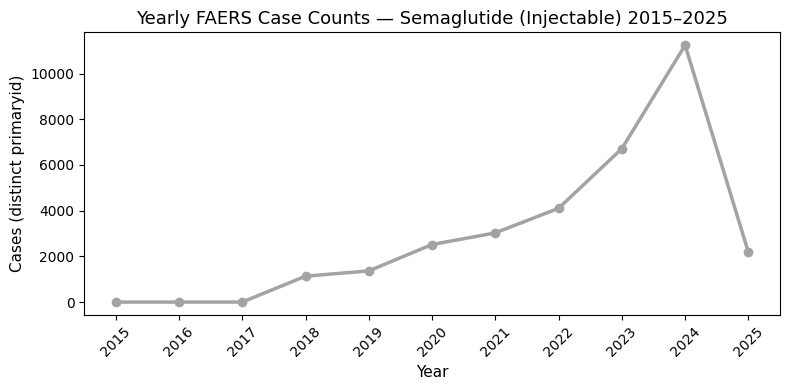

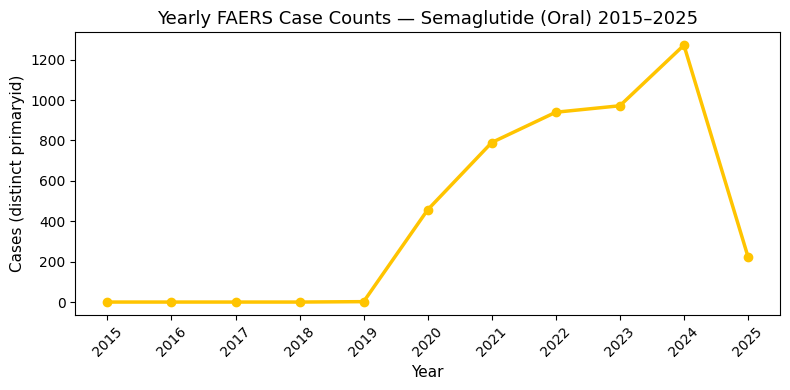

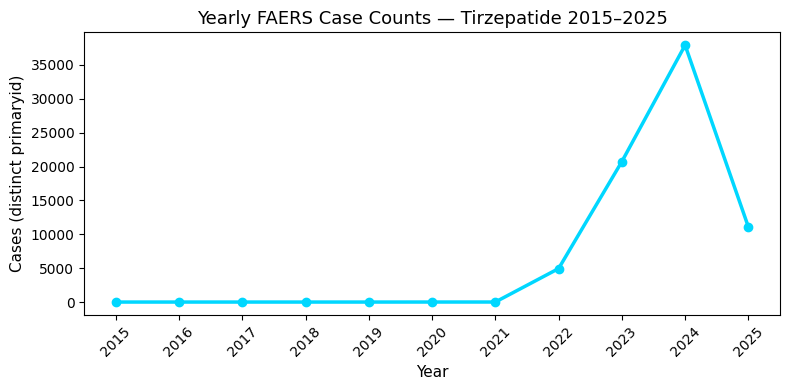

In [ ]:
import matplotlib.pyplot as plt

# Yearly counts per agent using the SAME mapping as glp1_brand_hits_windowed,
# but NOT filtered by agent windows; restrict only by global 2015–2025 range.
yearly_df = con.execute(r"""
WITH raw_hits AS (
  SELECT DISTINCT
    d.primaryid,
    atm.agent_key
  FROM drug_names_raw d
  JOIN glp1_agent_term_map atm
    ON d.name_raw LIKE '%' || atm.term || '%'
  WHERE d.role_cod IN ('PS','SS')              -- same PS/SS preference
),
dated AS (
  SELECT
    rh.primaryid,
    rh.agent_key,
    fn.receipt_date
  FROM raw_hits rh
  JOIN faers_norm fn USING (primaryid)
),
labeled AS (
  SELECT
    c.agent_label,
    d.primaryid,
    d.receipt_date
  FROM dated d
  JOIN glp1_agent_catalog c USING (agent_key)
),
yearly AS (
  SELECT
    agent_label,
    EXTRACT(YEAR FROM receipt_date)::INT AS year,
    COUNT(DISTINCT primaryid)            AS cases
  FROM labeled
  WHERE receipt_date BETWEEN DATE '2015-01-01' AND DATE '2025-12-31'
  GROUP BY 1,2
)
SELECT * FROM yearly
ORDER BY agent_label, year;
""").fetchdf()

# combine brand columns into generic columns
yearly_df["agent_label"] = yearly_df["agent_label"].replace(combine_map)
yearly_grouped = (
    yearly_df.groupby(["agent_label", "year"], as_index=False)
             .agg({"cases": "sum"})
)

display(yearly_df.head())

# make every agent have a value for every year 2015..2025
years  = list(range(2015, 2026))

# IMPORTANT: build from the grouped df (unique pairs), not the raw yearly_df
agents = sorted(yearly_grouped["agent_label"].unique().tolist())
full_index = pd.MultiIndex.from_product([agents, years], names=["agent_label", "year"])

yearly_full = (
    yearly_grouped
      .set_index(["agent_label", "year"])   # unique after groupby → OK
      .reindex(full_index, fill_value=0)
      .reset_index()
)

# plots
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

# use distinct, high-contrast colors
plt.figure(figsize=(12, 6))
palette = sns.color_palette("bright", len(agents))  # very distinct hues
colors = palette.as_hex()  # convert to hex for matplotlib

for i, (agent, sub) in enumerate(yearly_full.groupby("agent_label", sort=True)):
    plt.plot(
        sub["year"],
        sub["cases"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=agent,
        color=colors[i]
    )

plt.title("Yearly FAERS Case Counts per GLP-1 Agent 2015–2025", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Cases (distinct primaryid)", fontsize=12)
plt.xticks(years, rotation=45)
plt.grid(False)
plt.legend(ncol=2, fontsize=10, loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

# per-agent plots with same color mapping
color_map = dict(zip(agents, colors))
for agent in agents:
    sub = yearly_full[yearly_full["agent_label"] == agent].sort_values("year")
    plt.figure(figsize=(8, 4))
    plt.plot(
        sub["year"],
        sub["cases"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        color=color_map[agent]
    )
    plt.title(f"Yearly FAERS Case Counts — {agent} 2015–2025", fontsize=13)
    plt.xlabel("Year", fontsize=11)
    plt.ylabel("Cases (distinct primaryid)", fontsize=11)
    plt.xticks(years, rotation=45)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

Attempt: Machine Learning Models

ML: Serious (1) vs Non-serious (0) modeling for GLP-1 cases
Target: 'serious' = has any OUTC code (DE/LT/HO/DS/CA/RI/OT); Non-serious = no OUTC rows.
Features (reportable at submission time):
Demographics: age_years, sex
Reporter: occp_cod (bucketed)
Indication bucket: (Type1, Type2, Obesity, CVD, Others, Unknown)
Molecule + Brand-vs-Generic assignment
Receipt year/month
AE category footprint from REAC (presence of categories defined)  [optional but reportable]

In [81]:
!pip install scikit-learn

In [82]:
import numpy as np
import pandas as pd
import duckdb
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, brier_score_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

242312 from one row per (case, molecule); cases with drug mis-spelled which not shown among is_brand_only, is_generic_only, or mixed are filtered out

In [83]:
# --------------------------------------------
# 0) Indication bucket per case (priority-based)
# --------------------------------------------
con.execute(r"""
CREATE OR REPLACE VIEW glp1_indication_bucket AS
WITH raw AS (
  SELECT CAST(primaryid AS BIGINT) AS primaryid,
         lower(coalesce(indi_pt,'')) AS indi_text
  FROM sqldb.main.INDI
),
classified AS (
  SELECT
    primaryid,
    CASE
      WHEN indi_text = '' THEN 'Unknown'
      WHEN regexp_matches(indi_text, 'type\s*1') THEN 'Type 1 Diabetes'
      WHEN regexp_matches(indi_text, 'type\s*2')
        OR indi_text LIKE '%type ii%'
        OR indi_text LIKE '%t2dm%'             THEN 'Type 2 Diabetes'
      WHEN indi_text LIKE '%obes%' OR indi_text LIKE '%overweight%' THEN 'Obesity'
      WHEN indi_text LIKE '%cardio%' OR indi_text LIKE '%ischemi%' OR
           indi_text LIKE '%coronary%' OR indi_text LIKE '%heart failure%' OR
           indi_text LIKE '%cvd%' OR indi_text LIKE '%myocard%' OR
           indi_text LIKE '%stroke%'              THEN 'Cardiovascular disease'
      ELSE 'Others'
    END AS bucket
  FROM raw
),
ranked AS (
  SELECT primaryid, bucket,
         CASE bucket
           WHEN 'Type 1 Diabetes'        THEN 1
           WHEN 'Type 2 Diabetes'        THEN 2
           WHEN 'Obesity'                THEN 3
           WHEN 'Cardiovascular disease' THEN 4
           WHEN 'Others'                 THEN 5
           ELSE 6
         END AS prio
  FROM classified
),
chosen AS (
  SELECT primaryid, bucket
  FROM (
    SELECT primaryid, bucket,
           ROW_NUMBER() OVER (PARTITION BY primaryid ORDER BY prio) AS rn
    FROM ranked
  )
  WHERE rn = 1
)
SELECT * FROM chosen;
""")


# --------------------------------------------
# 1) Exposure flags per (primaryid, molecule)
#    SOURCE: glp1_case_molecule_exposure  (NO kind)
#    ONLY 3 mutually exclusive classes
# --------------------------------------------
con.execute(r"""
CREATE OR REPLACE VIEW glp1_molecule_case_flags AS
SELECT
  CAST(primaryid AS BIGINT) AS primaryid,
  lower(trim(molecule)) AS molecule,

  CASE WHEN exposure_type = 'brand_only'   THEN 1 ELSE 0 END AS is_brand_only,
  CASE WHEN exposure_type = 'generic_only' THEN 1 ELSE 0 END AS is_generic_only,
  CASE WHEN exposure_type = 'mixed'        THEN 1 ELSE 0 END AS is_mixed

FROM glp1_case_molecule_exposure;
""")


# --------------------------------------------
# 2) Build modeling dataset: one row per (case, molecule)
# --------------------------------------------
ml_df = con.execute(r"""
WITH cohort AS (
  SELECT * FROM glp1_cases_psss
),

lbl AS (
  SELECT c.primaryid,
         CASE WHEN d.primaryid IS NOT NULL THEN 1 ELSE 0 END AS serious
  FROM cohort c
  LEFT JOIN (SELECT DISTINCT primaryid FROM outc_dedup) d USING(primaryid)
),

reporter AS (
  SELECT primaryid,
         CASE UPPER(occp_cod)
           WHEN 'MD' THEN 'Healthcare professional'
           WHEN 'PH' THEN 'Healthcare professional'
           WHEN 'OT' THEN 'Healthcare professional'
           WHEN 'LW' THEN 'Lawyer'
           WHEN 'CN' THEN 'Consumer'
           ELSE 'Unspecified'
         END AS reporter_bucket
  FROM cohort
),

sex_b AS (
  SELECT primaryid,
         CASE UPPER(sex)
           WHEN 'M' THEN 'Male'
           WHEN 'F' THEN 'Female'
           ELSE 'Unknown'
         END AS sex_bucket
  FROM cohort
),

dates AS (
  SELECT primaryid,
         EXTRACT(YEAR FROM receipt_date)::INT AS receipt_year,
         EXTRACT(MONTH FROM receipt_date)::INT AS receipt_month
  FROM cohort
),

indi AS (
  SELECT primaryid, COALESCE(bucket, 'Unknown') AS indication_bucket
  FROM glp1_indication_bucket
),

mol AS (
  SELECT
    primaryid,
    molecule,
    is_brand_only,
    is_generic_only,
    is_mixed
  FROM glp1_molecule_case_flags
),

cat AS (
  SELECT primaryid, category
  FROM glp1_reac_categories_all
),

cat_pivot AS (
  SELECT primaryid,
         MAX(CASE WHEN category='Dosing/Administration Issues' THEN 1 ELSE 0 END) AS cat_dose_admin,
         MAX(CASE WHEN category='Gastrointestinal Disorders'   THEN 1 ELSE 0 END) AS cat_gi,
         MAX(CASE WHEN category='Injection Site Reactions'     THEN 1 ELSE 0 END) AS cat_inj_site,
         MAX(CASE WHEN category='Pancreatic Effects'           THEN 1 ELSE 0 END) AS cat_pancreas,
         MAX(CASE WHEN category='Thyroid'                      THEN 1 ELSE 0 END) AS cat_thyroid,
         MAX(CASE WHEN category='Gallbladder'                  THEN 1 ELSE 0 END) AS cat_gb,
         MAX(CASE WHEN category='Metabolic Effects'            THEN 1 ELSE 0 END) AS cat_metabolic,
         MAX(CASE WHEN category='Renal/Urinary'                THEN 1 ELSE 0 END) AS cat_renal,
         MAX(CASE WHEN category='Psychiatric'                  THEN 1 ELSE 0 END) AS cat_psych,
         MAX(CASE WHEN category='Musculoskeletal/Amputation'   THEN 1 ELSE 0 END) AS cat_msk,
         MAX(CASE WHEN category='Drug Effectiveness'           THEN 1 ELSE 0 END) AS cat_effectiveness,
         MAX(CASE WHEN category='Other'                        THEN 1 ELSE 0 END) AS cat_other
  FROM cat
  GROUP BY primaryid
),

base AS (
  SELECT
    c.primaryid,
    c.age_years,
    m.molecule,
    m.is_brand_only,
    m.is_generic_only,
    m.is_mixed
  FROM cohort c
  INNER JOIN mol m USING (primaryid)
)

SELECT
  b.primaryid,
  l.serious,
  b.age_years,
  sb.sex_bucket,
  r.reporter_bucket,
  COALESCE(i.indication_bucket,'Unknown') AS indication_bucket,
  d.receipt_year,
  d.receipt_month,

  b.molecule,
  b.is_brand_only,
  b.is_generic_only,
  b.is_mixed,

  COALESCE(cp.cat_dose_admin,0)     AS cat_dose_admin,
  COALESCE(cp.cat_gi,0)             AS cat_gi,
  COALESCE(cp.cat_inj_site,0)       AS cat_inj_site,
  COALESCE(cp.cat_pancreas,0)       AS cat_pancreas,
  COALESCE(cp.cat_thyroid,0)        AS cat_thyroid,
  COALESCE(cp.cat_gb,0)             AS cat_gb,
  COALESCE(cp.cat_metabolic,0)      AS cat_metabolic,
  COALESCE(cp.cat_renal,0)          AS cat_renal,
  COALESCE(cp.cat_psych,0)          AS cat_psych,
  COALESCE(cp.cat_msk,0)            AS cat_msk,
  COALESCE(cp.cat_effectiveness,0)  AS cat_effectiveness,
  COALESCE(cp.cat_other,0)          AS cat_other

FROM base b
LEFT JOIN lbl l USING (primaryid)
LEFT JOIN sex_b sb USING (primaryid)
LEFT JOIN reporter r USING (primaryid)
LEFT JOIN dates d USING (primaryid)
LEFT JOIN indi i USING (primaryid)
LEFT JOIN cat_pivot cp USING (primaryid);
""").fetchdf()

ml_df["molecule"] = ml_df["molecule"].replace(combine_map)

print("Modeling rows:", len(ml_df))
print("Flag sums:\n", ml_df[["is_brand_only","is_generic_only","is_mixed"]].sum())

# sanity: should be mutually exclusive for each row
print("Rows with >1 exposure flag set:",
      (ml_df[["is_brand_only","is_generic_only","is_mixed"]].sum(axis=1) > 1).sum())

ml_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Modeling rows: 242312
Flag sums:
 is_brand_only      238189
is_generic_only      3912
is_mixed              211
dtype: int64
Rows with >1 exposure flag set: 0


,primaryid,serious,age_years,sex_bucket,reporter_bucket,indication_bucket,receipt_year,receipt_month,molecule,is_brand_only,...,cat_inj_site,cat_pancreas,cat_thyroid,cat_gb,cat_metabolic,cat_renal,cat_psych,cat_msk,cat_effectiveness,cat_other
0,165948062,1,62.0,Female,Healthcare professional,Type 2 Diabetes,2019,9,semaglutide,1,...,0,0,0,0,0,0,0,0,0,1
1,248813931,1,NaN,Male,Consumer,Type 2 Diabetes,2025,1,semaglutide,1,...,0,0,0,0,0,0,0,0,0,1
2,120855881,1,51.0,Female,Consumer,Type 2 Diabetes,2016,2,albiglutide,1,...,0,0,0,0,1,0,1,0,0,1
3,182961881,1,NaN,Unknown,Consumer,Others,2020,9,dulaglutide,1,...,0,0,0,0,0,0,0,0,0,1
4,250484691,1,70.0,Female,Healthcare professional,Others,2025,3,semaglutide,1,...,0,0,0,0,0,0,0,0,0,1


In [86]:
# save the model input data and check for NaN
ml_df.to_csv("ml_df.csv", index=False)

Overall Class Balance

In [87]:
class_counts = ml_df["serious"].value_counts().sort_index()
class_perc = ml_df["serious"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages (%):")
print(class_perc.round(2))

Class counts:
serious
0    180240
1     62072
Name: count, dtype: int64

Class percentages (%):
serious
0    74.38
1    25.62
Name: proportion, dtype: float64


Balance Per Molecule

In [88]:
balance_by_molecule = (
    ml_df
    .groupby("molecule")["serious"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    * 100
)

balance_by_molecule.round(2)

serious,0,1
molecule,,
albiglutide,95.05,4.95
dulaglutide,79.92,20.08
exenatide,73.57,26.43
liraglutide,51.91,48.09
lixisenatide,90.91,9.09
semaglutide,47.25,52.75
tirzepatide,87.85,12.15


Check balance by brand/generic flags

In [89]:
flag_cols = [
    "is_brand_only",
    "is_generic_only",
    "is_mixed",
]

for col in flag_cols:
    print(f"\n{col}")
    print(
        ml_df.loc[ml_df[col] == 1, "serious"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )


is_brand_only
serious
0    75.1
1    24.9
Name: proportion, dtype: float64

is_generic_only
serious
1    68.07
0    31.93
Name: proportion, dtype: float64

is_mixed
serious
0    52.13
1    47.87
Name: proportion, dtype: float64


Due to significant imbalance in albiglutide and lixisenatide, we can't randomly undersample non-serious cases and can't oversample serious cases with SMOTE. And we can't train one global model and trust raw probabilities.

Compute Exact Class Weights

In [90]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
y_all = ml_df["serious"].astype(int).values

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_all
)

class_weight = {0: weights[0], 1: weights[1]}
class_weight

{0: 0.6721926320461606, 1: 1.9518623533960562}

Train / Evaluate models

In [ ]:
# ============================================================
# Clean train/val/test (group-aware) + threshold tuning on VAL
# Works for BOTH Logistic Regression and Random Forest
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

# ----------------------------
# 0) Columns (update if needed)
# ----------------------------
target_col = "serious"

numeric_cols = ["age_years", "receipt_year", "receipt_month"]

cat_cols = ["sex_bucket","reporter_bucket","indication_bucket","molecule"]

binary_cols = [
    "cat_dose_admin","cat_gi","cat_inj_site","cat_pancreas","cat_thyroid",
    "cat_gb","cat_metabolic","cat_renal","cat_psych","cat_msk",
    "cat_effectiveness","cat_other",
    # exposure flags (3-class, mutually exclusive)
    "is_brand_only","is_generic_only","is_mixed"
]

use_cols = ["primaryid"] + numeric_cols + binary_cols + cat_cols + [target_col]
df = ml_df[use_cols].copy()

# numeric cleaning
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ----------------------------
# 1) Group-aware split: TRAIN vs TEST (by primaryid)
# ----------------------------
groups = df["primaryid"].astype(str)  # ensure stable group labels
X_all = df.drop(columns=[target_col])
y_all = df[target_col].astype(int)

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
y_train, y_test = y_all.iloc[train_idx].copy(), y_all.iloc[test_idx].copy()

# ----------------------------
# 2) Inside TRAIN: TRAIN2 vs VAL (for threshold tuning; still group-aware)
# ----------------------------
groups_train = X_train["primaryid"].astype(str)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train2_idx, val_idx = next(gss2.split(X_train, y_train, groups=groups_train))

X_tr, X_val = X_train.iloc[train2_idx].copy(), X_train.iloc[val_idx].copy()
y_tr, y_val = y_train.iloc[train2_idx].copy(), y_train.iloc[val_idx].copy()

# Drop primaryid from features (keep it separately only for grouping / reports)
X_tr_feat  = X_tr.drop(columns=["primaryid"])
X_val_feat = X_val.drop(columns=["primaryid"])
X_test_feat = X_test.drop(columns=["primaryid"])

# ----------------------------
# 3) Preprocessor
# ----------------------------
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
        ("bin", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value=0))]), binary_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe)
        ]), cat_cols),
    ],
    remainder="drop"
)

# ----------------------------
# 4) Exact class weights (computed on TRAIN2 only)
# ----------------------------
classes = np.array([0, 1])
w = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr.values)
class_weight = {0: float(w[0]), 1: float(w[1])}
print("Class weights (from TRAIN2):", class_weight)

# ----------------------------
# 5) Helper: pick threshold on VAL (maximize F1)
# ----------------------------
def pick_threshold_f1(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    # t has length len(p)-1
    f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-9)
    best_idx = int(np.argmax(f1))
    return float(t[best_idx]), float(f1[best_idx]), float(p[:-1][best_idx]), float(r[:-1][best_idx])

def evaluate(name, y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    print(f"\n===== {name} =====")
    print("Threshold:", threshold)
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    print("PR-AUC :", average_precision_score(y_true, proba))
    print("Brier :", brier_score_loss(y_true, proba))
    print(classification_report(y_true, pred, digits=3))

# ============================================================
# 6) Logistic Regression: fit on TRAIN2, tune threshold on VAL, evaluate on TEST
# ============================================================
logit = Pipeline(steps=[
    ("pre", pre),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
        class_weight=class_weight
    ))
])

logit.fit(X_tr_feat, y_tr)

# Tune threshold on VAL
proba_val_lr = logit.predict_proba(X_val_feat)[:, 1]
thr_lr, f1_lr, p_lr, r_lr = pick_threshold_f1(y_val.values, proba_val_lr)
print("\n[LR] Best VAL threshold (F1):", thr_lr, "| F1:", round(f1_lr, 4), "| P:", round(p_lr, 4), "| R:", round(r_lr, 4))

# Evaluate on TEST using that threshold
proba_test_lr = logit.predict_proba(X_test_feat)[:, 1]
evaluate("LogReg (threshold tuned on VAL)", y_test.values, proba_test_lr, thr_lr)

# ============================================================
# 7) Random Forest: fit on TRAIN2, tune threshold on VAL, evaluate on TEST
# ============================================================
rf = Pipeline(steps=[
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=30,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_tr_feat, y_tr)

# Tune threshold on VAL
proba_val_rf = rf.predict_proba(X_val_feat)[:, 1]
thr_rf, f1_rf, p_rf, r_rf = pick_threshold_f1(y_val.values, proba_val_rf)
print("\n[RF] Best VAL threshold (F1):", thr_rf, "| F1:", round(f1_rf, 4), "| P:", round(p_rf, 4), "| R:", round(r_rf, 4))

# Evaluate on TEST using that threshold
proba_test_rf = rf.predict_proba(X_test_feat)[:, 1]
evaluate("RandomForest (threshold tuned on VAL)", y_test.values, proba_test_rf, thr_rf)

# ============================================================
# 8) Molecule-stratified metrics on TEST (for LR & RF)
# ============================================================
def molecule_metrics(name, molecules, y_true, proba, min_n=500):
    out = []
    tmp = pd.DataFrame({"molecule": molecules, "y": y_true, "p": proba})
    for mol, g in tmp.groupby("molecule"):
        if len(g) >= min_n and g["y"].nunique() == 2:
            out.append({
                "model": name,
                "molecule": mol,
                "n": len(g),
                "pos_rate": g["y"].mean(),
                "roc_auc": roc_auc_score(g["y"], g["p"]),
                "pr_auc": average_precision_score(g["y"], g["p"]),
                "brier": brier_score_loss(g["y"], g["p"])
            })
    return pd.DataFrame(out).sort_values(["model","n"], ascending=[True, False])

mol_test = X_test["molecule"].values

mm_lr = molecule_metrics("LogReg", mol_test, y_test.values, proba_test_lr, min_n=500)
mm_rf = molecule_metrics("RF",     mol_test, y_test.values, proba_test_rf, min_n=500)

mol_metrics_df = pd.concat([mm_lr, mm_rf], ignore_index=True)
mol_metrics_df


Class weights (from TRAIN2): {0: 0.6723669120639266, 1: 1.9503943767773784}

[LR] Best VAL threshold (F1): 0.5986870862952328 | F1: 0.6496 | P: 0.6184 | R: 0.6843

===== LogReg (threshold tuned on VAL) =====
Threshold: 0.5986870862952328
ROC-AUC: 0.8763308450984656
PR-AUC : 0.7389931907932712
Brier : 0.1426295726874472
              precision    recall  f1-score   support

           0      0.888     0.856     0.872     45047
           1      0.622     0.687     0.653     15540

    accuracy                          0.813     60587
   macro avg      0.755     0.771     0.762     60587
weighted avg      0.820     0.813     0.816     60587


[RF] Best VAL threshold (F1): 0.5946310569023829 | F1: 0.7231 | P: 0.722 | R: 0.7241

===== RandomForest (threshold tuned on VAL) =====
Threshold: 0.5946310569023829
ROC-AUC: 0.9160862997117354
PR-AUC : 0.8220730788754578
Brier : 0.12237902026709378
              precision    recall  f1-score   support

           0      0.907     0.906     0.906   

,model,molecule,n,pos_rate,roc_auc,pr_auc,brier
0,LogReg,tirzepatide,19069,0.121873,0.886518,0.571288,0.088814
1,LogReg,dulaglutide,18290,0.202242,0.854077,0.650817,0.132557
2,LogReg,semaglutide,10009,0.530023,0.757556,0.798730,0.239072
3,LogReg,liraglutide,5708,0.484583,0.803574,0.823722,0.217375
4,LogReg,exenatide,5175,0.257971,0.854952,0.738750,0.154721
5,LogReg,albiglutide,2328,0.047680,0.889807,0.477261,0.037303
6,RF,tirzepatide,19069,0.121873,0.909340,0.624956,0.087455
7,RF,dulaglutide,18290,0.202242,0.880602,0.691447,0.127281
8,RF,semaglutide,10009,0.530023,0.913500,0.921901,0.161174
9,RF,liraglutide,5708,0.484583,0.891576,0.893190,0.171824


Raw probabilities are not comparable across molecules due to base-rate differences.

Fix this by post-hoc calibration per molecule.

Class weights (TRAIN2): {0: 0.6723669120639266, 1: 1.9503943767773784}

[LR+Platt] Best VAL threshold: 0.37437155153068347 | F1: 0.6496 | P: 0.6184 | R: 0.6843

===== LogReg + Platt (TEST, calibrated) =====
Threshold: 0.37437155153068347
ROC-AUC: 0.8763308450984656
PR-AUC : 0.7389931907932712
Brier : 0.12015035859685777
              precision    recall  f1-score   support

           0      0.888     0.856     0.872     45047
           1      0.622     0.687     0.653     15540

    accuracy                          0.813     60587
   macro avg      0.755     0.771     0.762     60587
weighted avg      0.820     0.813     0.816     60587


[LR+Iso] Best VAL threshold: 0.36918429003021147 | F1: 0.6496 | P: 0.6184 | R: 0.6843

===== LogReg + Isotonic (TEST, calibrated) =====
Threshold: 0.36918429003021147
ROC-AUC: 0.8763544883580626
PR-AUC : 0.7298125526508356
Brier : 0.11751318397430179
              precision    recall  f1-score   support

           0      0.888     0.856     0.872 

,model,molecule,n,pos_rate,brier,roc_auc,pr_auc
5,LR+Platt,tirzepatide,19069,0.121873,0.076029,0.886518,0.571288
1,LR+Platt,dulaglutide,18290,0.202242,0.111015,0.854077,0.650817
4,LR+Platt,semaglutide,10009,0.530023,0.203314,0.757556,0.798730
3,LR+Platt,liraglutide,5708,0.484583,0.182029,0.803574,0.823722
2,LR+Platt,exenatide,5175,0.257971,0.124913,0.854952,0.738750
0,LR+Platt,albiglutide,2328,0.047680,0.033445,0.889807,0.477261



Top molecule-wise Brier (LR+Iso):


,model,molecule,n,pos_rate,brier,roc_auc,pr_auc
5,LR+Iso,tirzepatide,19069,0.121873,0.074499,0.886327,0.559824
1,LR+Iso,dulaglutide,18290,0.202242,0.109885,0.853965,0.638712
4,LR+Iso,semaglutide,10009,0.530023,0.197415,0.758868,0.790367
3,LR+Iso,liraglutide,5708,0.484583,0.177151,0.804174,0.814230
2,LR+Iso,exenatide,5175,0.257971,0.120812,0.854575,0.730411
0,LR+Iso,albiglutide,2328,0.047680,0.032741,0.889683,0.463813


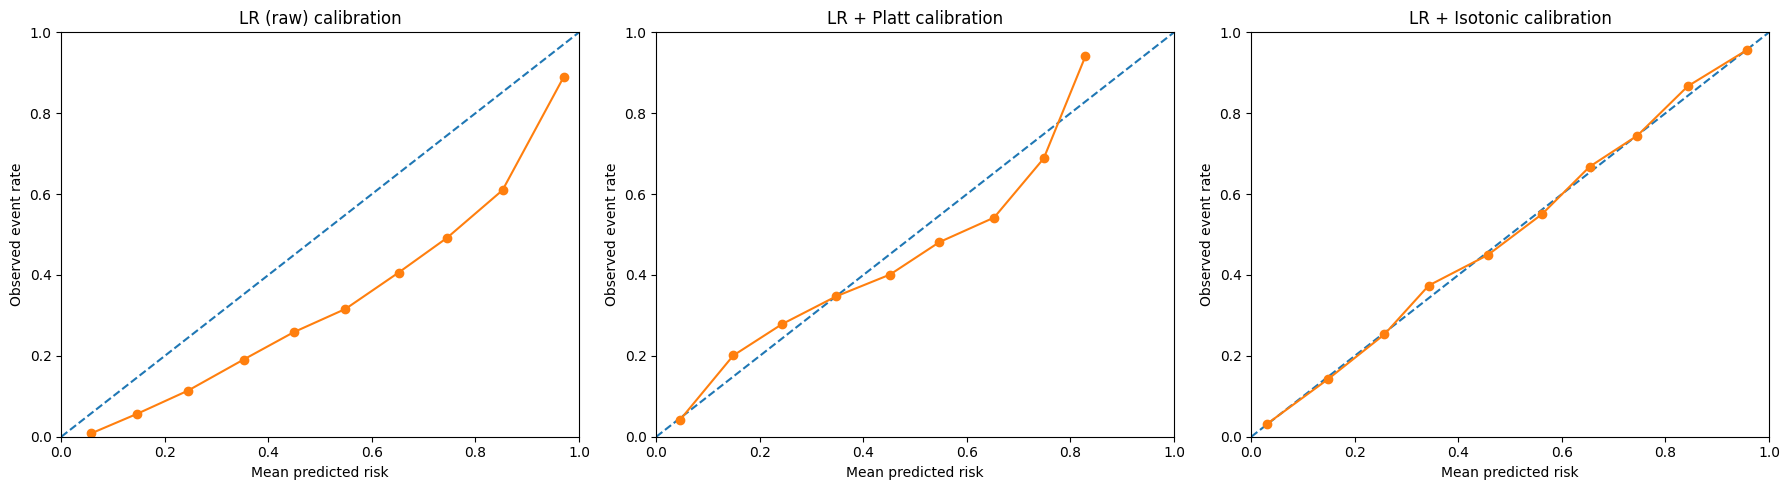

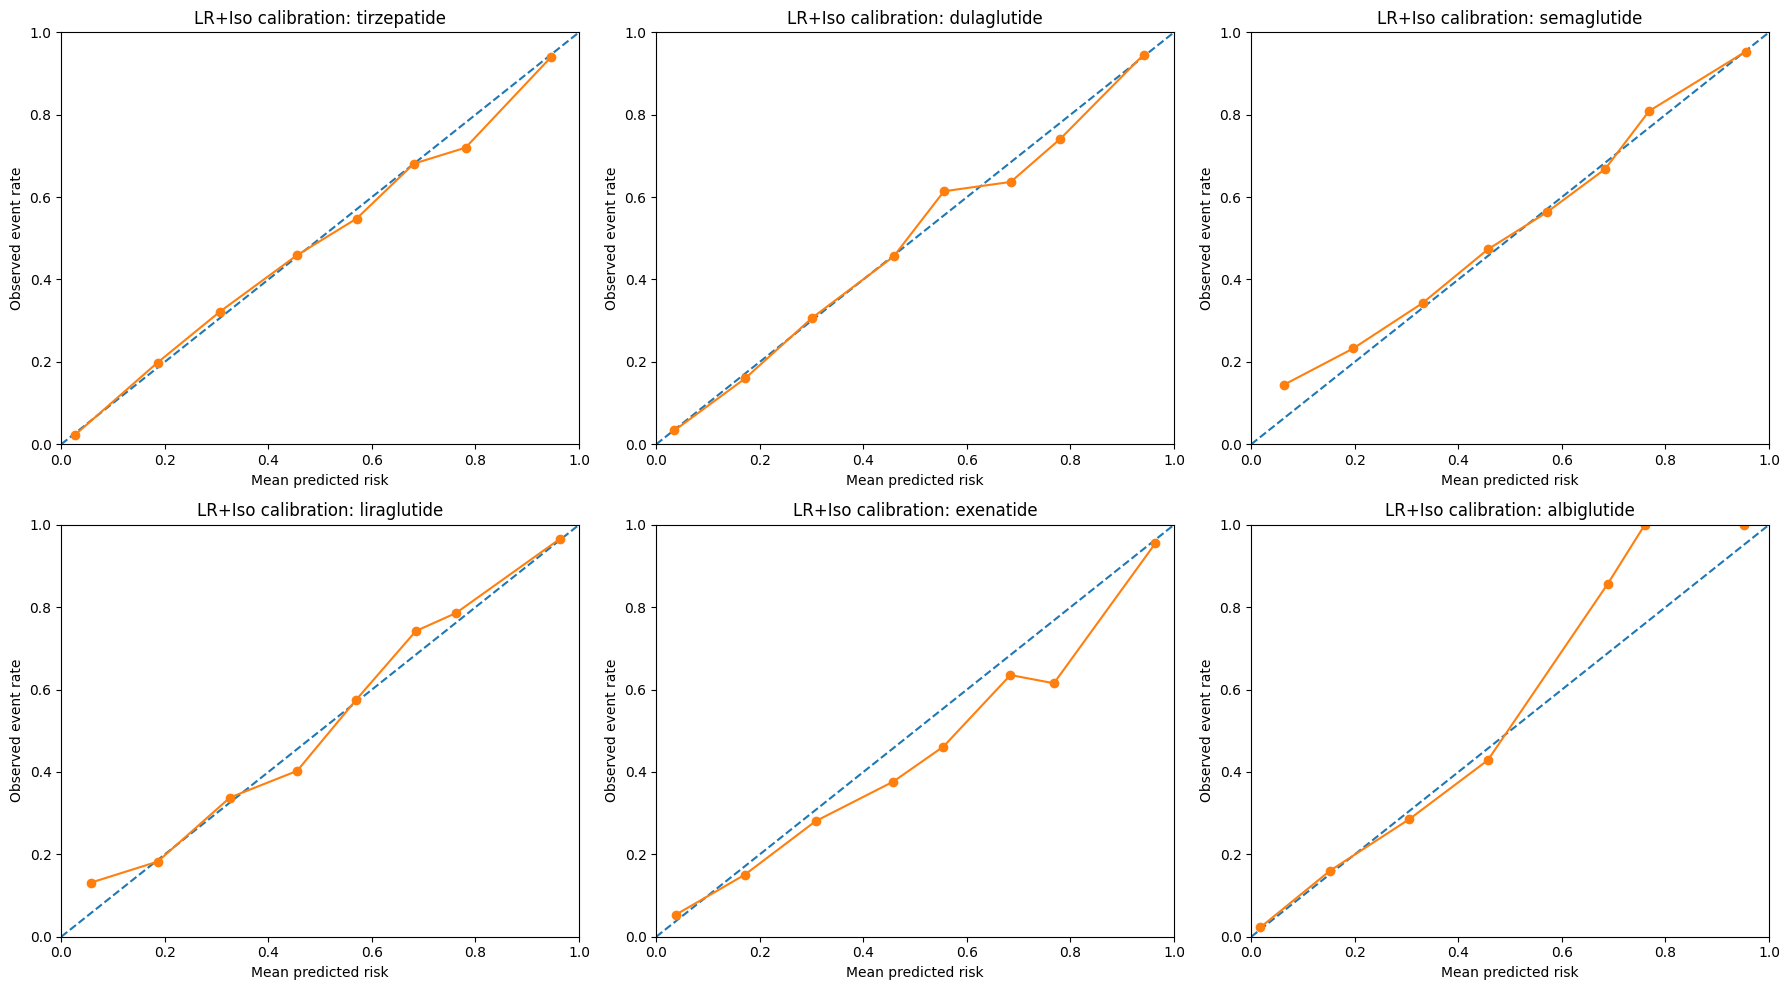


[RF+Platt] Best VAL threshold: 0.404829365668105 | F1: 0.7231 | P: 0.722 | R: 0.7241

===== RF + Platt (TEST, calibrated) =====
Threshold: 0.404829365668105
ROC-AUC: 0.9160862997117354
PR-AUC : 0.8220730788754578
Brier : 0.09651271953971255
              precision    recall  f1-score   support

           0      0.907     0.906     0.906     45047
           1      0.728     0.730     0.729     15540

    accuracy                          0.861     60587
   macro avg      0.817     0.818     0.818     60587
weighted avg      0.861     0.861     0.861     60587


[RF+Iso] Best VAL threshold: 0.36964980544747084 | F1: 0.7231 | P: 0.722 | R: 0.7241

===== RF + Isotonic (TEST, calibrated) =====
Threshold: 0.36964980544747084
ROC-AUC: 0.915942331674234
PR-AUC : 0.8149389301552348
Brier : 0.09585932122318375
              precision    recall  f1-score   support

           0      0.907     0.906     0.906     45047
           1      0.728     0.730     0.729     15540

    accuracy         

,model,molecule,n,pos_rate,brier,roc_auc,pr_auc
5,RF+Platt,tirzepatide,19069,0.121873,0.069573,0.909340,0.624956
1,RF+Platt,dulaglutide,18290,0.202242,0.103552,0.880602,0.691447
4,RF+Platt,semaglutide,10009,0.530023,0.119976,0.913500,0.921901
3,RF+Platt,liraglutide,5708,0.484583,0.135324,0.891576,0.893190
2,RF+Platt,exenatide,5175,0.257971,0.112098,0.876579,0.776055
0,RF+Platt,albiglutide,2328,0.047680,0.031128,0.928054,0.540776



Top molecule-wise Brier (RF+Iso):


,model,molecule,n,pos_rate,brier,roc_auc,pr_auc
5,RF+Iso,tirzepatide,19069,0.121873,0.069300,0.909240,0.613526
1,RF+Iso,dulaglutide,18290,0.202242,0.103245,0.880082,0.681459
4,RF+Iso,semaglutide,10009,0.530023,0.118180,0.913022,0.917407
3,RF+Iso,liraglutide,5708,0.484583,0.134663,0.891437,0.887564
2,RF+Iso,exenatide,5175,0.257971,0.110905,0.876084,0.766923
0,RF+Iso,albiglutide,2328,0.047680,0.030844,0.927800,0.522450


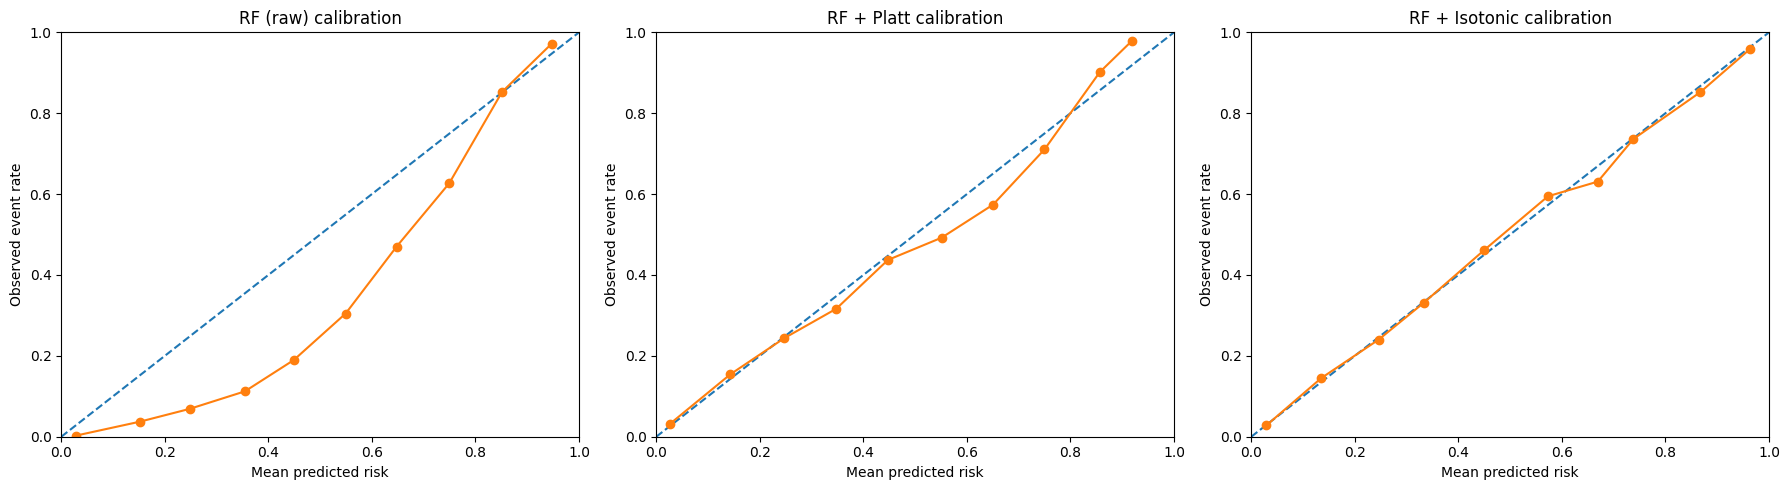

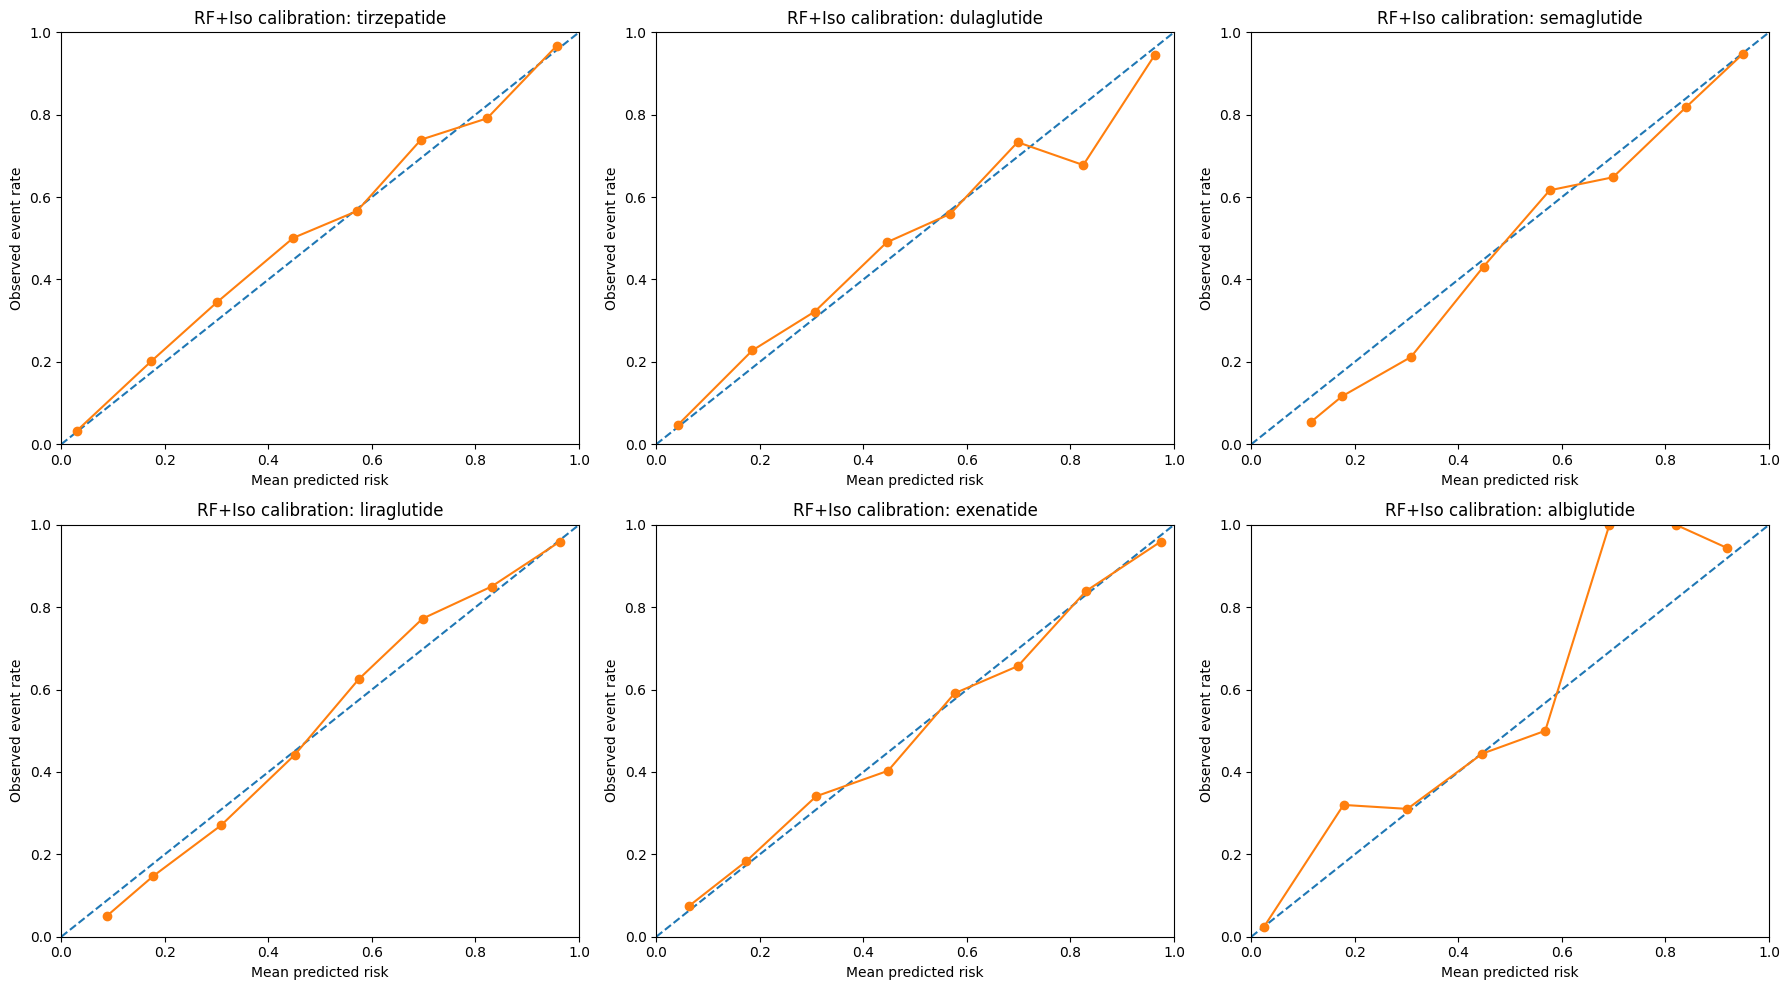

,model,molecule,n,pos_rate,brier,roc_auc,pr_auc
11,LR+Iso,albiglutide,2328,0.047680,0.032741,0.889683,0.463813
5,LR+Platt,albiglutide,2328,0.047680,0.033445,0.889807,0.477261
23,RF+Iso,albiglutide,2328,0.047680,0.030844,0.927800,0.522450
17,RF+Platt,albiglutide,2328,0.047680,0.031128,0.928054,0.540776
7,LR+Iso,dulaglutide,18290,0.202242,0.109885,0.853965,0.638712
1,LR+Platt,dulaglutide,18290,0.202242,0.111015,0.854077,0.650817
19,RF+Iso,dulaglutide,18290,0.202242,0.103245,0.880082,0.681459
13,RF+Platt,dulaglutide,18290,0.202242,0.103552,0.880602,0.691447
10,LR+Iso,exenatide,5175,0.257971,0.120812,0.854575,0.730411
4,LR+Platt,exenatide,5175,0.257971,0.124913,0.854952,0.738750


In [ ]:
# ============================================================
# Publication-clean calibration + thresholding (group-aware)
# - Group split: TRAIN / TEST by primaryid
# - Inside TRAIN: TRAIN2 / VAL by primaryid
# - Fit base model on TRAIN2
# - Fit calibrator on VAL (NO leakage)
# - Tune threshold on calibrated VAL probs
# - Evaluate on calibrated TEST probs (overall + per-molecule)
# - Plot calibration curves (overall + per-molecule)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, classification_report
)
from sklearn.isotonic import IsotonicRegression

# ----------------------------
# 0) Columns
# ----------------------------
target_col = "serious"

numeric_cols = ["age_years", "receipt_year", "receipt_month"]
cat_cols = ["sex_bucket","reporter_bucket","indication_bucket","molecule"]
binary_cols = [
    "cat_dose_admin","cat_gi","cat_inj_site","cat_pancreas","cat_thyroid",
    "cat_gb","cat_metabolic","cat_renal","cat_psych","cat_msk",
    "cat_effectiveness","cat_other",
    "is_brand_only","is_generic_only","is_mixed"
]

use_cols = ["primaryid"] + numeric_cols + binary_cols + cat_cols + [target_col]
df = ml_df[use_cols].copy()
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

groups = df["primaryid"].astype(str)
X_all = df.drop(columns=[target_col])
y_all = df[target_col].astype(int)

# ----------------------------
# 1) Group split: TRAIN / TEST
# ----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
y_train, y_test = y_all.iloc[train_idx].copy(), y_all.iloc[test_idx].copy()

# ----------------------------
# 2) Group split inside TRAIN: TRAIN2 / VAL
# ----------------------------
groups_train = X_train["primaryid"].astype(str)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train2_idx, val_idx = next(gss2.split(X_train, y_train, groups=groups_train))

X_tr, X_val = X_train.iloc[train2_idx].copy(), X_train.iloc[val_idx].copy()
y_tr, y_val = y_train.iloc[train2_idx].copy(), y_train.iloc[val_idx].copy()

# Keep molecule labels for reporting; drop primaryid for modeling
mol_test = X_test["molecule"].values
mol_val  = X_val["molecule"].values

X_tr_feat   = X_tr.drop(columns=["primaryid"])
X_val_feat  = X_val.drop(columns=["primaryid"])
X_test_feat = X_test.drop(columns=["primaryid"])

# ----------------------------
# 3) Preprocessor
# ----------------------------
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
        ("bin", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value=0))]), binary_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe)
        ]), cat_cols),
    ],
    remainder="drop"
)

# ----------------------------
# 4) Class weights from TRAIN2 only
# ----------------------------
classes = np.array([0, 1])
w = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr.values)
class_weight = {0: float(w[0]), 1: float(w[1])}
print("Class weights (TRAIN2):", class_weight)

# ----------------------------
# Helpers
# ----------------------------
def pick_threshold_f1(y_true, proba):
    p, r, t = precision_recall_curve(y_true, proba)
    f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-9)
    best_idx = int(np.argmax(f1))
    return float(t[best_idx]), float(f1[best_idx]), float(p[:-1][best_idx]), float(r[:-1][best_idx])

def evaluate_block(name, y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    print(f"\n===== {name} =====")
    print("Threshold:", threshold)
    print("ROC-AUC:", roc_auc_score(y_true, proba))
    print("PR-AUC :", average_precision_score(y_true, proba))
    print("Brier :", brier_score_loss(y_true, proba))
    print(classification_report(y_true, pred, digits=3))

def calibration_curve_manual(y_true, proba, n_bins=10):
    # returns mean_pred, frac_pos, counts per bin
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(proba, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)

    mean_pred, frac_pos, counts = [], [], []
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            continue
        mean_pred.append(proba[m].mean())
        frac_pos.append(y_true[m].mean())
        counts.append(int(m.sum()))
    return np.array(mean_pred), np.array(frac_pos), np.array(counts)

def plot_calibration(ax, y_true, proba, title, n_bins=10):
    mp, fp, c = calibration_curve_manual(y_true, proba, n_bins=n_bins)
    ax.plot([0,1], [0,1], linestyle="--")
    ax.plot(mp, fp, marker="o")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(title)
    ax.set_xlabel("Mean predicted risk")
    ax.set_ylabel("Observed event rate")

def molecule_brier_table(model_name, molecules, y_true, proba, min_n=500):
    out = []
    tmp = pd.DataFrame({"molecule": molecules, "y": y_true, "p": proba})
    for mol, g in tmp.groupby("molecule"):
        if len(g) >= min_n:
            out.append({
                "model": model_name,
                "molecule": mol,
                "n": len(g),
                "pos_rate": g["y"].mean(),
                "brier": brier_score_loss(g["y"], g["p"]),
                "roc_auc": roc_auc_score(g["y"], g["p"]) if g["y"].nunique() == 2 else np.nan,
                "pr_auc": average_precision_score(g["y"], g["p"]) if g["y"].nunique() == 2 else np.nan,
            })
    return pd.DataFrame(out).sort_values("n", ascending=False)

# ============================================================
# A) Logistic Regression + calibration (Isotonic and Platt)
# ============================================================

logit = Pipeline(steps=[
    ("pre", pre),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
        class_weight=class_weight
    ))
])

# Fit base on TRAIN2
logit.fit(X_tr_feat, y_tr)

# Raw probs on VAL/TEST
proba_val_lr_raw  = logit.predict_proba(X_val_feat)[:, 1]
proba_test_lr_raw = logit.predict_proba(X_test_feat)[:, 1]

# --- Platt scaling (sigmoid): fit logistic on VAL raw probs ---
platt_lr = LogisticRegression(max_iter=10000, solver="lbfgs")
platt_lr.fit(proba_val_lr_raw.reshape(-1, 1), y_val.values)
proba_val_lr_platt  = platt_lr.predict_proba(proba_val_lr_raw.reshape(-1, 1))[:, 1]
proba_test_lr_platt = platt_lr.predict_proba(proba_test_lr_raw.reshape(-1, 1))[:, 1]

# --- Isotonic regression: fit on VAL raw probs ---
iso_lr = IsotonicRegression(out_of_bounds="clip")
iso_lr.fit(proba_val_lr_raw, y_val.values)
proba_val_lr_iso  = iso_lr.transform(proba_val_lr_raw)
proba_test_lr_iso = iso_lr.transform(proba_test_lr_raw)

# Threshold tuning on CALIBRATED VAL probs, then evaluate on CALIBRATED TEST probs
thr_lr_platt, f1, p_, r_ = pick_threshold_f1(y_val.values, proba_val_lr_platt)
print("\n[LR+Platt] Best VAL threshold:", thr_lr_platt, "| F1:", round(f1,4), "| P:", round(p_,4), "| R:", round(r_,4))
evaluate_block("LogReg + Platt (TEST, calibrated)", y_test.values, proba_test_lr_platt, thr_lr_platt)

thr_lr_iso, f1, p_, r_ = pick_threshold_f1(y_val.values, proba_val_lr_iso)
print("\n[LR+Iso] Best VAL threshold:", thr_lr_iso, "| F1:", round(f1,4), "| P:", round(p_,4), "| R:", round(r_,4))
evaluate_block("LogReg + Isotonic (TEST, calibrated)", y_test.values, proba_test_lr_iso, thr_lr_iso)

# Molecule-wise Brier tables
brier_lr_platt = molecule_brier_table("LR+Platt", mol_test, y_test.values, proba_test_lr_platt, min_n=500)
brier_lr_iso   = molecule_brier_table("LR+Iso",   mol_test, y_test.values, proba_test_lr_iso,   min_n=500)

print("\nTop molecule-wise Brier (LR+Platt):")
display(brier_lr_platt.head(10))
print("\nTop molecule-wise Brier (LR+Iso):")
display(brier_lr_iso.head(10))

# Calibration curves (overall + per-molecule)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_calibration(axes[0], y_test.values, proba_test_lr_raw,   "LR (raw) calibration", n_bins=10)
plot_calibration(axes[1], y_test.values, proba_test_lr_platt, "LR + Platt calibration", n_bins=10)
plot_calibration(axes[2], y_test.values, proba_test_lr_iso,   "LR + Isotonic calibration", n_bins=10)
plt.tight_layout()
plt.show()

# Optional: per-molecule calibration curves for big molecules
big_mols = pd.Series(mol_test).value_counts()
big_mols = big_mols[big_mols >= 500].index.tolist()[:6]  # top 6

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, mol in zip(axes, big_mols):
    m = (mol_test == mol)
    plot_calibration(ax, y_test.values[m], proba_test_lr_iso[m], f"LR+Iso calibration: {mol}", n_bins=8)
plt.tight_layout()
plt.show()

# ============================================================
# B) Random Forest + calibration (Isotonic and Platt)
# ============================================================

rf = Pipeline(steps=[
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=30,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit base on TRAIN2
rf.fit(X_tr_feat, y_tr)

# Raw probs on VAL/TEST
proba_val_rf_raw  = rf.predict_proba(X_val_feat)[:, 1]
proba_test_rf_raw = rf.predict_proba(X_test_feat)[:, 1]

# Platt scaling on VAL raw probs
platt_rf = LogisticRegression(max_iter=10000, solver="lbfgs")
platt_rf.fit(proba_val_rf_raw.reshape(-1, 1), y_val.values)
proba_val_rf_platt  = platt_rf.predict_proba(proba_val_rf_raw.reshape(-1, 1))[:, 1]
proba_test_rf_platt = platt_rf.predict_proba(proba_test_rf_raw.reshape(-1, 1))[:, 1]

# Isotonic regression on VAL raw probs
iso_rf = IsotonicRegression(out_of_bounds="clip")
iso_rf.fit(proba_val_rf_raw, y_val.values)
proba_val_rf_iso  = iso_rf.transform(proba_val_rf_raw)
proba_test_rf_iso = iso_rf.transform(proba_test_rf_raw)

# Threshold tuning on calibrated VAL probs; evaluate on calibrated TEST probs
thr_rf_platt, f1, p_, r_ = pick_threshold_f1(y_val.values, proba_val_rf_platt)
print("\n[RF+Platt] Best VAL threshold:", thr_rf_platt, "| F1:", round(f1,4), "| P:", round(p_,4), "| R:", round(r_,4))
evaluate_block("RF + Platt (TEST, calibrated)", y_test.values, proba_test_rf_platt, thr_rf_platt)

thr_rf_iso, f1, p_, r_ = pick_threshold_f1(y_val.values, proba_val_rf_iso)
print("\n[RF+Iso] Best VAL threshold:", thr_rf_iso, "| F1:", round(f1,4), "| P:", round(p_,4), "| R:", round(r_,4))
evaluate_block("RF + Isotonic (TEST, calibrated)", y_test.values, proba_test_rf_iso, thr_rf_iso)

# Molecule-wise Brier tables
brier_rf_platt = molecule_brier_table("RF+Platt", mol_test, y_test.values, proba_test_rf_platt, min_n=500)
brier_rf_iso   = molecule_brier_table("RF+Iso",   mol_test, y_test.values, proba_test_rf_iso,   min_n=500)

print("\nTop molecule-wise Brier (RF+Platt):")
display(brier_rf_platt.head(10))
print("\nTop molecule-wise Brier (RF+Iso):")
display(brier_rf_iso.head(10))

# Calibration curves (overall + per-molecule)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_calibration(axes[0], y_test.values, proba_test_rf_raw,   "RF (raw) calibration", n_bins=10)
plot_calibration(axes[1], y_test.values, proba_test_rf_platt, "RF + Platt calibration", n_bins=10)
plot_calibration(axes[2], y_test.values, proba_test_rf_iso,   "RF + Isotonic calibration", n_bins=10)
plt.tight_layout()
plt.show()

# Per-molecule calibration curves for big molecules
big_mols = pd.Series(mol_test).value_counts()
big_mols = big_mols[big_mols >= 500].index.tolist()[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()
for ax, mol in zip(axes, big_mols):
    m = (mol_test == mol)
    plot_calibration(ax, y_test.values[m], proba_test_rf_iso[m], f"RF+Iso calibration: {mol}", n_bins=8)
plt.tight_layout()
plt.show()

# ============================================================
# Combined per-molecule Brier summary (choose best calibrated)
# ============================================================
brier_all = pd.concat([brier_lr_platt, brier_lr_iso, brier_rf_platt, brier_rf_iso], ignore_index=True)
brier_all.sort_values(["molecule","model"], inplace=True)
brier_all

Shapley Analysis

Use the original (uncalibrated) base models for SHAP.

Why:

Calibration (Platt / isotonic) is a post-hoc 1D transformation of the model score/probability. It doesn’t change what the base model “uses” (feature contributions), it only rescales the output to be better-calibrated. So SHAP on the calibrated output is either:

not well-defined in a clean way (esp. isotonic), or

just a monotonic remapping of the same ranking/attribution story.

Molecule-specific calibration is even more post-hoc (a different mapping per molecule). SHAP would then be explaining a piecewise, group-conditional wrapper, not the underlying learned relationships—hard to interpret and not “publication clean.”

So: fit base LR / base RF on TRAIN2, then compute SHAP on that base predictor.

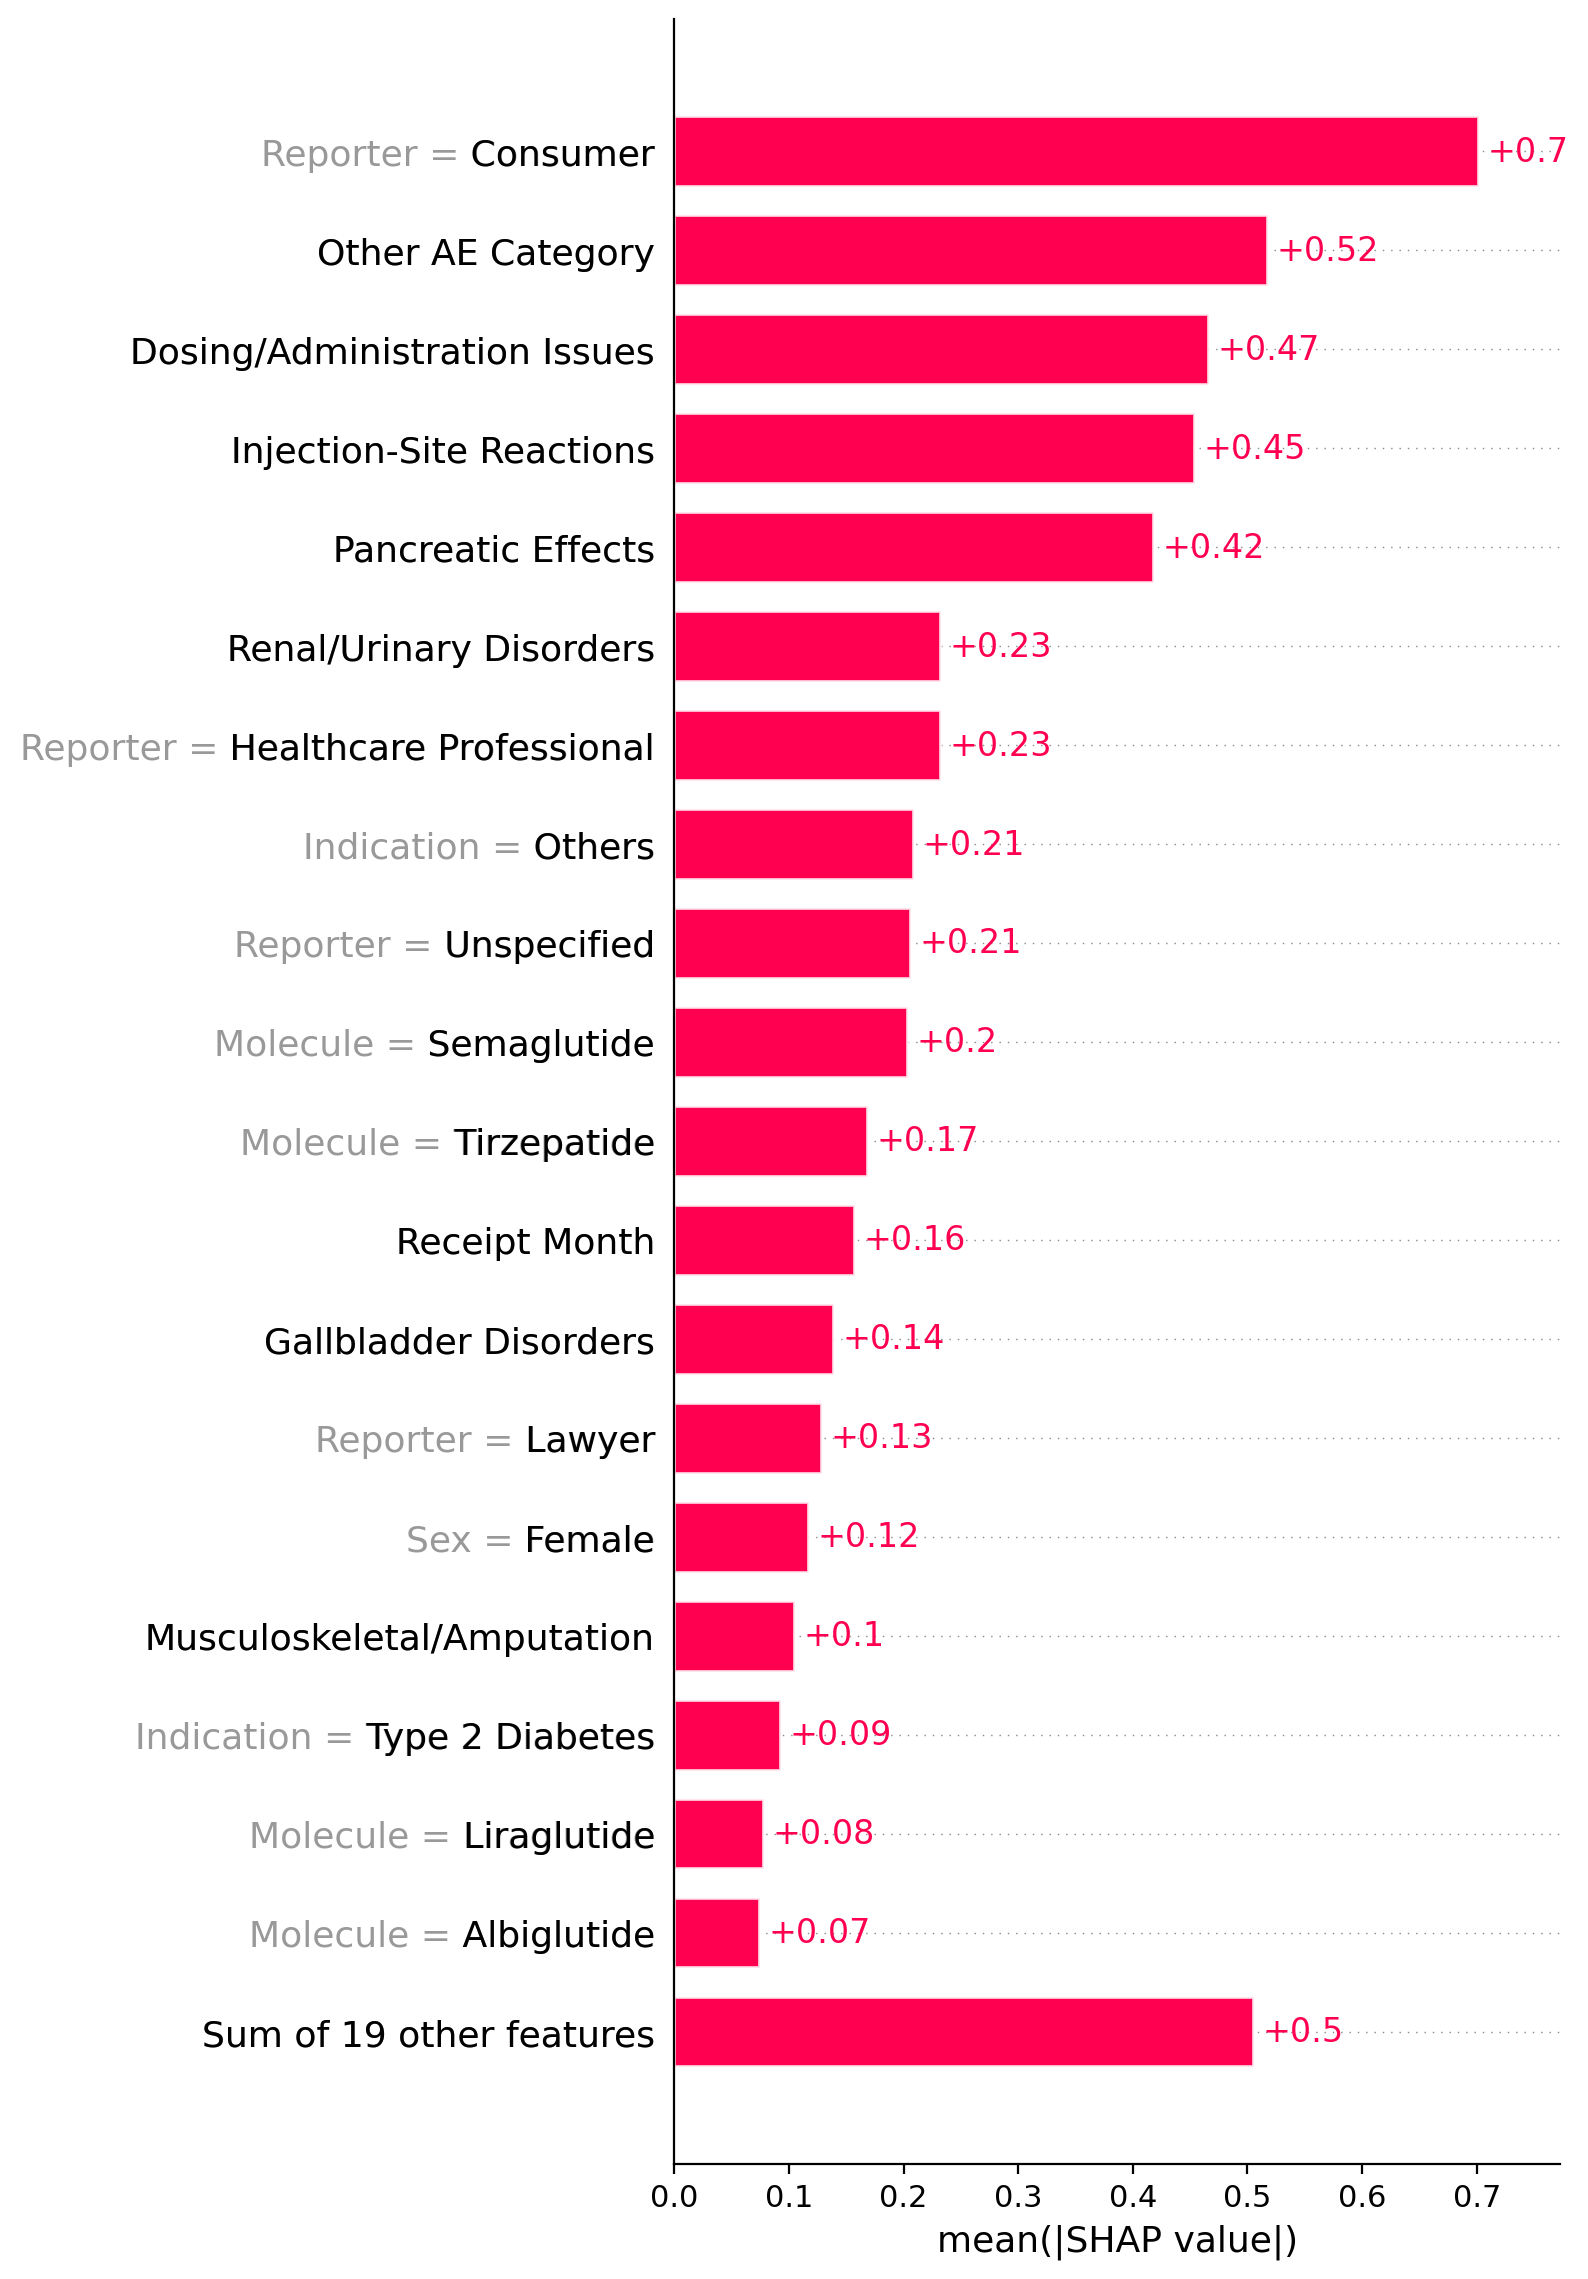

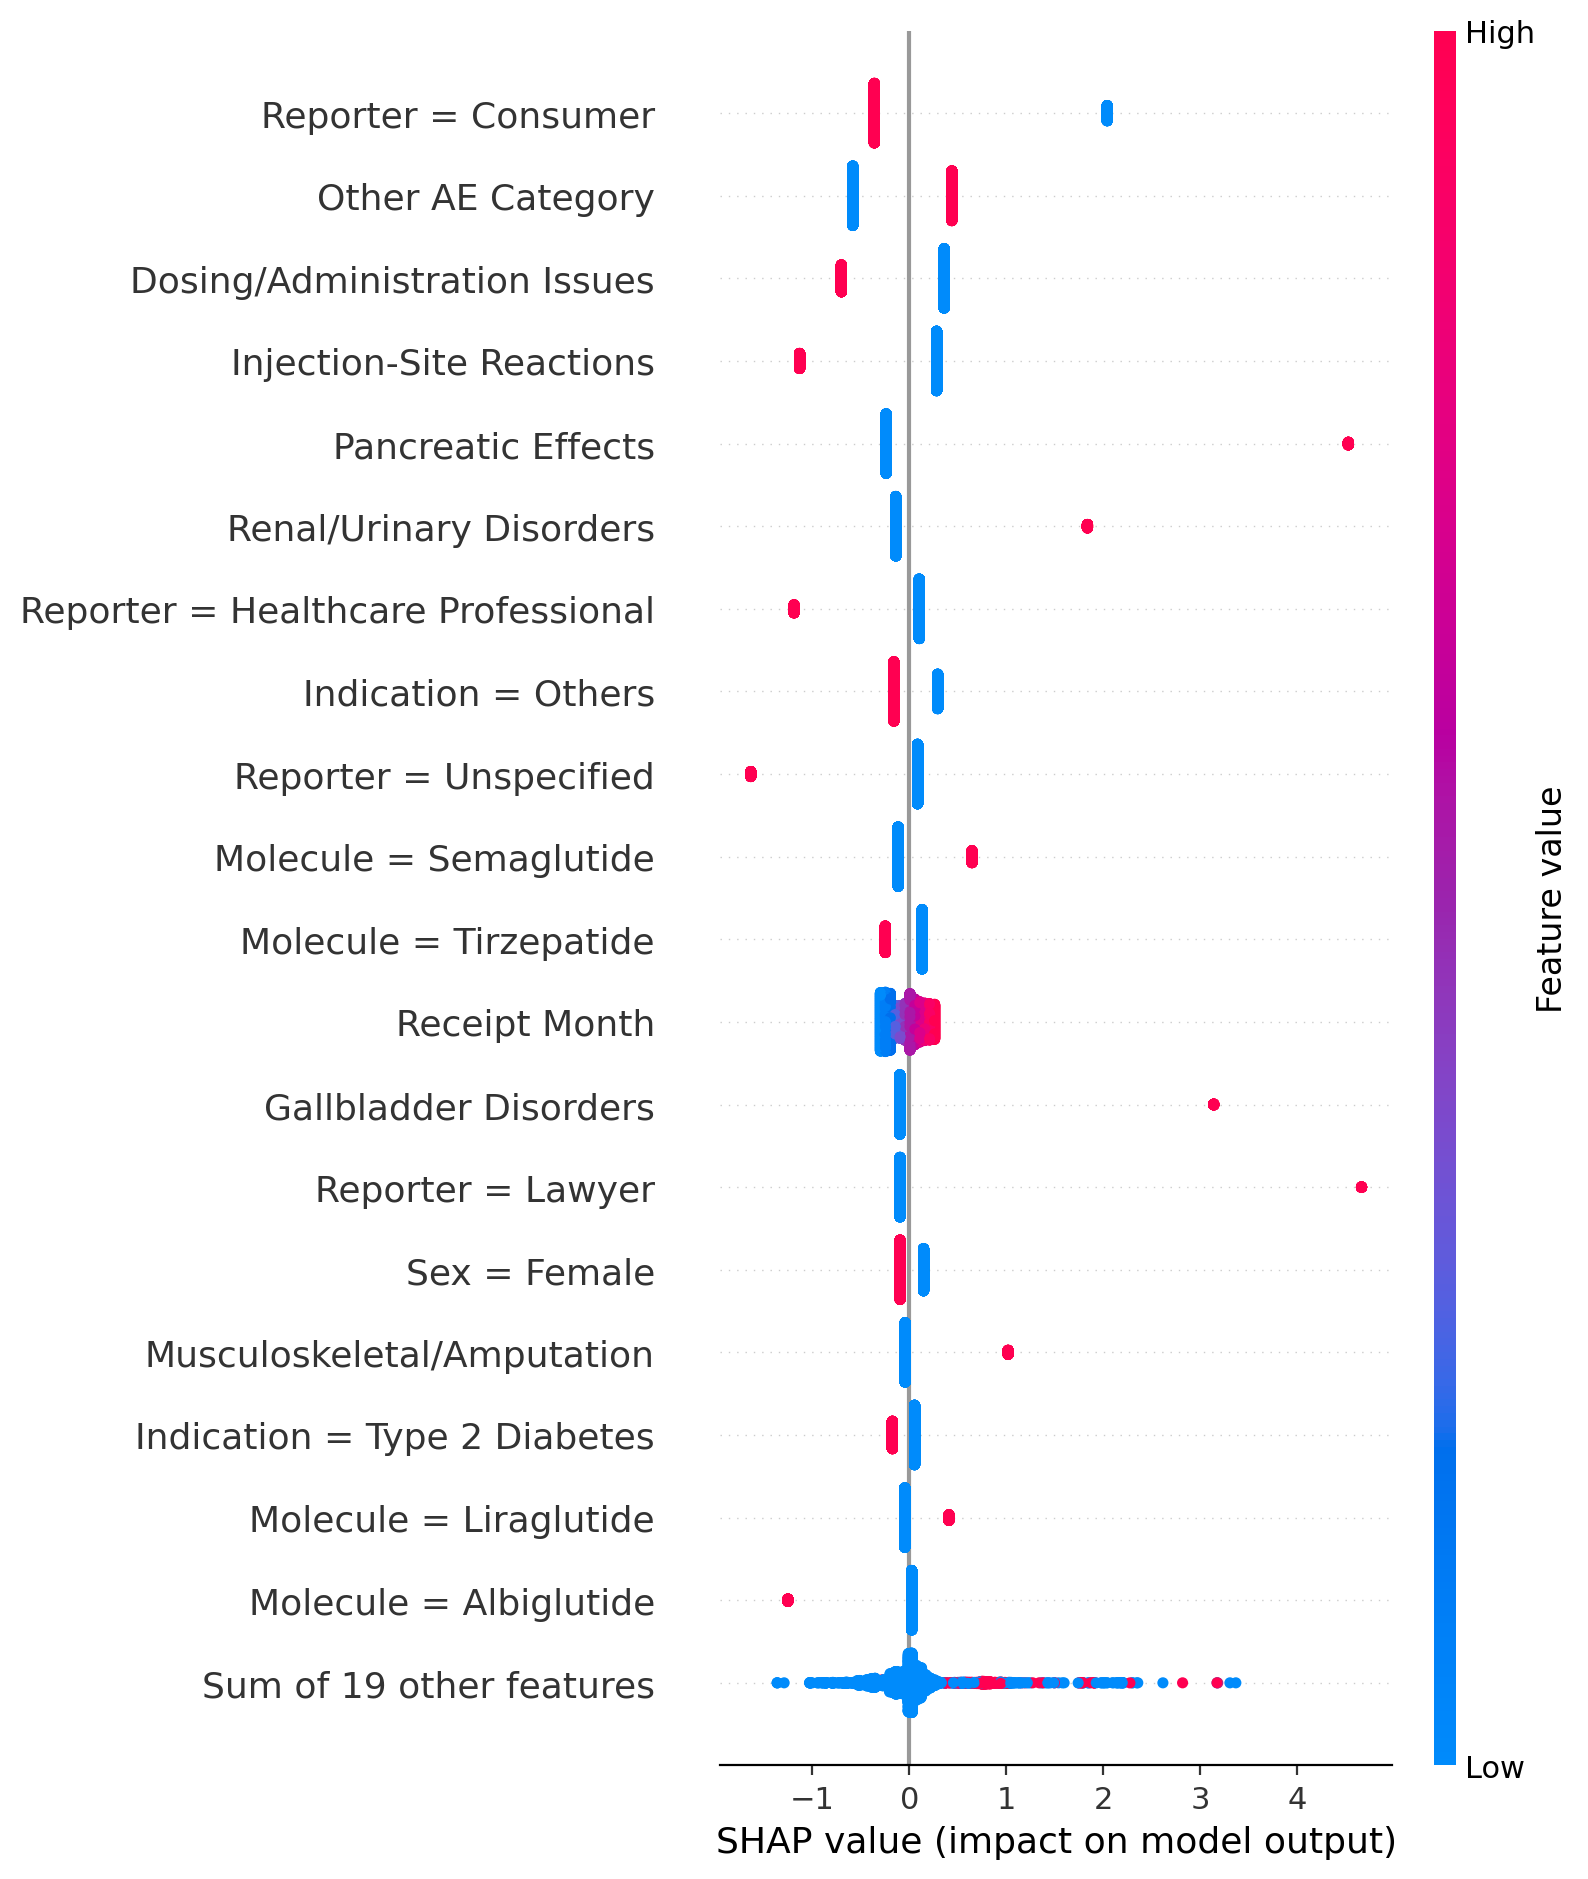

In [ ]:
# ============================================================
# SHAP for base (uncalibrated) models
# - Use the SAME train/val/test group-aware split we already built
# - Fit base LR / RF on TRAIN2 (X_tr_feat, y_tr)
# - Explain on TEST (X_test_feat)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import shap

# ----------------------------
# 0) Fit base models (UNCALIBRATED)
# ----------------------------
logit = Pipeline(steps=[
    ("pre", pre),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="lbfgs",
        class_weight=class_weight
    ))
])
logit.fit(X_tr_feat, y_tr)

rf = Pipeline(steps=[
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=30,
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    ))
])
rf.fit(X_tr_feat, y_tr)

# ----------------------------
# 1) Grab fitted preprocessor + feature names (post-OHE)
# ----------------------------
preproc = logit.named_steps["pre"]  # same as rf.named_steps["pre"] (identical pre object)
feat_names_tx = preproc.get_feature_names_out().tolist()

import re

# Canonical human-readable labels
NICE_LABELS = {
    # AE categories
    "cat_dose_admin": "Dosing/Administration Issues",
    "cat_gi": "Gastrointestinal Disorders",
    "cat_inj_site": "Injection-Site Reactions",
    "cat_pancreas": "Pancreatic Effects",
    "cat_thyroid": "Thyroid Disorders",
    "cat_gb": "Gallbladder Disorders",
    "cat_metabolic": "Metabolic Effects",
    "cat_renal": "Renal/Urinary Disorders",
    "cat_psych": "Psychiatric Disorders",
    "cat_msk": "Musculoskeletal/Amputation",
    "cat_effectiveness": "Drug Effectiveness",
    "cat_other": "Other AE Category",

    # Exposure flags
    "is_brand_only": "Brand-Only Exposure",
    "is_generic_only": "Generic-Only Exposure",
    "is_mixed": "Mixed Brand/Generic Exposure",

    # Numeric
    "receipt_year": "Receipt Year",
    "receipt_month": "Receipt Month",
    "age_years": "Age (Years)"
}

def prettify_feature_name(raw: str) -> str:
    """
    Converts model feature names into publication-ready labels.
    """

    # Remove ColumnTransformer prefixes (num__, cat__, bin__)
    f = re.sub(r'^[^_]+__', '', raw)

    # Remove literal word "bucket"
    f = f.replace("bucket_", "").replace("_bucket", "")

    # Handle OneHot encoded categoricals
    for base in ["sex", "reporter", "indication", "molecule"]:
        if f.startswith(base + "_"):
            val = f[len(base) + 1:].replace("_", " ").title()
            return f"{base.title()} = {val}"

    # Handle known binary/numeric features
    if f in NICE_LABELS:
        return NICE_LABELS[f]

    # Fallback: title case with spaces
    return f.replace("_", " ").title()

pretty_names = [prettify_feature_name(n) for n in feat_names_tx]

# ----------------------------
# 2) Transform train/test into the model feature space
# ----------------------------
X_train_tx = preproc.transform(X_tr_feat)    # TRAIN2 only
X_test_tx  = preproc.transform(X_test_feat)  # TEST

def to_dense_df(X_tx, columns):
    if hasattr(X_tx, "toarray"):
        X_tx = X_tx.toarray()
    return pd.DataFrame(X_tx, columns=columns)

X_train_tx_df = to_dense_df(X_train_tx, pretty_names)
X_test_tx_df  = to_dense_df(X_test_tx,  pretty_names)

# Sample for speed (adjust sizes)
rng = np.random.default_rng(42)
bg_n   = min(3000, len(X_train_tx_df))
test_n = min(5000, len(X_test_tx_df))

bg_idx   = rng.choice(len(X_train_tx_df), size=bg_n, replace=False)
test_idx = rng.choice(len(X_test_tx_df),  size=test_n, replace=False)

bg_data   = X_train_tx_df.iloc[bg_idx]
test_data = X_test_tx_df.iloc[test_idx]

# ============================================================
# 3) SHAP for Logistic Regression
# ============================================================
lr_clf = logit.named_steps["clf"]

# LinearExplainer is best for logistic regression
lr_explainer = shap.Explainer(lr_clf, bg_data, feature_names=pretty_names)
lr_shap = lr_explainer(test_data)

# Save global importance table
lr_importance = np.abs(lr_shap.values).mean(axis=0)
lr_imp_df = (pd.DataFrame({"feature": pretty_names, "mean_abs_shap": lr_importance})
             .sort_values("mean_abs_shap", ascending=False))
lr_imp_df.to_csv("shap_logreg_mean_abs_importance.csv", index=False)

TARGET_H = 1600  # pixels
DPI      = 200
HEIGHT_IN = TARGET_H / DPI

plt.figure(figsize=(9, HEIGHT_IN), dpi=DPI)
shap.plots.bar(lr_shap, max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_logreg_bar_top20.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(9, HEIGHT_IN), dpi=DPI)
shap.plots.beeswarm(lr_shap, max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_logreg_beeswarm_top20.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

100%|===================| 9988/10000 [14:00<00:01]        

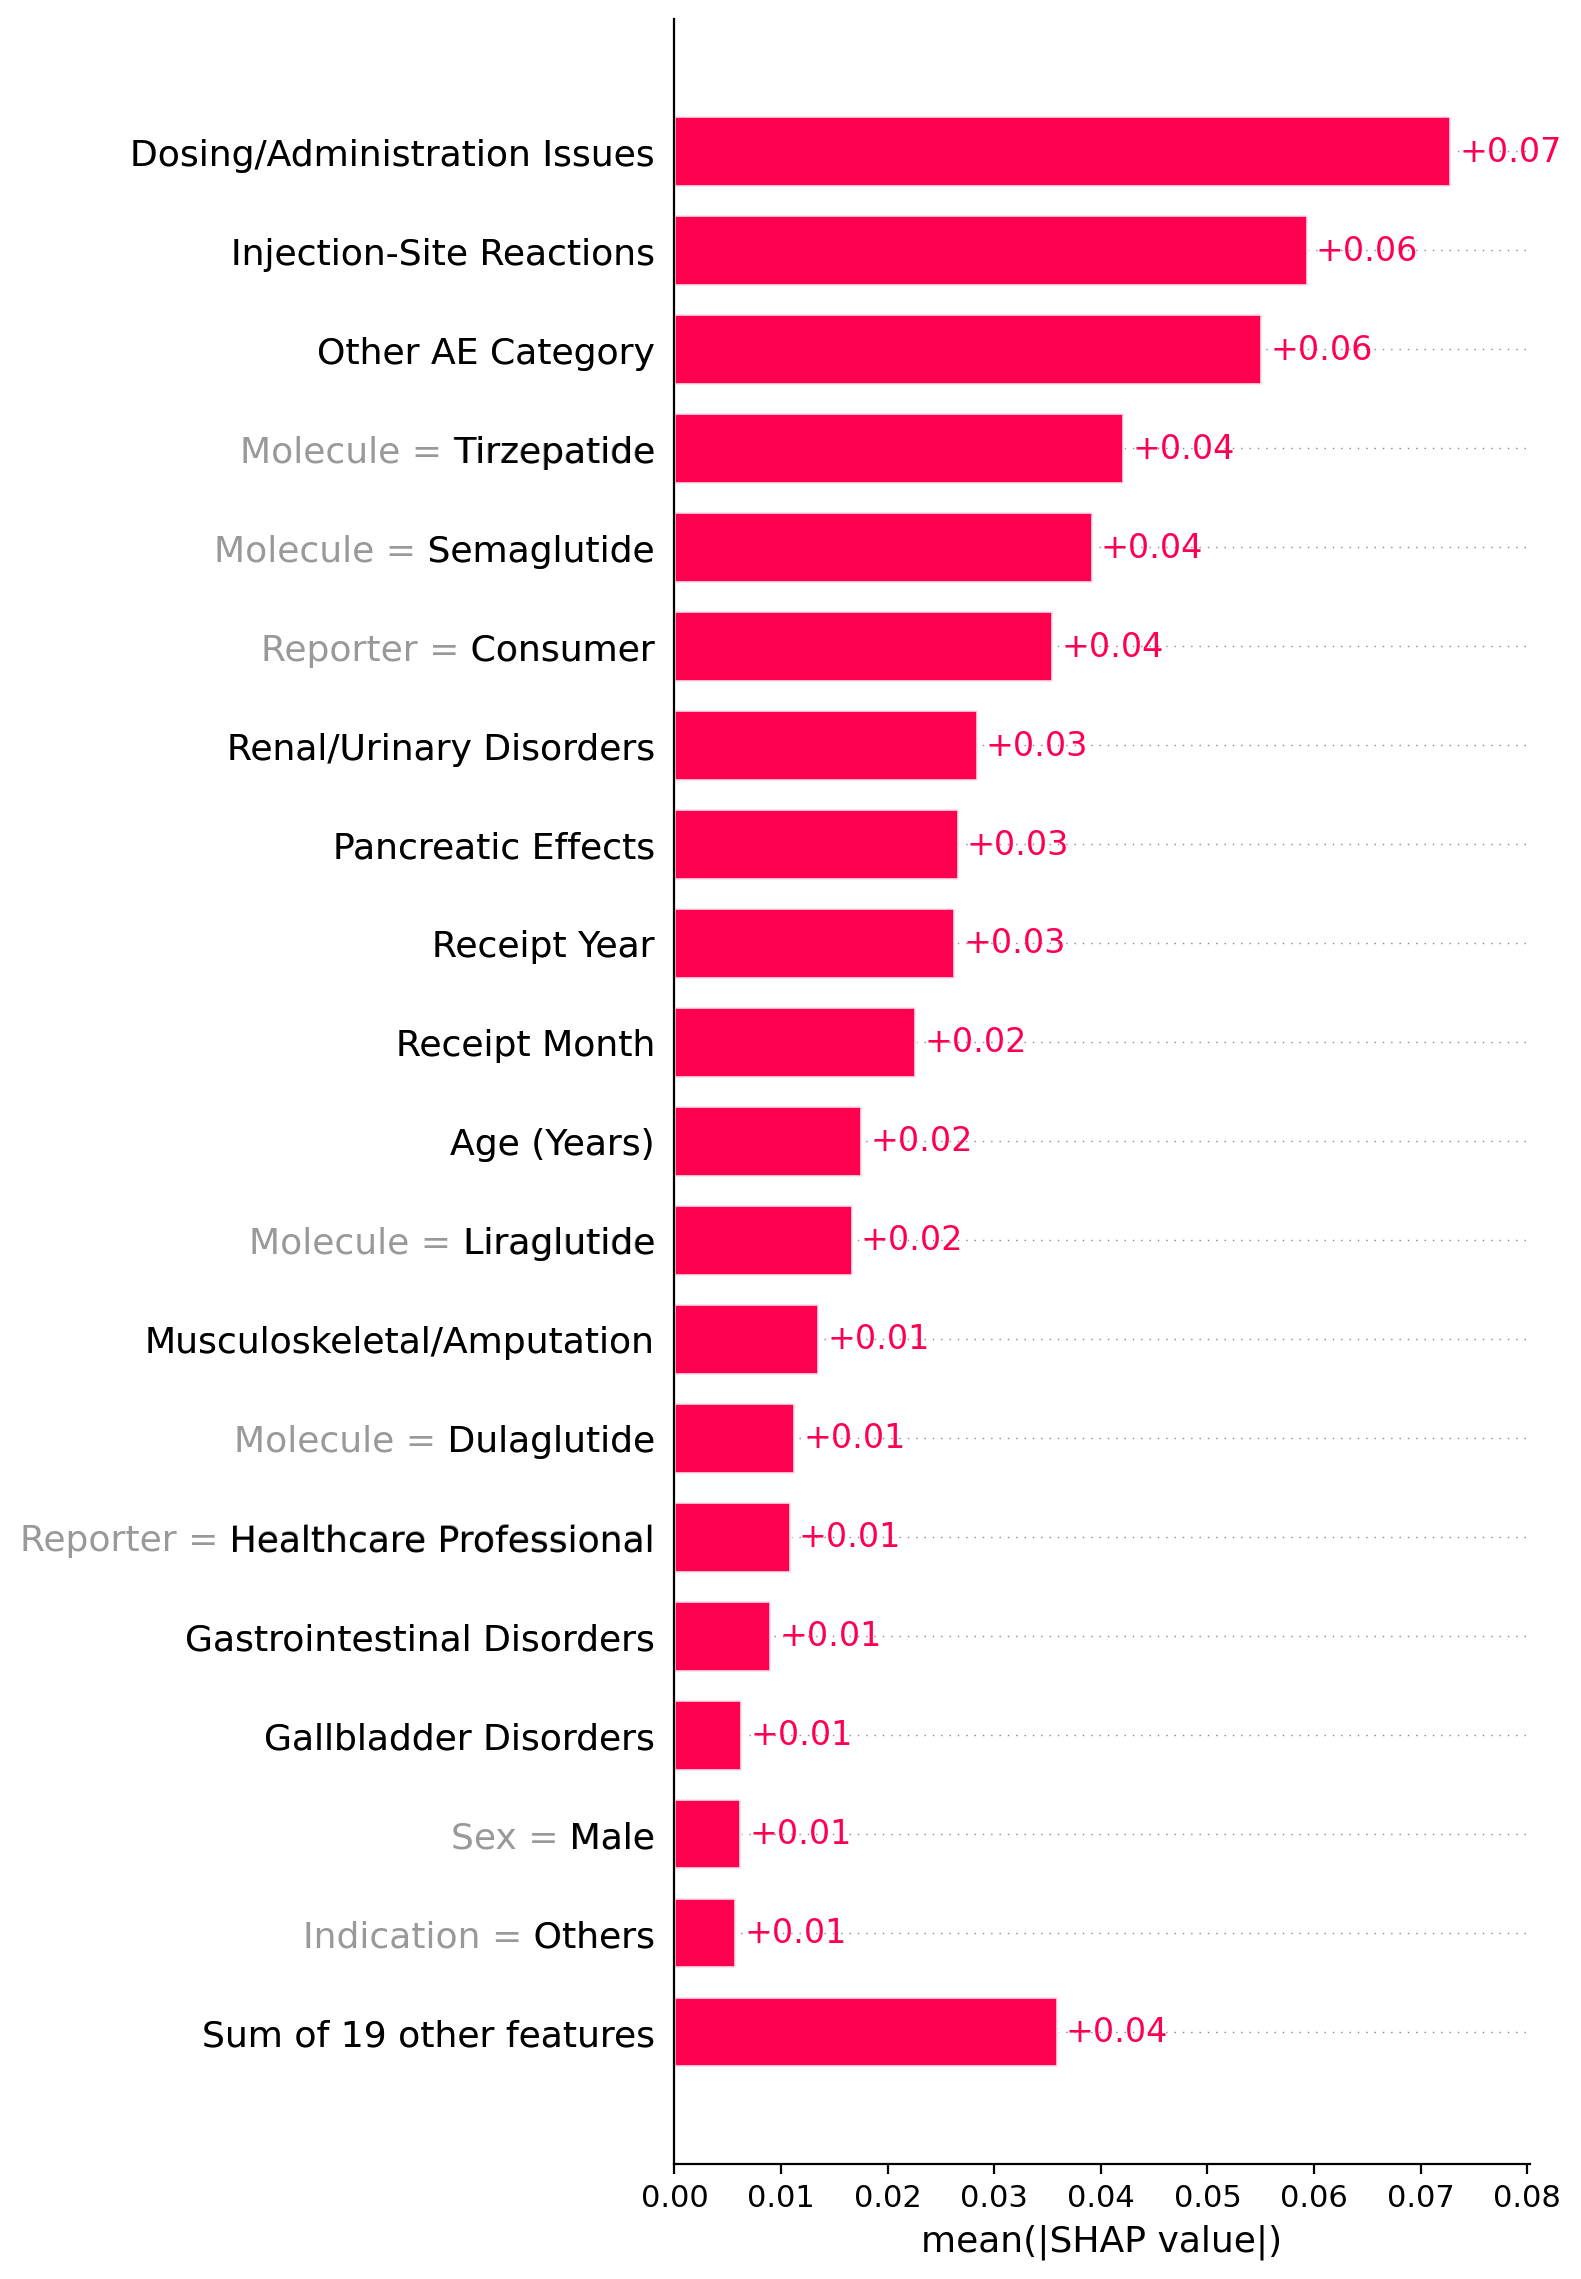

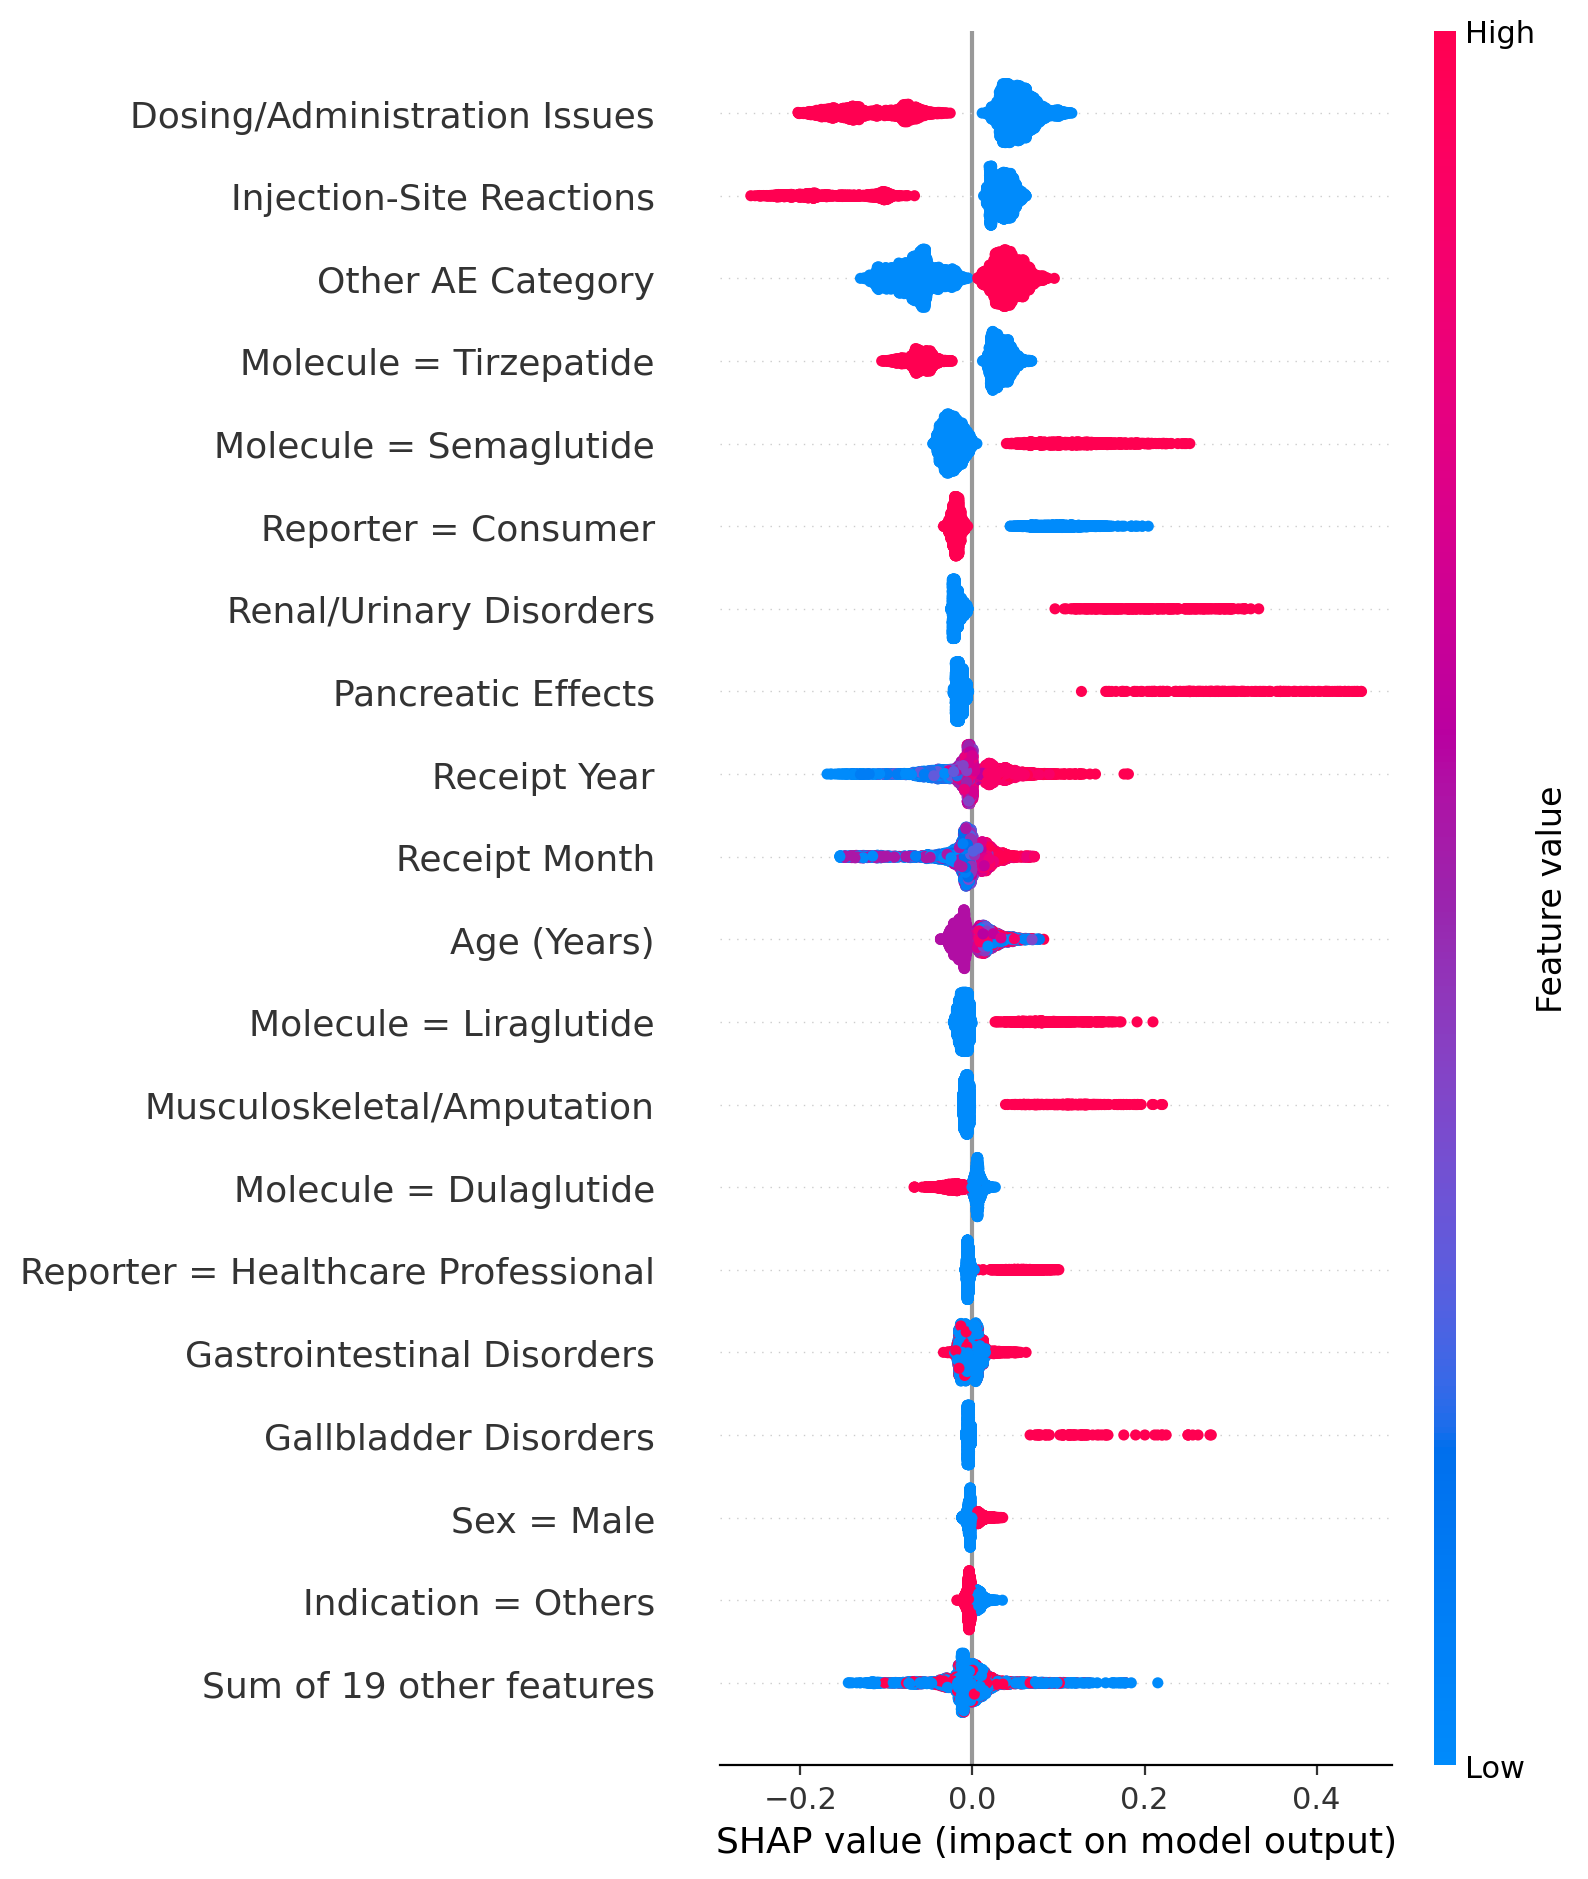

In [94]:
# ============================================================
# 4) SHAP for Random Forest (robust handling for binary output)
# ============================================================
rf_clf = rf.named_steps["clf"]

rf_explainer = shap.TreeExplainer(
    rf_clf,
    data=bg_data,
    feature_perturbation="interventional"
)

rf_shap = rf_explainer(test_data)

# ---- robust extraction of "positive class" (serious=1) SHAP values ----
rf_values = rf_shap.values
rf_base   = rf_shap.base_values

# Case A: list-of-arrays per class (older SHAP)
if isinstance(rf_values, list):
    rf_values_pos = rf_values[1]  # (n_samples, n_features)
    rf_base_pos   = rf_base[1] if isinstance(rf_base, list) else rf_base

# Case B: ndarray with output dim (n, f, 2) or (n, f)
else:
    rf_values = np.asarray(rf_values)
    rf_base   = np.asarray(rf_base)

    if rf_values.ndim == 3 and rf_values.shape[-1] == 2:
        rf_values_pos = rf_values[..., 1]  # (n_samples, n_features)
    else:
        rf_values_pos = rf_values           # (n_samples, n_features)

    # base values can be (n,2) or (n,) depending on SHAP version
    if rf_base.ndim == 2 and rf_base.shape[-1] == 2:
        rf_base_pos = rf_base[..., 1]       # (n_samples,)
    else:
        rf_base_pos = rf_base               # (n_samples,) or scalar

# Wrap as Explanation so shap.plots.* works consistently
rf_shap_pos = shap.Explanation(
    values=rf_values_pos,
    base_values=rf_base_pos,
    data=test_data.values,          # ok as ndarray
    feature_names=pretty_names
)

# Global importance (1D)
rf_importance = np.abs(rf_shap_pos.values).mean(axis=0)  # (n_features,)

rf_imp_df = (
    pd.DataFrame({"feature": pretty_names, "mean_abs_shap": rf_importance})
      .sort_values("mean_abs_shap", ascending=False)
)
rf_imp_df.to_csv("shap_rf_mean_abs_importance.csv", index=False)

plt.figure(figsize=(9, HEIGHT_IN), dpi=DPI)
shap.plots.bar(rf_shap_pos, max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_rf_bar_top20.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(9, HEIGHT_IN), dpi=DPI)
shap.plots.beeswarm(rf_shap_pos, max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_rf_beeswarm_top20.png", dpi=DPI, bbox_inches="tight")
plt.show()
plt.close()

Make Panel Picture

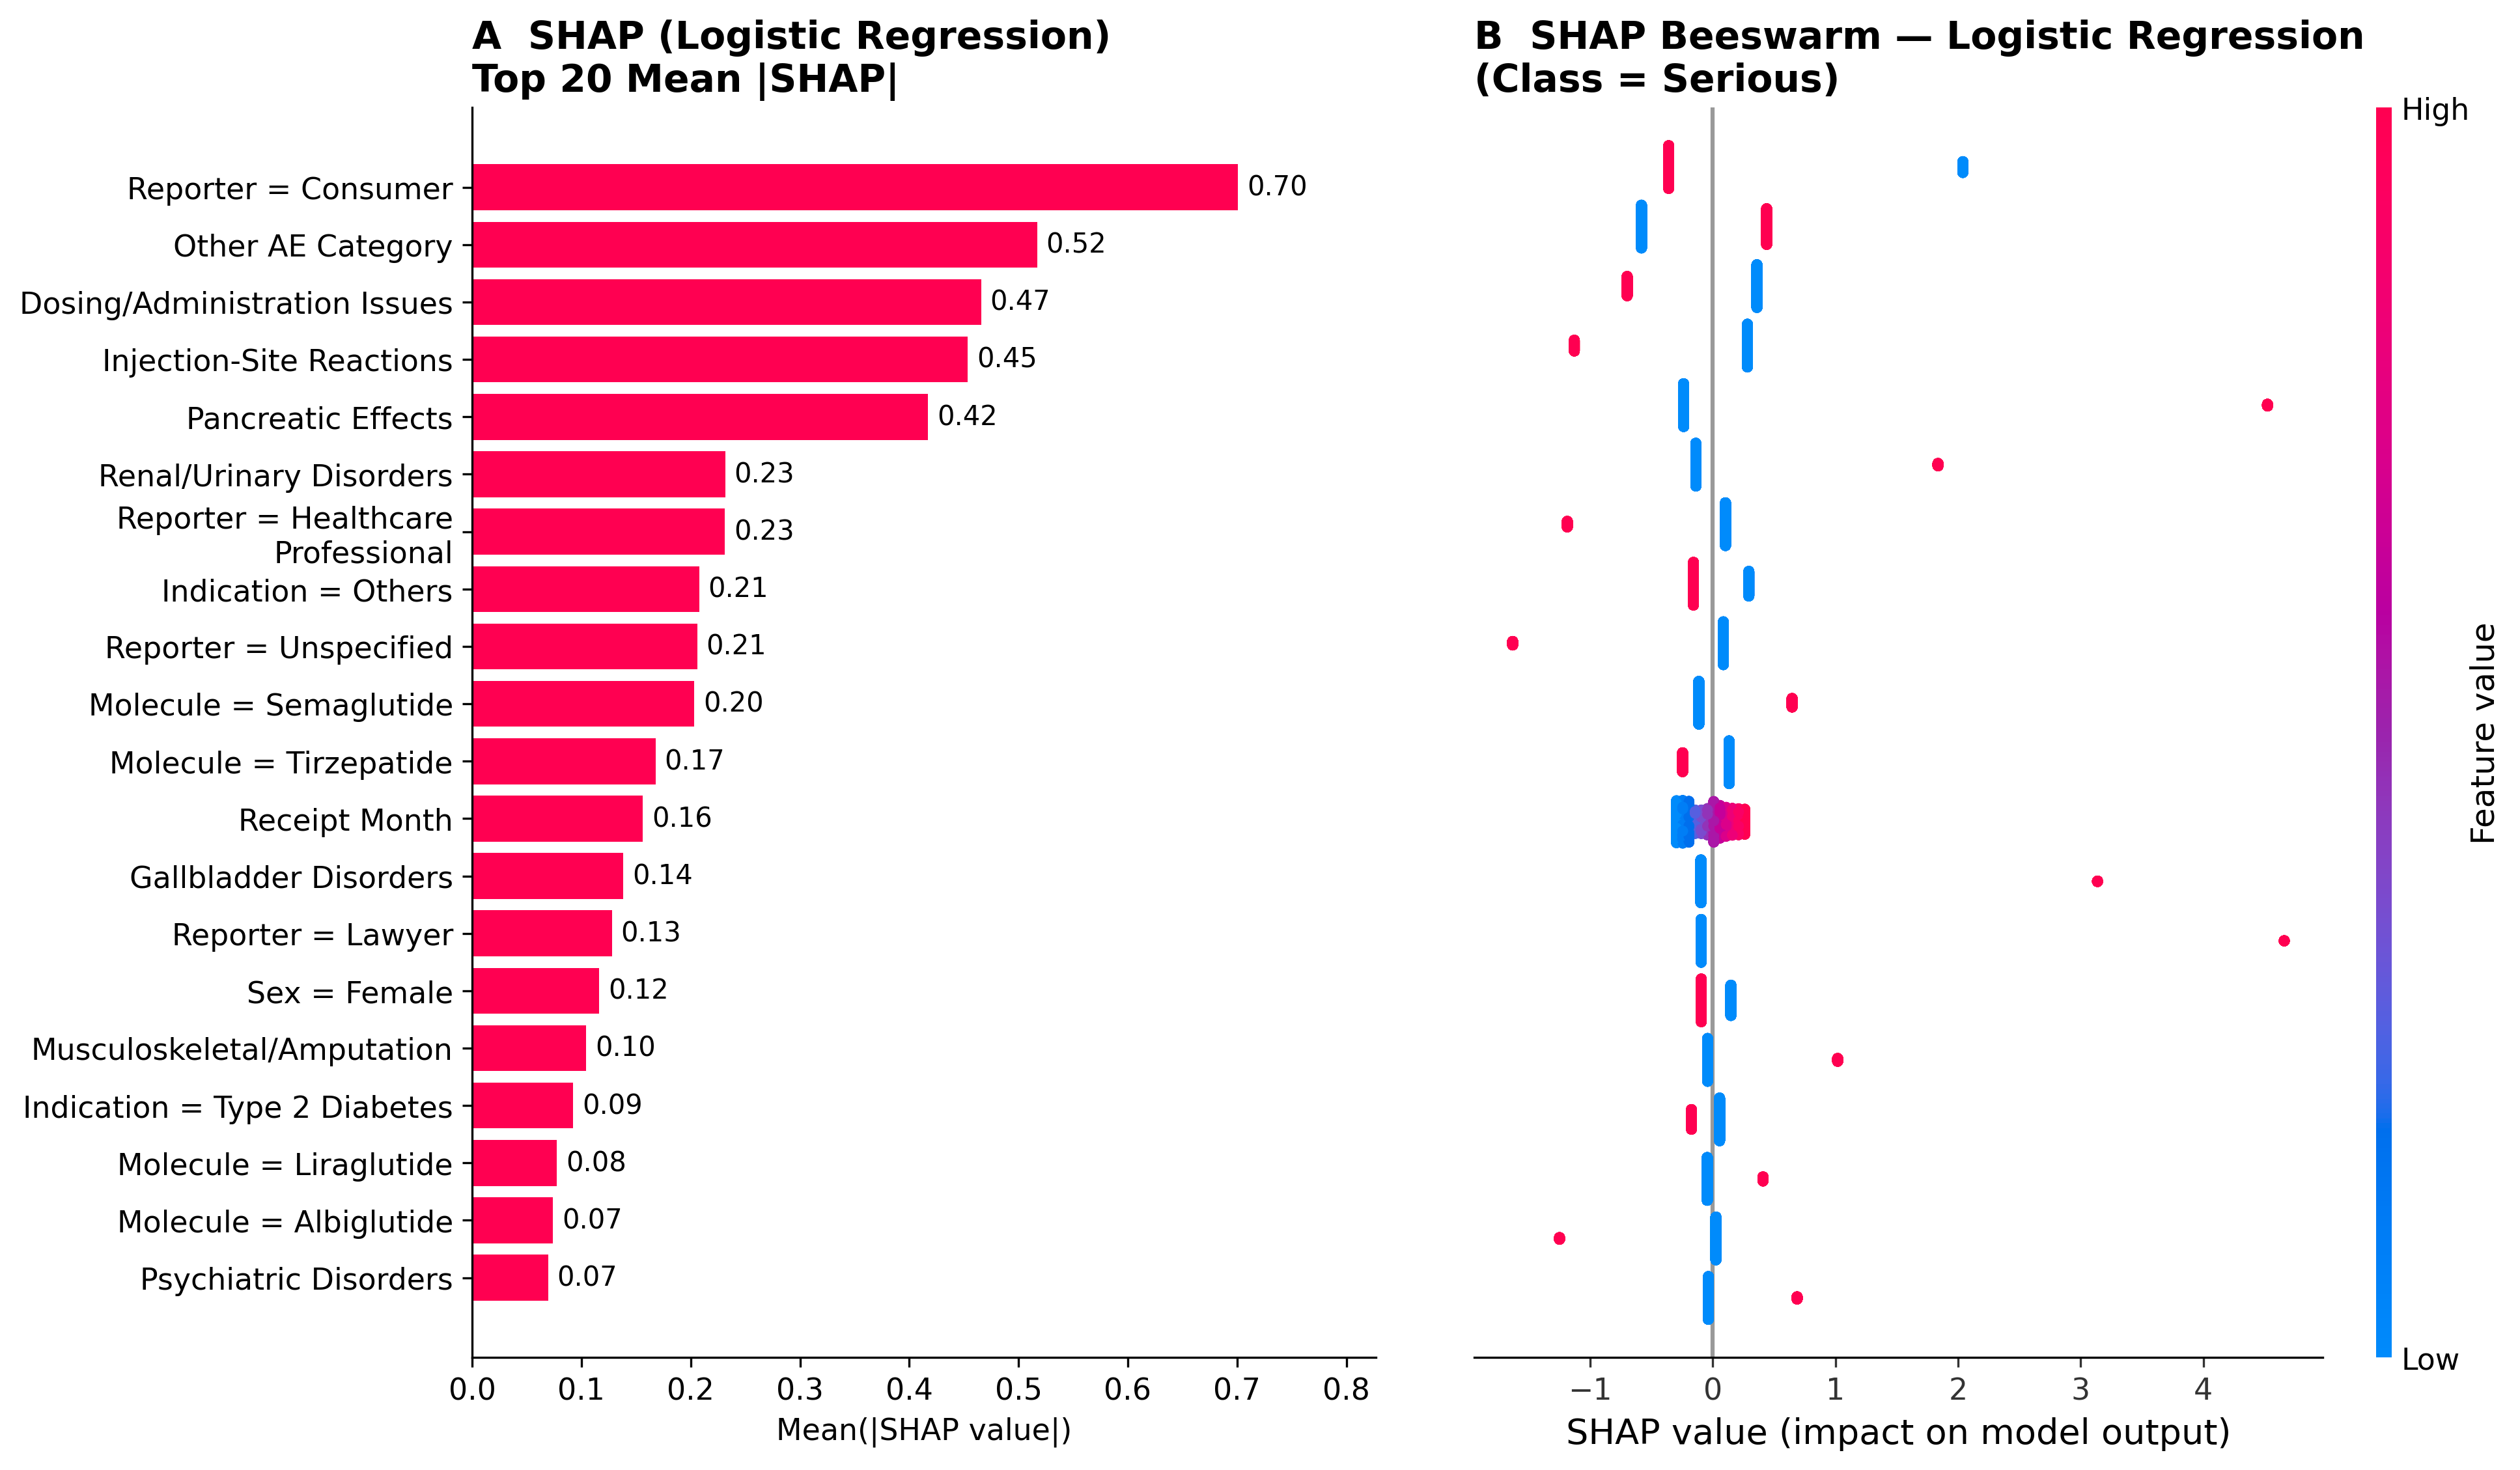

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import shap
import textwrap
import matplotlib as mpl

# -----------------------------
# Publication styling
# -----------------------------
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

def wrap_label(s, width=30):
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))

def remove_shap_guides(ax):
    ax.grid(False)
    # remove dotted guide lines SHAP may draw
    for line in list(ax.lines):
        if line.get_linestyle() in ("--", ":"):
            try:
                line.remove()
            except Exception:
                pass

# -----------------------------
# lr_shap must be shap.Explanation
# -----------------------------
topk = 20

# mean(|SHAP|) per feature
imp = np.abs(lr_shap.values).mean(axis=0)
idx = np.argsort(imp)[::-1][:topk]     # top features (descending importance)

# reverse for plotting so most important is at top
idx_plot = idx[::-1]

# labels + values for panel A
labels = [wrap_label(lr_shap.feature_names[i], width=30) for i in idx_plot]
vals   = imp[idx_plot]

# -----------------------------
# Figure layout
# -----------------------------
FIG_W, FIG_H, DPI = 16, 8, 300
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=DPI, facecolor="white")

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1.15, 1.35],
    wspace=0.10
)

# =============================
# Panel A — manual bar (clean + stable)
# =============================
ax1 = fig.add_subplot(gs[0, 0])
bar_color = "#ff0051"

ax1.barh(np.arange(topk), vals, color=bar_color, edgecolor="none")
ax1.set_yticks(np.arange(topk))
ax1.set_yticklabels(labels)
ax1.set_xlabel("Mean(|SHAP value|)")

xmax = float(vals.max()) * 1.18
ax1.set_xlim(0, xmax)

for y, v in enumerate(vals):
    ax1.text(v + xmax*0.01, y, f"{v:.02f}", va="center", ha="left", fontsize=10)

ax1.set_title("A  SHAP (Logistic Regression)\nTop 20 Mean |SHAP|", loc="left")
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# =============================
# Panel B — beeswarm (same top-20, same order)
# =============================
ax2 = fig.add_subplot(gs[0, 1])
plt.sca(ax2)

lr_top = lr_shap[:, idx][:, ::-1]   # same 20 features, same order as panel A

shap.plots.beeswarm(
    lr_top,
    max_display=topk,
    show=False,
    plot_size=None
)

ax2.set_title("B  SHAP Beeswarm — Logistic Regression\n(Class = Serious)", loc="left")
remove_shap_guides(ax2)

# KEY: prevent “middle overlap” by removing y labels on panel B
ax2.set_yticklabels([])
ax2.set_ylabel("")
ax2.tick_params(axis="y", length=0)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# -----------------------------
# Final margins
# -----------------------------
fig.subplots_adjust(left=0.30, right=0.96, top=0.92, bottom=0.12)

plt.savefig("shap_logreg_panel_AB_pub.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.savefig("shap_logreg_panel_AB_pub.pdf", bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

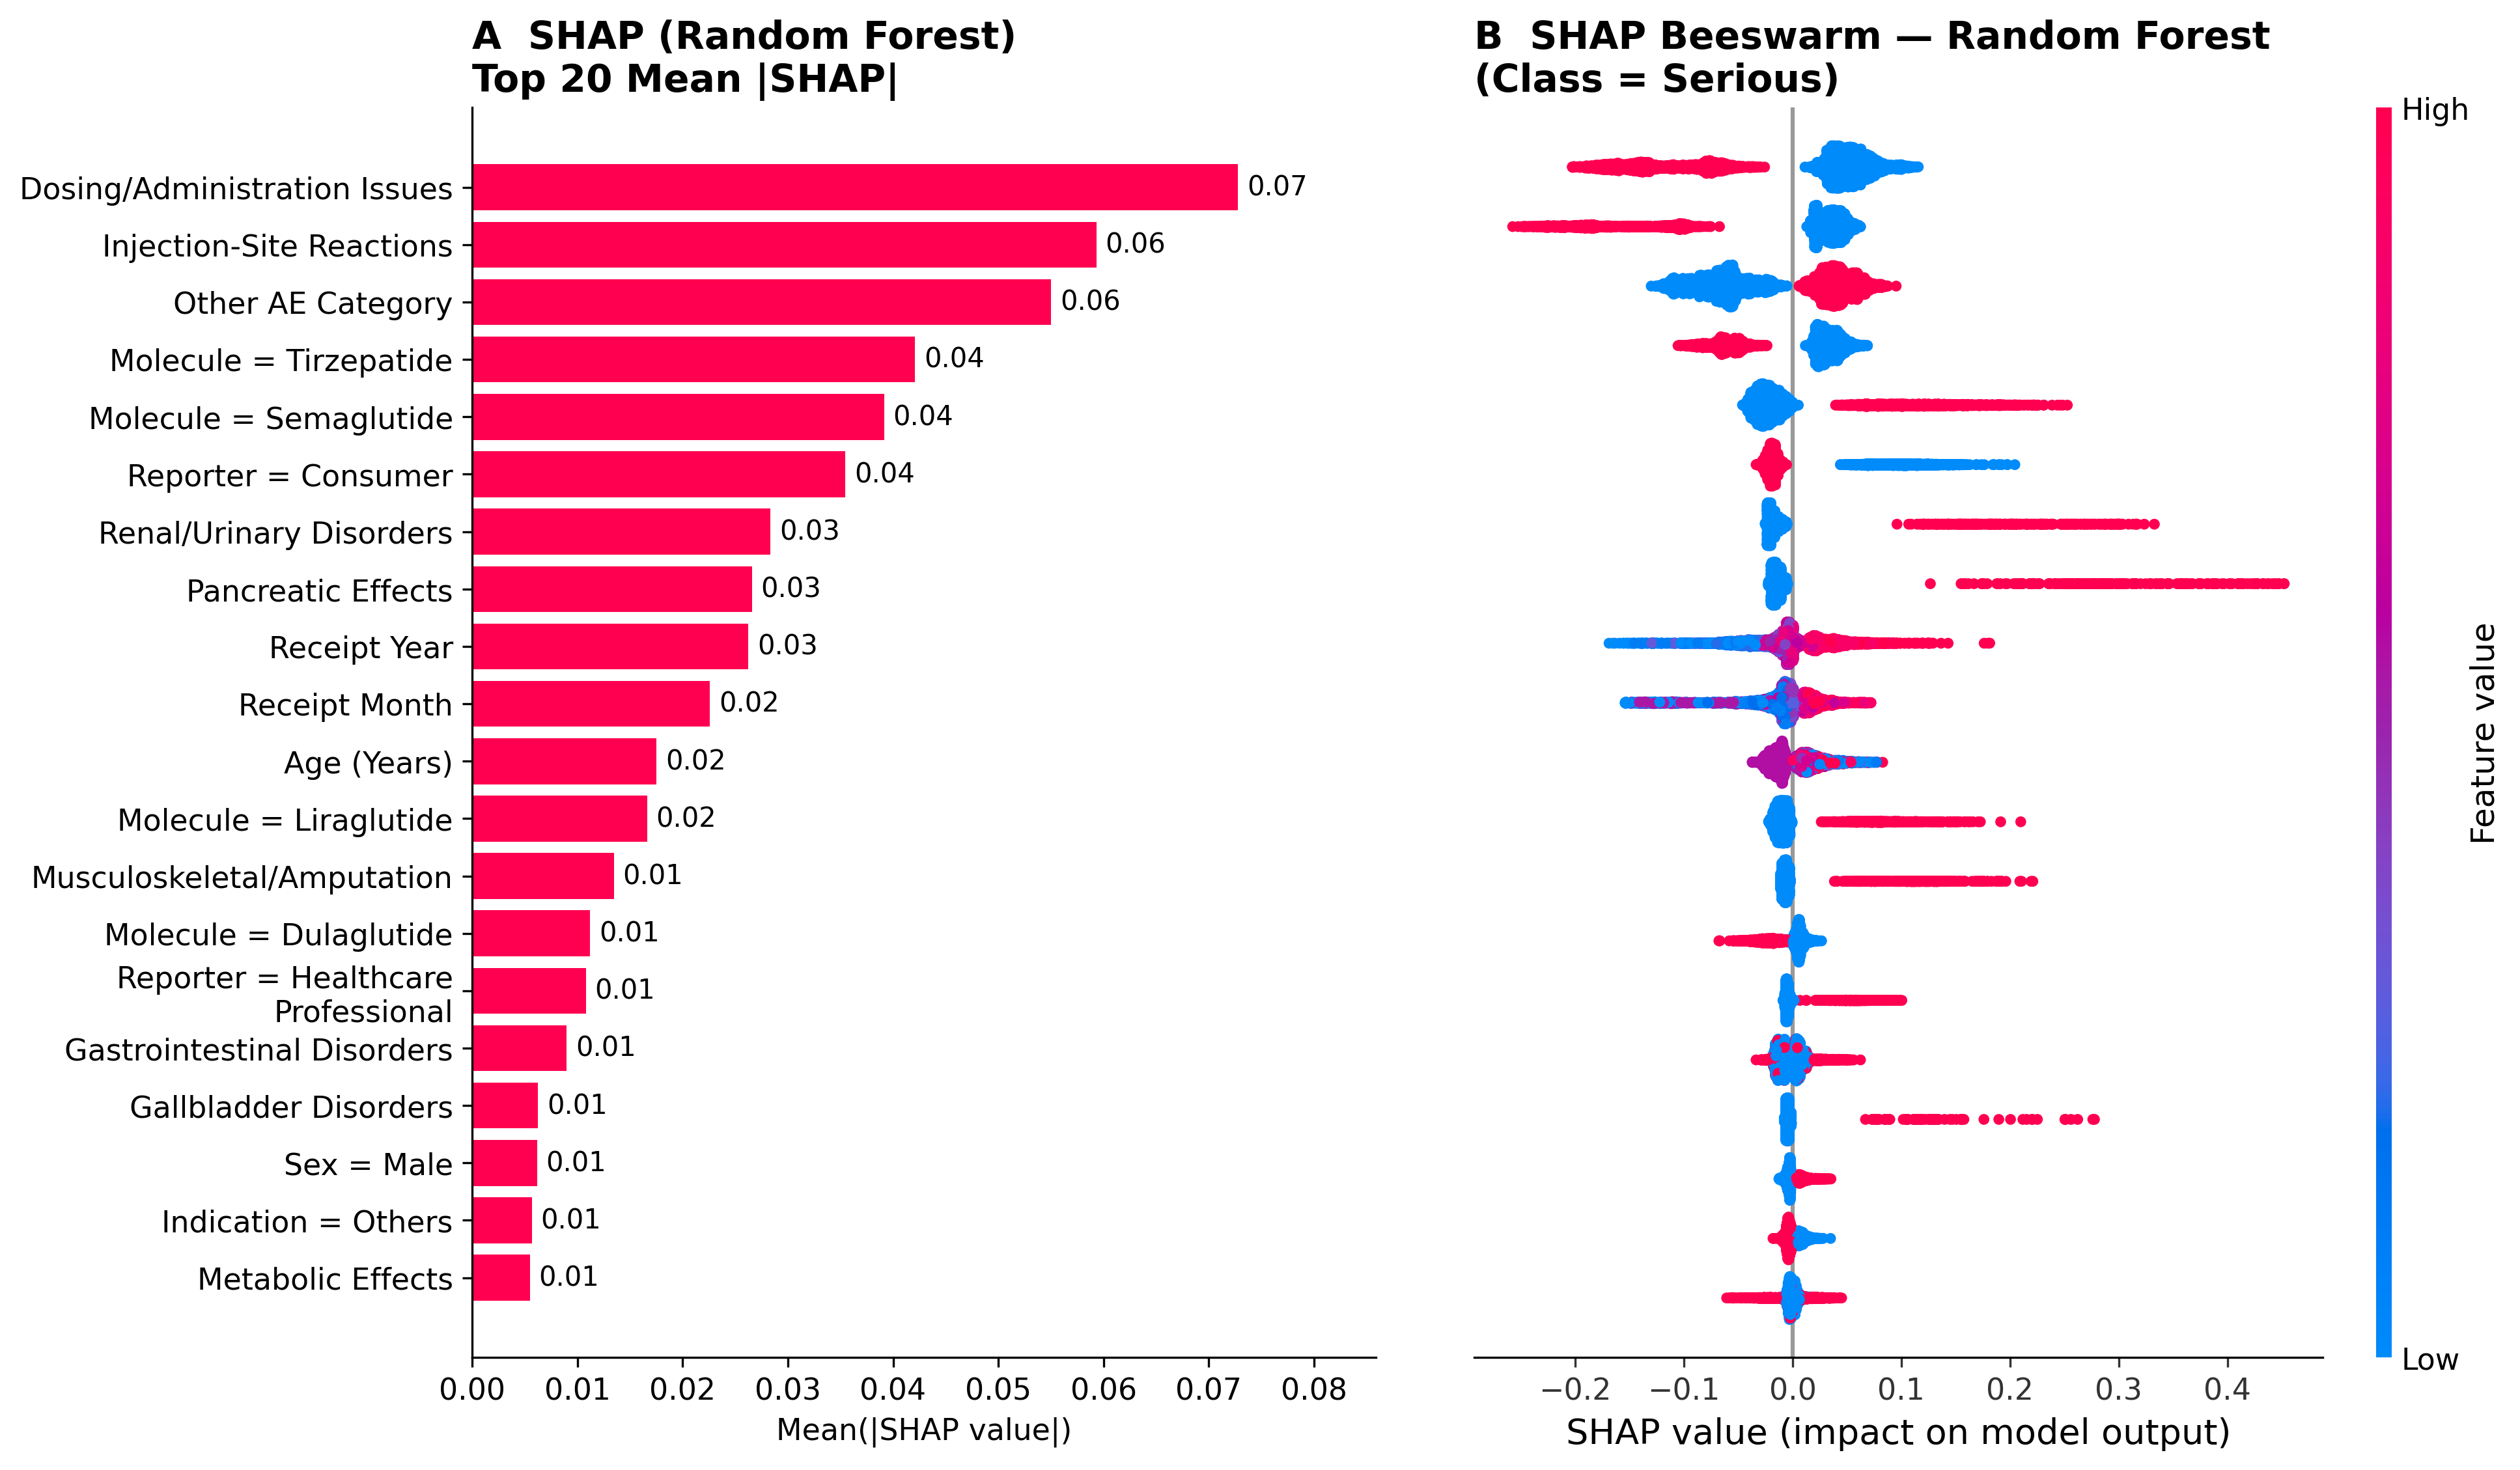

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import shap
import textwrap
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

def wrap_label(s, width=30):
    return "\n".join(textwrap.wrap(str(s), width=width, break_long_words=False))

def remove_shap_guides(ax):
    ax.grid(False)
    # SHAP sometimes draws faint dotted guide lines as Line2D
    for line in list(ax.lines):
        # remove only very light guide lines
        if line.get_linestyle() in ("--", ":"):
            try:
                line.remove()
            except Exception:
                pass

# -----------------------------
# Use rf_shap_pos (Explanation)
# -----------------------------
topk = 20
imp = np.abs(rf_shap_pos.values).mean(axis=0)
idx = np.argsort(imp)[::-1][:topk]

# Reverse order so biggest at top in both panels
idx_plot = idx[::-1]
labels = [wrap_label(rf_shap_pos.feature_names[i], width=30) for i in idx_plot]
vals   = imp[idx_plot]

FIG_W, FIG_H, DPI = 16, 8, 300
fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=DPI, facecolor="white")

gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1.15, 1.35],
    wspace=0.1  # bigger gap
)

# =============================
# Panel A — bar
# =============================
ax1 = fig.add_subplot(gs[0, 0])
bar_color = "#ff0051"

ax1.barh(np.arange(topk), vals, color=bar_color, edgecolor="none")
ax1.set_yticks(np.arange(topk))
ax1.set_yticklabels(labels)
ax1.set_xlabel("Mean(|SHAP value|)")

xmax = float(vals.max()) * 1.18
ax1.set_xlim(0, xmax)

for y, v in enumerate(vals):
    ax1.text(v + xmax*0.01, y, f"{v:.02f}", va="center", ha="left", fontsize=10)

ax1.set_title("A  SHAP (Random Forest)\nTop 20 Mean |SHAP|", loc="left")
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# =============================
# Panel B — beeswarm
# =============================
ax2 = fig.add_subplot(gs[0, 1])
plt.sca(ax2)

rf_top = rf_shap_pos[:, idx][:, ::-1]  # same 20, same order as Panel A

shap.plots.beeswarm(
    rf_top,
    max_display=topk,
    show=False,
    plot_size=None
)

ax2.set_title("B  SHAP Beeswarm — Random Forest\n(Class = Serious)", loc="left")
remove_shap_guides(ax2)

# KEY FIX: remove y labels on Panel B so nothing spills into the middle
ax2.set_yticklabels([])
ax2.set_ylabel("")
ax2.tick_params(axis="y", length=0)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# -----------------------------
# Final margins (more left room)
# -----------------------------
fig.subplots_adjust(left=0.30, right=0.96, top=0.92, bottom=0.12)

plt.savefig("shap_rf_panel_AB_pub.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.savefig("shap_rf_panel_AB_pub.pdf", bbox_inches="tight", facecolor="white")
plt.show()
plt.close()
